# **Eng detect**

In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 44.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=963e8e2209e1ef088ffa6cf1488e8e0e263f65aa8b8e235a7f11783d9195df07
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
import pandas as pd
from langdetect import detect, DetectorFactory

DetectorFactory.seed = 42

df = pd.read_csv("annotation_3_person - All_Data.csv")

def detect_language(text):
    try:
        return detect(str(text))
    except:
        return "unknown"

df["detected_language"] = df["title"].apply(detect_language)

print(df["detected_language"].value_counts())

# ===============================
english_data = df[df["detected_language"] == "en"]

english_data

detected_language
id    4757
en     103
de      42
tl      24
et      11
it       9
af       8
sv       8
ca       7
es       6
sw       4
no       3
pt       3
ro       3
nl       3
tr       3
fi       2
da       1
fr       1
sq       1
so       1
Name: count, dtype: int64


,id,source,date,domain,title,Label,url,detected_language
214,215,Detik Edu,26-05-06,Pendidikan,"Pelopor Accounting dan Teknologi, School of Ac...",0,https://www.detik.com/edu/perguruan-tinggi/d-8...,en
371,372,Detik Edu,26-05-30,Pendidikan,"In This Economy, Ada Cara Cerdas Hemat buat No...",1,https://www.detik.com/edu/edutainment/d-851055...,en
641,642,Detik Edu,26-05-19,Pendidikan,Sering Dighosting Calon Buyer? Ini Strategi Wh...,1,https://www.detik.com/edu/edutainment/d-849569...,en
671,672,Detik Edu,26-05-19,Pendidikan,Sering Dighosting Calon Buyer? Ini Strategi Wh...,1,https://www.detik.com/edu/edutainment/d-849404...,en
699,700,Detik Edu,26-05-18,Pendidikan,"Beasiswa S2-S3 University of Melbourne, Plus T...",0,https://www.detik.com/edu/beasiswa/d-8492226/b...,en
...,...,...,...,...,...,...,...,...
4902,4903,Detik,2026-01-27,Teknologi,"Daftar Cheat GTA San Andreas di HP Android, PS...",0,https://inet.detik.com/games-features/d-832751...,en
4933,4934,Detik,2025-01-08,Teknologi,"Review Squid Game: Unleashed, Asyik Tapi Kuran...",0,https://inet.detik.com/games-features/d-772315...,en
4964,4965,Detik,2024-06-21,Teknologi,10 Game Gacha Terbaik Untuk Gamer Free to Play,0,https://inet.detik.com/games-features/d-740119...,en
4986,4987,Detik,2023-08-03,Teknologi,Daftar Game Gratis Nintendo Switch Agustus 202...,0,https://inet.detik.com/games-features/d-685661...,en


In [ ]:
text = "Universitas Prasetiya Mulya Perkenalkan ""Prasmul New Look"" di Kampus BSD"
print(detect_language(text))
print(english_word_ratio(text))

NameError: name 'detect_language' is not defined

In [ ]:
# pip install wordfreq

import re
from wordfreq import zipf_frequency

def remove_english_words(text):
    if not isinstance(text, str):
        return ""

    kept = []

    for word in text.split():
        check = re.sub(r"[^a-zA-Z]", "", word).lower()

        if check == "":
            kept.append(word)
            continue

        en = zipf_frequency(check, "en")
        idn = zipf_frequency(check, "id")

        if idn >= en:
            kept.append(word)

    return " ".join(kept)

examples = [
    "Jadwal MPL ID S17 Week 9 Hari Ini: Team Liquid ID Vs Alter Ego"
,"30 Tahun SIS Group of Schools, Perkuat Jejak Global dan Luncurkan SIS North East Jakarta"
,"Nottingham Forest Tampik Tawaran Man City untuk Elliot Anderson"
,"Kata Adam Wharton Usai Crystal Palace Juarai Conference League"
,"Roster Pemain NBA All-Stars 2026: Daftar Lengkap East Team & West Team"
,"Epic Pamer Tampilan Perdana Unreal Engine 6, Game Rocket League Jadi Demo"
,"Oppo Pad 6 Resmi, Tablet Flagship dengan Chip Dimensity 9500s dan Fitur Al"
,"Chronic Fatigue Syndrome"
,"George Russell Rebut Pole Position F1 GP Australia 2026"
,"Spin-off God of War Akan Bawa Mitologi China dan Jepang"
,"Daftar 13 Tim Free Fire yang Lolos Grand Final FFNS 2026 Spring"
,"Link Live Streaming PSG Vs Arsenal di Final UCL 2025-2026"
,"Video 13 Menit Ungkap Gameplay James Bond 007 First Light, Mirip Hitman dan Metal Gear Solid"
,"EA FC 26 Rilis Update The World's Game, Ada Timnas Indonesia"

]

for x in examples:
    print(remove_english_words(x))

Jadwal ID 9 Hari Ini: ID Ego
30 Tahun SIS Perkuat Jejak dan Luncurkan SIS Jakarta
Tampik Tawaran untuk
Kata Adam Usai Juarai
Pemain 2026: Daftar Lengkap &
Pamer Tampilan Perdana 6, Jadi Demo
Oppo 6 Resmi, Tablet dengan Dimensity dan Fitur Al

Rebut GP 2026
Akan Bawa Mitologi dan Jepang
Daftar 13 Tim yang Lolos FFNS 2026
Streaming PSG Arsenal di 2025-2026
Video 13 Menit Ungkap 007 Mirip dan
EA FC 26 Rilis Update Ada Timnas Indonesia


In [ ]:
# pip install wordfreq

from wordfreq import zipf_frequency

def remove_english_words2(text):
    kept = []

    for word in text.split():
        en = zipf_frequency(word.lower(), "en")
        idn = zipf_frequency(word.lower(), "id")

        if idn >= en:
            kept.append(word)

    return " ".join(kept)

examples = [
    "Jadwal MPL ID S17 Week 9 Hari Ini: Team Liquid ID Vs Alter Ego"
,"30 Tahun SIS Group of Schools, Perkuat Jejak Global dan Luncurkan SIS North East Jakarta"
,"Nottingham Forest Tampik Tawaran Man City untuk Elliot Anderson"
,"Kata Adam Wharton Usai Crystal Palace Juarai Conference League"
,"Roster Pemain NBA All-Stars 2026: Daftar Lengkap East Team & West Team"
,"Epic Pamer Tampilan Perdana Unreal Engine 6, Game Rocket League Jadi Demo"
,"Oppo Pad 6 Resmi, Tablet Flagship dengan Chip Dimensity 9500s dan Fitur Al"
,"Chronic Fatigue Syndrome"
,"George Russell Rebut Pole Position F1 GP Australia 2026"
,"Spin-off God of War Akan Bawa Mitologi China dan Jepang"
,"Daftar 13 Tim Free Fire yang Lolos Grand Final FFNS 2026 Spring"
,"Link Live Streaming PSG Vs Arsenal di Final UCL 2025-2026"
,"Video 13 Menit Ungkap Gameplay James Bond 007 First Light, Mirip Hitman dan Metal Gear Solid"
,"EA FC 26 Rilis Update The World's Game, Ada Timnas Indonesia"

]

for x in examples:
    print(remove_english_words2(x))

Jadwal ID 9 Hari Ini: ID Ego
30 Tahun SIS Perkuat Jejak dan Luncurkan SIS Jakarta
Tampik Tawaran untuk
Kata Adam Usai Juarai
Pemain Daftar Lengkap &
Pamer Tampilan Perdana 6, Jadi Demo
Oppo 6 Resmi, Tablet dengan Dimensity 9500s dan Fitur Al

Rebut F1 GP
Akan Bawa Mitologi dan Jepang
Daftar 13 Tim yang Lolos FFNS
Streaming PSG Arsenal di
Video 13 Menit Ungkap Mirip dan
EA FC 26 Rilis Update Ada Timnas Indonesia


In [ ]:
import re
import nltk
from nltk.corpus import words

nltk.download("words")

english_words = set(w.lower() for w in words.words())

def english_word_ratio(text):
    tokens = re.findall(r"\b[a-zA-Z]+\b", str(text).lower())

    if not tokens:
        return 0

    english_count = sum(word in english_words for word in tokens)

    return english_count / len(tokens)

df["english_word_ratio"] = df["title"].apply(english_word_ratio)

# ==================================
suspicious = df[df["english_word_ratio"] >= 0.5]

print(
    suspicious[
        ["title", "english_word_ratio", "detected_language"]
    ].to_string(index=False)
)

[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


                                                                                       title  english_word_ratio detected_language
         Pantun Angka di Podium, Abdul Mu’ti Tekankan Literasi Dasar di Konsolnas Pendidikan            0.538462                id
                                   Mengurai Kekosongan Talenta Pendidikan di Era Skill-Based            0.500000                id
                       Pelopor Accounting dan Teknologi, School of Accounting BINUS Top 4 QS            0.600000                en
 Ada Beasiswa Pemerintah Denmark di Aarhus University, Kuliah S2 Gratis Plus Tunjangan Hidup            0.500000                id
                    9 Fenomena Langit yang Hiasi Juni 2026, Ada Strawberry Moon-Hujan Meteor            0.500000                id
                       5 Masalah Data yang Paling Sering Terjadi dan Cara Mudah Mengatasinya            0.500000                id
                                  In This Economy, Ada Cara Cerdas Hemat buat Nonto

In [ ]:
suspicious = df[
    (df["detected_language"] == "en") &
    (df["english_word_ratio"] >= 0.5)
]

print(f"Suspicious samples: {len(suspicious)}")
suspicious

Suspicious samples: 36


,id,source,date,domain,title,Label,url,detected_language,english_word_ratio
214,215,Detik Edu,26-05-06,Pendidikan,"Pelopor Accounting dan Teknologi, School of Ac...",0,https://www.detik.com/edu/perguruan-tinggi/d-8...,en,0.600000
371,372,Detik Edu,26-05-30,Pendidikan,"In This Economy, Ada Cara Cerdas Hemat buat No...",1,https://www.detik.com/edu/edutainment/d-851055...,en,0.500000
960,961,Kompas,26-10-04,Pendidikan,"30 Tahun SIS Group of Schools, Perkuat Jejak G...",0,https://edukasi.kompas.com/read/2026/04/10/202...,en,0.571429
1190,1191,Detik,2026-05-13,Kesehatan,Polling: Apa Alasan FOMO Cobain Ubi Cream Cheese?,0,https://health.detik.com/polling/d-8487952/pol...,en,0.625000
1572,1573,Detik,2023-08-10,Kesehatan,Dexamethasone Ophthalmic,0,https://health.detik.com/obat/dexamethasone-op...,en,0.500000
1600,1601,Detik,2023-07-24,Kesehatan,Chronic Fatigue Syndrome,0,https://health.detik.com/penyakit/chronic-fati...,en,1.000000
2094,2095,Kompas,2026-06-06,Olahraga,"The Nationals Campus League 2026 Basketball, P...",0,https://www.kompas.com/sports/read/2026/06/06/...,en,0.500000
2232,2233,Kompas,2026-06-04,Olahraga,Nottingham Forest Tampik Tawaran Man City untu...,0,https://bola.kompas.com/read/2026/06/04/161645...,en,0.555556
2368,2369,Kompas,2026-06-02,Olahraga,Indonesia Runner Up IFA7 World Championship 20...,0,https://bola.kompas.com/read/2026/06/02/060015...,en,0.625000
2514,2515,Kompas,2026-05-30,Olahraga,Link Live Streaming PSG Vs Arsenal di Final UC...,0,https://bola.kompas.com/read/2026/05/30/211817...,en,0.666667


# **PERTURB TEXT TESTING**

## 1

In [ ]:
# ==================================================
# Written in March 2016 by Victoria Anugrah Lestari
# ==================================================
import json

# ==================================================
# Membaca dictionary dari json
# ==================================================
def load(filename):
	with open(filename) as data_file:
		data = json.load(data_file)

	return data

# load dictionary
mydict = load('dict.json')

# ==================================================
# Mencari sinonim suatu kata
# ==================================================
def getSinonim(word):
	if word in mydict.keys():
		return mydict[word]['sinonim']
	else:
		return []

# # ==================================================
# # Mencari antonim suatu kata
# # ==================================================
# def getAntonim(word):
# 	if word in mydict.keys():
# 		if 'antonim' in mydict[word].keys():
# 			return mydict[word]['antonim']

# 	return []

# print getSinonim('senang')
# print getSinonim(getAntonim('senang')[0])
getSinonim('memutar')

['memesong',
 'memusing',
 'menggisar',
 'mengisar',
 'mengitarkan',
 'melegarkan',
 'mengedarkan',
 'memelintir',
 'memalingkan',
 'membalik',
 'membelokkan',
 'memutar balik',
 'mengalihkan',
 'mengelokkan',
 'menyesatkan',
 'menyimpangkan',
 'mengganti',
 'mengubah']

In [ ]:
import json

def count_synonym_pairs(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    total_directed_pairs = 0
    total_undirected_pairs = 0
    total_entries = len(data)

    for headword, entry in data.items():
        synonyms = [s.strip() for s in entry.get('sinonim', [])]
        # Remove duplicates just in case
        unique_members = set([headword] + synonyms)
        n = len(unique_members)

        if n >= 2:
            directed = n * (n - 1)          # each word points to all others
            undirected = n * (n - 1) // 2   # combinations
            total_directed_pairs += directed
            total_undirected_pairs += undirected

    print(f"Total JSON entries (headwords): {total_entries}")
    print(f"Total directed synonym pairs: {total_directed_pairs}")
    print(f"Total undirected synonym pairs: {total_undirected_pairs}")

# Run it
count_synonym_pairs('synonim_data.json')

Total JSON entries (headwords): 20139
Total directed synonym pairs: 1718900
Total undirected synonym pairs: 859450


In [ ]:
import json
import random
import re
from typing import Dict, List, Optional

# ------------------------------------------------------------
# 1. Load the thesaurus (download if not present)
# ------------------------------------------------------------
import urllib.request
import os

THESAURUS_URL = "https://raw.githubusercontent.com/victoriasovereigne/tesaurus/master/dict.json"
LOCAL_FILE = "dict.json"

if not os.path.exists(LOCAL_FILE):
    print("Downloading thesaurus...")
    urllib.request.urlretrieve(THESAURUS_URL, LOCAL_FILE)
    print("Download complete.")

with open(LOCAL_FILE, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

# ------------------------------------------------------------
# 2. Build symmetric synonym dictionary
# ------------------------------------------------------------
def build_symmetric_synonyms(data: dict) -> Dict[str, List[str]]:
    """
    Converts headword→list(synonyms) into symmetric mapping:
    every word in a synonym group points to all other members.
    """
    symmetric = {}
    for headword, entry in data.items():
        # strip extra spaces just in case
        synonyms = [s.strip() for s in entry.get('sinonim', [])]
        # treat headword and its synonyms as one equivalence class
        class_members = set([headword] + synonyms)
        for word in class_members:
            others = [w for w in class_members if w != word]
            if others:
                symmetric[word] = others
    return symmetric

synonym_map = build_symmetric_synonyms(raw_data)
print(f"Loaded {len(synonym_map)} unique words with synonym groups.")

# ------------------------------------------------------------
# 3. Synonym replacement function
# ------------------------------------------------------------
def replace_with_synonyms(text: str, intensity: float = 0.5, rng: random.Random = None) -> str:
    """
    Replaces `intensity` fraction of words (that have synonyms) with random synonyms.
    """
    if not text:
        return text
    if rng is None:
        rng = random.Random(42)  # fixed seed for reproducibility

    words = text.split()
    # find indices of words that are in the synonym map
    replaceable = []
    for i, w in enumerate(words):
        clean = re.sub(r'[^\w\s]', '', w.lower())
        if clean in synonym_map:
            replaceable.append(i)

    if not replaceable:
        return text  # no synonyms found

    # determine how many to replace
    n_replace = max(1, int(len(words) * intensity))
    n_replace = min(n_replace, len(replaceable))
    chosen_indices = rng.sample(replaceable, n_replace)

    for idx in chosen_indices:
        word = words[idx]
        clean = re.sub(r'[^\w\�]', '', word.lower())  # keep punctuation separate
        # get synonyms excluding the original word
        options = [s for s in synonym_map[clean] if s != clean]
        if options:
            new_word = rng.choice(options)
            # preserve original case and trailing punctuation
            if word[0].isupper():
                new_word = new_word.capitalize()
            punct = ''.join(c for c in word if not c.isalnum())
            words[idx] = new_word + punct

    return ' '.join(words)

# ------------------------------------------------------------
# 4. Test on sample sentences
# ------------------------------------------------------------
test_sentences = [
    "Huawei Umumkan Nova Y74, HP 4G dengan Baterai 6.620 mAh"
    ,"Juragan Toko Online Heran Perawat Harus Bayar Pajak Penghasilan"
    ,"Tabel Spesifikasi dan Harga Motorola Signature di Indonesia"
    ,"Motorola Edge 70 Pro Plus Resmi, Bawa 4 Kamera 50 MP dan Zoom 50x"
    ,"AS Larang Ekspor Chip ke Perusahaan China di Luar Tiongkok"
    ,"Pemerintah Bikin Papua Jadi Pintu Gerbang Akses Internet Global"
    ,"Huawei Berterima Kasih ke AS, Larangan Chip Bikin China Makin Mandiri"
    ,"Keresahan Wisudawan di Balik Ejekan ke Bos Teknologi saat Bicara AI"
    ,"FIFA Umumkan Game Sepakbola Terbarunya, Bisa Memainkan Maradona-Thor"
    ,"Pemilik PUBG Kasih Duit Miliaran Buat Karyawan yang Melahirkan"

]

rng = random.Random(123)  # for reproducibility

for original in test_sentences:
    # Instead of fixed 0.6, use a random intensity between 0.40 and 0.60
    intensity = random.uniform(0.40, 0.60)
    perturbed = replace_with_synonyms(original, intensity=intensity, rng=rng)
    print(f"Original:  {original}")
    print(f"Perturbed: {perturbed}")
    print("-" * 50)

Loaded 38051 unique words with synonym groups.
Original:  Huawei Umumkan Nova Y74, HP 4G dengan Baterai 6.620 mAh
Perturbed: Huawei Umumkan Nova Y74, HP 4G per Lampu (senter) 6.620 mAh
--------------------------------------------------
Original:  Juragan Toko Online Heran Perawat Harus Bayar Pajak Penghasilan
Perturbed: Pengecer Toko Online Heran Juru rawat Dapat Bayar Bayaran Penghasilan
--------------------------------------------------
Original:  Tabel Spesifikasi dan Harga Motorola Signature di Indonesia
Perturbed: Tabel Uraian juga Tahap Motorola Signature bermutu Indonesia
--------------------------------------------------
Original:  Motorola Edge 70 Pro Plus Resmi, Bawa 4 Kamera 50 MP dan Zoom 50x
Perturbed: Motorola Edge 70 Membela N dengan Wadih, Tenggar 4 Pemotret 50 MP beserta Zoom 50x
--------------------------------------------------
Original:  AS Larang Ekspor Chip ke Perusahaan China di Luar Tiongkok
Perturbed: Pivot Menjangankan Ekspor Chip bolak-balik Perusahaan China 

In [ ]:
import pandas as pd
import random
import re
import urllib.request
import os

# ------------------------------------------------------------
# 1. Download Kamus Alay (if not already present)
# ------------------------------------------------------------
# CSV_URL = "https://raw.githubusercontent.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection/master/new_kamusalay.csv"
LOCAL_ALAY = pd.read_csv("colloquial-indonesian-lexicon.csv")

# ------------------------------------------------------------
# 2. Build formal → informal mapping from the slang CSV
# ------------------------------------------------------------
def build_formal_to_informal(df_input):
    mapping = {}
    for _, row in df_input.iterrows():
        formal = row['formal'].strip().lower()
        slang = row['slang'].strip().lower()
        mapping.setdefault(formal, []).append(slang)
    return mapping

formal_to_informal = build_formal_to_informal(LOCAL_ALAY)
print(f"Loaded {len(formal_to_informal)} formal keys.")

# ------------------------------------------------------------
# 3. Medium perturbation function
# ------------------------------------------------------------
def medium_perturb(text, intensity=0.2, rng=None):
    if not text:
        return text
    if rng is None:
        rng = random.Random(42)
    words = text.split()
    replaceable = [i for i, w in enumerate(words)
                   if re.sub(r'[^\w\s]', '', w.lower()) in formal_to_informal]  # <-- FIXED HERE
    if not replaceable:
        return text
    n = max(1, int(len(words) * intensity))
    n = min(n, len(replaceable))
    for idx in rng.sample(replaceable, n):
        word = words[idx]
        clean = re.sub(r'[^\w\s]', '', word.lower())  # <-- AND HERE
        new_word = rng.choice(formal_to_informal[clean])
        if word[0].isupper():
            new_word = new_word.capitalize()
        punct = ''.join(c for c in word if not c.isalnum())
        words[idx] = new_word + punct
    return ' '.join(words)

# ------------------------------------------------------------
# 4. Load your headline CSV
# ------------------------------------------------------------
# ↓ CHANGE THESE TWO LINES to match your file and column
HEADLINE_CSV = "tech_test.csv"          # <-- your file name
TEXT_COL = "original_text"                        # <-- column containing the text

df = pd.read_csv(HEADLINE_CSV)
print(f"Loaded {len(df)} headlines.")

# ------------------------------------------------------------
# 5. Apply medium perturbation (intensity = random 15–25%)
# ------------------------------------------------------------
rng = random.Random(123)   # for reproducibility
intensity = random.uniform(0.15, 0.25)   # as in your original engine

df['perturbed'] = df[TEXT_COL].apply(lambda x: medium_perturb(x, intensity, rng))

# ------------------------------------------------------------
# 6. Show before/after examples
# ------------------------------------------------------------
print("\nSample results:")
for i in range(min(5, len(df))):
    print(f"Original:  {df.iloc[i][TEXT_COL]}")
    print(f"Perturbed: {df.iloc[i]['perturbed']}")
    print("-" * 50)

Loaded 2003 formal keys.
Loaded 150 headlines.

Sample results:
Original:  Huawei Umumkan Nova Y74, HP 4G dengan Baterai 6.620 mAh
Perturbed: Huawei Umumkan Nova Y74, HP 4G dg Baterai 6.620 mh
--------------------------------------------------
Original:  Juragan Toko Online Heran Perawat Harus Bayar Pajak Penghasilan
Perturbed: Juragan Toko Online Heran Perawat Hrs Bayar Pajak Penghasilan
--------------------------------------------------
Original:  Tabel Spesifikasi dan Harga Motorola Signature di Indonesia
Perturbed: Tabel Spesifikasi dn Harga Motorola Signature di Indonesia
--------------------------------------------------
Original:  Motorola Edge 70 Pro Plus Resmi, Bawa 4 Kamera 50 MP dan Zoom 50x
Perturbed: Motorola Edge 70 Pro Plus Resmi, Bawak 4 Kamera 50 MP dn Zoom 50x
--------------------------------------------------
Original:  AS Larang Ekspor Chip ke Perusahaan China di Luar Tiongkok
Perturbed: AS Larang Ekspor Chip k Perusahaan China d Luar Tiongkok
----------------------

In [ ]:
df

,original_text,perturbed
0,"Huawei Umumkan Nova Y74, HP 4G dengan Baterai ...","Huawei Umumkan Nova Y74, HP 4G dg Baterai 6.62..."
1,Juragan Toko Online Heran Perawat Harus Bayar ...,Juragan Toko Online Heran Perawat Hrs Bayar Pa...
2,Tabel Spesifikasi dan Harga Motorola Signature...,Tabel Spesifikasi dn Harga Motorola Signature ...
3,"Motorola Edge 70 Pro Plus Resmi, Bawa 4 Kamera...","Motorola Edge 70 Pro Plus Resmi, Bawak 4 Kamer..."
4,AS Larang Ekspor Chip ke Perusahaan China di L...,AS Larang Ekspor Chip k Perusahaan China d Lua...
...,...,...
145,"Skema Lama Lelang Frekuensi 700 MHz dan 2,6 GH...","Skema Lma Lelang Frekuensi 700 MHz dn 2,6 GHz,..."
146,"Roster Onic di MPL ID S17 Terungkap, Tambah Du...","Roster Onic d MPL ID S17 Terungkap, Tambah Dua..."
147,"Sssttt, Ternyata Ini Lho Cara Mudah Dapat Skin...","Sssttt, Ternyata Ni Lho Cara Mudah Dpt Skin Al..."
148,Ratusan Pengguna iPhone Download WhatsApp Pals...,Ratusan Pengguna iPhone Download WhatsApp Pals...


In [ ]:
import re
import random

# ------------------------------------------------------------
# 1. The exact function from the modified HighLevelPerturbation
# ------------------------------------------------------------
def modify_structure_single_sentence(text: str, rng=None) -> str:
    """
    Modify structure for single-sentence (suitable for news headlines).
    """
    if not text or len(text) < 5:
        return text

    if rng is None:
        rng = random.Random(42)

    text = text.strip()

    # --- 1. TRY: Swap clauses (Cause-Effect / Condition) ---
    # Pattern: A sehingga B -> B karena A
    match_sehingga = re.match(r'(.+?)\s+sehingga\s+(.+)', text, re.IGNORECASE)
    if match_sehingga:
        a, b = match_sehingga.groups()
        if rng.random() < 0.5:
            return f"{b.strip()} karena {a.strip()}".capitalize()

    match_karena = re.match(r'(.+?)\s+karena\s+(.+)', text, re.IGNORECASE)
    if match_karena:
        a, b = match_karena.groups()
        if rng.random() < 0.5:
            return f"{b.strip()} sehingga {a.strip()}".capitalize()

    # --- 2. TRY: Fronting prepositional phrases (Di, Ke, Pada, Untuk) ---
    match_prep = re.match(r'(.+?)\s+(di|ke|pada|untuk|dari)\s+(.+)', text, re.IGNORECASE)
    if match_prep:
        before, prep, after = match_prep.groups()
        if len(before.split()) > 1 and len(after.split()) > 1:
            if rng.random() < 0.5:
                new_text = f"{prep} {after}, {before}"
                return new_text.capitalize()

    # --- 3. TRY: Swap elements around "dan" ---
    match_dan = re.match(r'(.+?)\s+dan\s+(.+)', text, re.IGNORECASE)
    if match_dan:
        a, b = match_dan.groups()
        if ',' not in a and ',' not in b:
            if rng.random() < 0.5:
                return f"{b.strip()} dan {a.strip()}".capitalize()

    # --- 4. LAST RESORT: Active to Passive (for meN- verbs) ---
    words = text.split()
    if len(words) >= 3:
        for i, word in enumerate(words):
            if re.match(r'^(me|mem|men|meng|meny)\w+', word.lower()):
                if i + 1 < len(words):
                    obj = words[i+1].strip(',.!?')
                    subj = ' '.join(words[:i]).strip()
                    if subj and obj and len(subj.split()) <= 3:
                        # Simple heuristic to strip meN- prefix
                        verb_base = word
                        if word.lower().startswith('meny'):
                            verb_base = 'y' + word[4:]
                        elif word.lower().startswith('meng'):
                            verb_base = word[4:]
                        elif word.lower().startswith('mem'):
                            verb_base = word[3:]
                        elif word.lower().startswith('men'):
                            verb_base = word[3:]
                        elif word.lower().startswith('me'):
                            verb_base = word[2:]
                            if len(verb_base) < 2:
                                continue

                        if rng.random() < 0.5:
                            return f"{obj} di{verb_base} {subj}".capitalize()

    # If nothing matched, return original
    return text

# ------------------------------------------------------------
# 2. Test with sample news headlines
# ------------------------------------------------------------
test_headlines = [
    "Huawei Umumkan Nova Y74, HP 4G dengan Baterai 6.620 mAh"
    ,"Juragan Toko Online Heran Perawat Harus Bayar Pajak Penghasilan"
    ,"Tabel Spesifikasi dan Harga Motorola Signature di Indonesia"
    ,"Motorola Edge 70 Pro Plus Resmi, Bawa 4 Kamera 50 MP dan Zoom 50x"
    ,"AS Larang Ekspor Chip ke Perusahaan China di Luar Tiongkok"
    ,"Pemerintah Bikin Papua Jadi Pintu Gerbang Akses Internet Global"
    ,"Huawei Berterima Kasih ke AS, Larangan Chip Bikin China Makin Mandiri"
    ,"Keresahan Wisudawan di Balik Ejekan ke Bos Teknologi saat Bicara AI"
    ,"FIFA Umumkan Game Sepakbola Terbarunya, Bisa Memainkan Maradona-Thor"
    ,"Pemilik PUBG Kasih Duit Miliaran Buat Karyawan yang Melahirkan"
    ,"Samsung Pamer Panel OLED ""Ultra Slim"" untuk Laptop, Lebih Tipis 20 Persen"
    ,"Sindikat Online Scams Internasional Ditangkap, Jutaan Akun Diblokir"
    ,"Webcam hingga Printer Jadi Senjata Hacker China untuk Spionase"
    ,"Eset Rilis Fitur Keamanan Cloud Anyar, Gratis untuk Pengguna Eset Protect"
    ,"50 Link Twibbon Hari Waisak 2026, Tampilkan Semangat Damai dan Cinta Kasih"
]

# Use a fixed seed so you see variations, but can rerun with different seeds
rng = random.Random(123)

print("🔬 Testing single-sentence structure modification\n")
print("=" * 70)

for original in test_headlines:
    # Run it 3 times to show different possible outputs (due to random choices)
    variants = []
    for _ in range(3):
        # Pass a new RNG instance to get fresh random choices, but keep reproducibility
        perturbed = modify_structure_single_sentence(original, rng=random.Random(rng.random()))
        variants.append(perturbed)

    print(f"📰 Original:  {original}")
    print(f"   Variant 1: {variants[0]}")
    print(f"   Variant 2: {variants[1]}")
    print(f"   Variant 3: {variants[2]}")
    print("-" * 70)

🔬 Testing single-sentence structure modification

📰 Original:  Huawei Umumkan Nova Y74, HP 4G dengan Baterai 6.620 mAh
   Variant 1: Huawei Umumkan Nova Y74, HP 4G dengan Baterai 6.620 mAh
   Variant 2: Huawei Umumkan Nova Y74, HP 4G dengan Baterai 6.620 mAh
   Variant 3: Huawei Umumkan Nova Y74, HP 4G dengan Baterai 6.620 mAh
----------------------------------------------------------------------
📰 Original:  Juragan Toko Online Heran Perawat Harus Bayar Pajak Penghasilan
   Variant 1: Juragan Toko Online Heran Perawat Harus Bayar Pajak Penghasilan
   Variant 2: Juragan Toko Online Heran Perawat Harus Bayar Pajak Penghasilan
   Variant 3: Juragan Toko Online Heran Perawat Harus Bayar Pajak Penghasilan
----------------------------------------------------------------------
📰 Original:  Tabel Spesifikasi dan Harga Motorola Signature di Indonesia
   Variant 1: Tabel Spesifikasi dan Harga Motorola Signature di Indonesia
   Variant 2: Harga motorola signature di indonesia dan tabel spesifika

In [ ]:
import random
import re

PREPOSITIONS = {
    "di","ke","dari","pada","untuk",
    "dalam","selama","melalui","terhadap",
    "tanpa","bersama","sejak","hingga"
}

TIME_WORDS = {
    "hari","minggu","bulan","tahun",
    "kemarin","besok","hari ini",
    "senin","selasa","rabu","kamis",
    "jumat","sabtu","minggu"
}

HEADLINE_VERBS = {
    "umumkan": "diumumkan",
    "rilis": "dirilis",
    "luncurkan": "diluncurkan",
    "buka": "dibuka",
    "gelar": "digelar",
    "tetapkan": "ditetapkan",
    "tangkap": "ditangkap",
    "bikin": "dibuat",
    "kasih": "diberikan",
    "larang": "dilarang",
    "pamer": "dipamerkan",
    "bawa": "dibawa",
    "resmikan": "diresmikan",
}

def get_structure_candidates(text):
    candidates = []

    for c in front_prepositional_phrase(text):
        candidates.append(("Front Preposition", c))
    for c in front_temporal_phrase(text):
        candidates.append(("Front Time", c))
    for c in reorder_causal_clause(text):
        candidates.append(("Causal Reorder", c))
    # for c in swap_coordination(text):
    #     candidates.append(("Coordination Swap", c))
    for c in active_to_passive(text):
        candidates.append(("Active → Passive", c))
    for c in move_appositive(text):
        candidates.append(("Appositive Move", c))

    return candidates

def front_prepositional_phrase(text):
    results = []
    m = re.search(
        r"\b(di|ke|dari|pada|untuk|dalam|melalui|selama)\b(.+)$",
        text,
        re.IGNORECASE,
    )

    if m:
        prep = m.group(1)
        phrase = m.group(2).strip()
        before = text[:m.start()].strip()
        if len(before.split()) >= 2:
            results.append(f"{prep} {phrase}, {before}")
    return results

def front_temporal_phrase(text):
    results = []
    m = re.search(
        r"\b(hari ini|kemarin|besok|Senin|Selasa|Rabu|Kamis|Jumat|Sabtu|Minggu)\b",
        text,
        re.IGNORECASE,
    )
    if m:
        phrase = m.group()
        before = text.replace(phrase,"").strip()
        results.append(f"{phrase}, {before}")
    return results

def reorder_causal_clause(text):
    results=[]
    m=re.match(r"(.+?)\s+karena\s+(.+)",text,re.I)
    if m:
        main,cause=m.groups()
        results.append(f"Karena {cause}, {main}")
    return results

def swap_coordination(text):
    results=[]
    m=re.match(r"(.+?)\s+dan\s+(.+)",text,re.I)
    if not m:
        return results
    left,right=m.groups()

    if abs(len(left.split())-len(right.split()))<=2:
        results.append(f"{right} dan {left}")
    return results


def active_to_passive(text):
    results=[]
    words=text.split()

    for i,w in enumerate(words):
        verb=HEADLINE_VERBS.get(w.lower())
        if verb is None:
            continue
        if i<1:
            continue
        if i+1>=len(words):
            continue

        subject=" ".join(words[:i])
        object_words = []

        for token in words[i+1:]:
            if token.lower() in PREPOSITIONS:
                break
            object_words.append(token)

        obj = " ".join(object_words)
        rest=" ".join(words[i+2:])
        new=f"{obj} {verb} {subject}"
        if rest:
            new+=" "+rest
        results.append(new)
    return results

def move_appositive(text):
    results=[]
    if "," not in text:
        return results
    left,right=text.split(",",1)
    if len(right.split())>=2:
        results.append(f"{right.strip()}, {left.strip()}")
    return results



In [ ]:
# ------------------------------------------------------------
# 2. Test with sample news headlines
# ------------------------------------------------------------
test_headlines = [
    "Huawei Umumkan Nova Y74, HP 4G dengan Baterai 6.620 mAh"
    ,"Juragan Toko Online Heran Perawat Harus Bayar Pajak Penghasilan"
    ,"Tabel Spesifikasi dan Harga Motorola Signature di Indonesia"
    ,"Motorola Edge 70 Pro Plus Resmi, Bawa 4 Kamera 50 MP dan Zoom 50x"
    ,"AS Larang Ekspor Chip ke Perusahaan China di Luar Tiongkok"
    ,"Pemerintah Bikin Papua Jadi Pintu Gerbang Akses Internet Global"
    ,"Huawei Berterima Kasih ke AS, Larangan Chip Bikin China Makin Mandiri"
    ,"Keresahan Wisudawan di Balik Ejekan ke Bos Teknologi saat Bicara AI"
    ,"FIFA Umumkan Game Sepakbola Terbarunya, Bisa Memainkan Maradona-Thor"
    ,"Pemilik PUBG Kasih Duit Miliaran Buat Karyawan yang Melahirkan"
    ,"Samsung Pamer Panel OLED ""Ultra Slim"" untuk Laptop, Lebih Tipis 20 Persen"
    ,"Sindikat Online Scams Internasional Ditangkap, Jutaan Akun Diblokir"
    ,"Webcam hingga Printer Jadi Senjata Hacker China untuk Spionase"
    ,"Eset Rilis Fitur Keamanan Cloud Anyar, Gratis untuk Pengguna Eset Protect"
    ,"50 Link Twibbon Hari Waisak 2026, Tampilkan Semangat Damai dan Cinta Kasih"
]

# Use a fixed seed so you see variations, but can rerun with different seeds
import random

rng = random.Random(123)

print("🔬 Testing single-sentence structure modification\n")
print("=" * 70)

for original in test_headlines:

    print(f"\n📰 Original: {original}")

    candidates = get_structure_candidates(original)

    if not candidates:
        print("  No transformation applicable.")
    else:
        for i, c in enumerate(candidates, 1):
            print(f"  Candidate {i}: {c}")

🔬 Testing single-sentence structure modification


📰 Original: Huawei Umumkan Nova Y74, HP 4G dengan Baterai 6.620 mAh
  Candidate 1: ('Active → Passive', 'Nova Y74, HP 4G dengan Baterai 6.620 mAh diumumkan Huawei Y74, HP 4G dengan Baterai 6.620 mAh')
  Candidate 2: ('Appositive Move', 'HP 4G dengan Baterai 6.620 mAh, Huawei Umumkan Nova Y74')

📰 Original: Juragan Toko Online Heran Perawat Harus Bayar Pajak Penghasilan
  No transformation applicable.

📰 Original: Tabel Spesifikasi dan Harga Motorola Signature di Indonesia
  Candidate 1: ('Front Preposition', 'di Indonesia, Tabel Spesifikasi dan Harga Motorola Signature')

📰 Original: Motorola Edge 70 Pro Plus Resmi, Bawa 4 Kamera 50 MP dan Zoom 50x
  Candidate 1: ('Active → Passive', '4 Kamera 50 MP dan Zoom 50x dibawa Motorola Edge 70 Pro Plus Resmi, Kamera 50 MP dan Zoom 50x')
  Candidate 2: ('Appositive Move', 'Bawa 4 Kamera 50 MP dan Zoom 50x, Motorola Edge 70 Pro Plus Resmi')

📰 Original: AS Larang Ekspor Chip ke Perusahaan China 

In [ ]:
import random
import re

# ============================================================
# 1. PERBAIKI DAFTAR PREPOSISI
# ============================================================
PREPOSITIONS = {
    "di", "ke", "dari", "pada", "untuk",
    "dalam", "selama", "melalui", "terhadap",
    "tanpa", "bersama", "sejak", "hingga",
    "buat", "bagi", "guna"          # <-- tambahan
}

# ============================================================
# 2. PERBAIKI DAFTAR KATA KERJA PASIF (tambah bentuk dasar)
# ============================================================
PASSIVE_MAP = {
    # bentuk meN-
    "mengumumkan": "diumumkan",
    "meresmikan": "diresmikan",
    "meluncurkan": "diluncurkan",
    "menangkap": "ditangkap",
    "mengembangkan": "dikembangkan",
    "menggelar": "digelar",
    "memberikan": "diberikan",
    "membuka": "dibuka",
    "menetapkan": "ditetapkan",
    "mengirim": "dikirim",
    "menyampaikan": "disampaikan",
    "memamerkan": "dipamerkan",
    "merilis": "dirilis",
    # bentuk dasar (tanpa meN-) – tambahan penting
    "umumkan": "diumumkan",
    "rilis": "dirilis",
    "larang": "dilarang",
    "bawa": "dibawa",
    "bayar": "dibayar",
    "buka": "dibuka",
    "bikin": "dibikin",
    "kasih": "dikasih",
    "pamer": "dipamerkan",
    "tahan": "ditahan",
    "beri": "diberi",
    "pakai": "dipakai",
}

# ============================================================
# 3. FUNGSI UTAMA – KUMPULKAN SEMUA KANDIDAT TRANSFORMASI
# ============================================================
def get_structure_candidates(text):
    candidates = []
    # for c in front_prepositional_phrase(text):
    #     candidates.append(("Front Preposition", c))
    for c in front_temporal_phrase(text):
        candidates.append(("Front Time", c))
    for c in reorder_causal_clause(text):
        candidates.append(("Causal Reorder", c))
    for c in swap_coordination(text):
        candidates.append(("Coordination Swap", c))
    for c in active_to_passive(text):
        candidates.append(("Active → Passive", c))
    # for c in move_appositive(text):
    #     candidates.append(("Appositive Move", c))
    # === TAMBAHAN BARU: pindahkan frasa akhir ke depan ===
    # for c in front_final_phrase(text):
    #     candidates.append(("Front Final Phrase", c))
    return candidates

# ============================================================
# 4. TRANSFORMASI YANG SUDAH ADA (DIPERBAIKI)
# ============================================================

def front_prepositional_phrase(text):
    """Pindahkan frasa berpreposisi (di, ke, ...) ke depan kalimat."""
    results = []
    # Cari preposisi yang diikuti oleh frasa (minimal 2 kata) dan berada di akhir kalimat
    # Kita gunakan regex yang lebih fleksibel: cari preposisi lalu ambil sisa teks setelahnya
    m = re.search(
        r"\b(di|ke|dari|pada|untuk|dalam|melalui|selama|tanpa|bersama|buat|bagi|guna)\b\s+(.+)$",
        text,
        re.IGNORECASE,
    )
    if m:
        prep = m.group(1)
        phrase = m.group(2).strip()
        before = text[:m.start()].strip()
        # Hanya jika frasa di depan memiliki minimal 2 kata agar tidak terlalu pendek
        if len(before.split()) >= 2 and len(phrase.split()) >= 2:
            results.append(f"{prep} {phrase}, {before}")
    return results

def front_temporal_phrase(text):
    """Pindahkan frasa waktu (hari ini, kemarin, ...) ke depan."""
    results = []
    m = re.search(
        r"\b(hari ini|kemarin|besok|senin|selasa|rabu|kamis|jumat|sabtu|minggu)\b",
        text,
        re.IGNORECASE,
    )
    if m:
        phrase = m.group()
        before = text.replace(phrase, "").strip()
        # Jika sebelum frasa waktu masih ada isi
        if before:
            results.append(f"{phrase}, {before}")
    return results

def reorder_causal_clause(text):
    """Tukar klausa sebab-akibat (karena / sehingga)."""
    results = []
    m = re.match(r"(.+?)\s+karena\s+(.+)", text, re.I)
    if m:
        main, cause = m.groups()
        results.append(f"Karena {cause}, {main}")
    # tambahkan untuk "sehingga" -> dibalik menjadi "karena"
    m = re.match(r"(.+?)\s+sehingga\s+(.+)", text, re.I)
    if m:
        cause, effect = m.groups()
        results.append(f"{effect} karena {cause}")
    return results

def swap_coordination(text):
    """Tukar dua elemen yang dihubungkan 'dan' (jika panjang seimbang)."""
    results = []
    m = re.match(r"(.+?)\s+dan\s+(.+)", text, re.I)
    if not m:
        return results
    left, right = m.groups()
    # Hanya jika jumlah kata tidak terlalu timpang (selisih ≤ 2)
    if abs(len(left.split()) - len(right.split())) <= 2:
        results.append(f"{right} dan {left}")
    return results

def active_to_passive(text):
    """Ubah kalimat aktif menjadi pasif (berdasarkan PASSIVE_MAP)."""
    results = []
    words = text.split()
    for i, w in enumerate(words):
        verb = PASSIVE_MAP.get(w.lower())
        if verb is None:
            continue
        if i < 1 or i + 1 >= len(words):
            continue
        subject = " ".join(words[:i])
        # Kumpulkan objek sampai bertemu preposisi atau akhir kalimat
        object_words = []
        for token in words[i+1:]:
            if token.lower() in PREPOSITIONS:
                break
            object_words.append(token)
        if not object_words:
            continue
        obj = " ".join(object_words)
        rest = " ".join(words[i+1+len(object_words):])
        new = f"{obj} {verb} {subject}"
        if rest:
            new += " " + rest
        results.append(new)
    return results

def move_appositive(text):
    """Tukar posisi sebelum dan sesudah koma (jika ada)."""
    results = []
    if "," not in text:
        return results
    left, right = text.split(",", 1)
    left = left.strip()
    right = right.strip()
    # Hanya jika kedua bagian cukup panjang (≥ 2 kata)
    if len(left.split()) >= 2 and len(right.split()) >= 2:
        results.append(f"{right}, {left}")
    return results

# ============================================================
# 5. TRANSFORMASI BARU: Pindahkan Frasa Akhir ke Depan
# ============================================================
def front_final_phrase(text):
    """
    Pindahkan 2–3 kata terakhir (yang berupa frasa nomina) ke depan kalimat.
    Ini berguna untuk headline seperti:
      "Pemerintah Bikin Papua Jadi Pintu Gerbang Akses Internet Global"
      → "Akses Internet Global, Pemerintah Bikin Papua Jadi Pintu Gerbang"
    """
    results = []
    words = text.split()
    if len(words) < 5:
        return results   # terlalu pendek, tidak perlu

    # Coba ambil 3 kata terakhir, lalu 2 kata terakhir
    for n in (3, 2):
        if len(words) <= n:
            continue
        phrase = " ".join(words[-n:])
        before = " ".join(words[:-n])
        # Hindari memindahkan kata depan (preposisi) karena akan janggal
        if phrase.split()[0].lower() in PREPOSITIONS:
            continue
        # Hindari memindahkan kata kerja bantu (akan, telah, dll)
        if phrase.split()[0].lower() in {"akan", "telah", "sudah", "belum"}:
            continue
        # Pastikan frasa yang dipindahkan cukup panjang dan sebelum juga cukup
        if len(phrase.split()) >= 2 and len(before.split()) >= 3:
            results.append(f"{phrase}, {before}")
            break   # hanya ambil yang pertama (3 kata lebih baik)
    return results

In [ ]:
# ------------------------------------------------------------
# 2. Test with sample news headlines
# ------------------------------------------------------------
test_headlines = [
    "IGRS Diterpa Isu Bocorkan Game Belum Rilis, Komdigi Buka Suara"
    ,"Bocoran GTA 6! Punya Misi Rahasia dengan Rapper Terkenal"
    ,"Harga Steam Deck OLED Naik Gila-gilaan Karena Krisis RAM"
    ,"Samsung Bakal Rilis Galaxy S27 Pro, Ini Bocorannya"
    ,"8 Laptop Pertama dengan Nvidia RTX Spark, Bisa Jalankan AI Setara Server"
    ,"Instagram Plus Berbayar Dirilis, Ini 11 Fitur Eksklusifnya"
    ,"Aplikasi & Game Terbaik Temani Lebaran, Momen Makin Seru"
    ,"Review LG UltraGear 45GX950A-B: Bikin Susah Balik ke Monitor Biasa"
    ,"PMNC ID Spring 2026 Selesai, Ini 15 Tim yang Lolos ke PMPL ID Spring 2026"
    ,"Jadwal MPL ID S17 Week 9: Onic Vs Evos"
    ,"Laptop Infinix XBook 15 Resmi di Indonesia, Ini Harganya"
    ,"Usai Batasi Usia, Komdigi Kaji Akun Medsos Wajib Pakai Nomor HP"
    ,"Indonesia Ikutan Esports Nations Cup 2026, Ini Strategi Raih Juara"
    ,"Forum Hacker LeakBase Digerebek, Anggota Paling Aktif Langsung Diperiksa"
    ,"Susul Samsung, HP Xiaomi Kini Bisa Kirim File ke iPhone Pakai AirDrop"
]

# Use a fixed seed so you see variations, but can rerun with different seeds
import random

rng = random.Random(123)

print("🔬 Testing single-sentence structure modification\n")
print("=" * 70)

for original in test_headlines:

    print(f"\n📰 Original: {original}")

    candidates = get_structure_candidates(original)

    if not candidates:
        print("  No transformation applicable.")
    else:
        for i, c in enumerate(candidates, 1):
            print(f"  Candidate {i}: {c}")

🔬 Testing single-sentence structure modification


📰 Original: IGRS Diterpa Isu Bocorkan Game Belum Rilis, Komdigi Buka Suara
  Candidate 1: ('Active → Passive', 'Suara dibuka IGRS Diterpa Isu Bocorkan Game Belum Rilis, Komdigi')

📰 Original: Bocoran GTA 6! Punya Misi Rahasia dengan Rapper Terkenal
  No transformation applicable.

📰 Original: Harga Steam Deck OLED Naik Gila-gilaan Karena Krisis RAM
  Candidate 1: ('Causal Reorder', 'Karena Krisis RAM, Harga Steam Deck OLED Naik Gila-gilaan')

📰 Original: Samsung Bakal Rilis Galaxy S27 Pro, Ini Bocorannya
  Candidate 1: ('Active → Passive', 'Galaxy S27 Pro, Ini Bocorannya dirilis Samsung Bakal')

📰 Original: 8 Laptop Pertama dengan Nvidia RTX Spark, Bisa Jalankan AI Setara Server
  No transformation applicable.

📰 Original: Instagram Plus Berbayar Dirilis, Ini 11 Fitur Eksklusifnya
  No transformation applicable.

📰 Original: Aplikasi & Game Terbaik Temani Lebaran, Momen Makin Seru
  No transformation applicable.

📰 Original: Review LG 

In [ ]:
import re

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

LOCATION_PREPS = {"di", "pada"}

HEADLINE_VERBS = {
    "umumkan": "diumumkan",
    "rilis": "dirilis",
    "luncurkan": "diluncurkan",
    "resmikan": "diresmikan",
    "gelar": "digelar",
    "tetapkan": "ditetapkan",
    "tangkap": "ditangkap",
    "larang": "dilarang",
    "buka": "dibuka",
    "tutup": "ditutup",
    "ungkap": "diungkap",
    "sebut": "disebut",
    "klaim": "diklaim",
    "bikin": "dibuat",
    "kasih": "diberikan",
    "bawa": "dibawa",
    "hadirkan": "dihadirkan",
    "pamer": "dipamerkan",
    "lirik": "dilirik",
}

STOP_OBJECT = {
    "di",
    "ke",
    "dari",
    "pada",
    "untuk",
    "dengan",
    "oleh",
    "karena",
    "agar",
    "supaya",
    "yang",
    "hingga",
    "selama",
    "melalui",
}

# ------------------------------------------------------------
# Utility
# ------------------------------------------------------------

def clean_text(text):
    text = re.sub(r"\s+", " ", text).strip()

    if text:
        text = text[0].upper() + text[1:]

    return text


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

def get_structure_candidates(text):

    candidates = []

    for c in front_location_phrase(text):
        candidates.append(("Front Location", c))

    for c in front_temporal_phrase(text):
        candidates.append(("Front Time", c))

    for c in reorder_causal_clause(text):
        candidates.append(("Causal Reorder", c))

    for c in active_to_passive(text):
        candidates.append(("Active → Passive", c))

    # remove duplicates
    seen = set()
    unique = []

    for rule, sentence in candidates:

        sentence = clean_text(sentence)

        if sentence not in seen:
            unique.append((rule, sentence))
            seen.add(sentence)

    return unique


# ------------------------------------------------------------
# Rule 1
# Front location phrase ONLY if it appears at the end
# ------------------------------------------------------------

def front_location_phrase(text):

    results = []

    m = re.search(
        r"\s(di|pada)\s+([A-Z0-9].*)$",
        text,
        re.IGNORECASE,
    )

    if not m:
        return results

    prep = m.group(1)
    phrase = m.group(2).strip()

    before = text[:m.start()].strip()

    if len(before.split()) < 2:
        return results

    results.append(f"{prep.capitalize()} {phrase}, {before}")

    return results


# ------------------------------------------------------------
# Rule 2
# Front temporal phrase
# ------------------------------------------------------------

def front_temporal_phrase(text):

    results = []

    m = re.search(
        r"\b(hari ini|kemarin|besok|senin|selasa|rabu|kamis|jumat|sabtu|minggu)\b",
        text,
        re.IGNORECASE,
    )

    if not m:
        return results

    phrase = m.group()

    remaining = text.replace(m.group(), "", 1).strip()

    results.append(f"{phrase.capitalize()}, {remaining}")

    return results


# ------------------------------------------------------------
# Rule 3
# Karena
# ------------------------------------------------------------

def reorder_causal_clause(text):

    results = []

    m = re.match(r"(.+?)\s+karena\s+(.+)", text, re.I)

    if m:

        main = m.group(1).strip()
        cause = m.group(2).strip()

        results.append(f"Karena {cause}, {main}")

    return results


# ------------------------------------------------------------
# Rule 4
# Headline Active -> Passive
# ------------------------------------------------------------

def active_to_passive(text):

    results = []

    words = text.split()

    for i, word in enumerate(words):

        passive = HEADLINE_VERBS.get(word.lower())

        if passive is None:
            continue

        if i == 0:
            continue

        subject = " ".join(words[:i])

        object_words = []

        j = i + 1

        while j < len(words):

            token = words[j].strip(",.")

            if token.lower() in STOP_OBJECT:
                break

            object_words.append(token)

            j += 1

        if len(object_words) == 0:
            continue

        obj = " ".join(object_words)

        rest = " ".join(words[j:])

        new = f"{obj} {passive} {subject}"

        if rest:
            new += " " + rest

        results.append(new)

    return results

In [ ]:
# ------------------------------------------------------------
# 2. Test with sample news headlines
# ------------------------------------------------------------
test_headlines = [
    "IGRS Diterpa Isu Bocorkan Game Belum Rilis, Komdigi Buka Suara"
    ,"Bocoran GTA 6! Punya Misi Rahasia dengan Rapper Terkenal"
    ,"Harga Steam Deck OLED Naik Gila-gilaan Karena Krisis RAM"
    ,"Samsung Bakal Rilis Galaxy S27 Pro, Ini Bocorannya"
    ,"8 Laptop Pertama dengan Nvidia RTX Spark, Bisa Jalankan AI Setara Server"
    ,"Instagram Plus Berbayar Dirilis, Ini 11 Fitur Eksklusifnya"
    ,"Aplikasi & Game Terbaik Temani Lebaran, Momen Makin Seru"
    ,"Review LG UltraGear 45GX950A-B: Bikin Susah Balik ke Monitor Biasa"
    ,"PMNC ID Spring 2026 Selesai, Ini 15 Tim yang Lolos ke PMPL ID Spring 2026"
    ,"Jadwal MPL ID S17 Week 9: Onic Vs Evos"
    ,"Laptop Infinix XBook 15 Resmi di Indonesia, Ini Harganya"
    ,"Usai Batasi Usia, Komdigi Kaji Akun Medsos Wajib Pakai Nomor HP"
    ,"Indonesia Ikutan Esports Nations Cup 2026, Ini Strategi Raih Juara"
    ,"Forum Hacker LeakBase Digerebek, Anggota Paling Aktif Langsung Diperiksa"
    ,"Susul Samsung, HP Xiaomi Kini Bisa Kirim File ke iPhone Pakai AirDrop"
]

# Use a fixed seed so you see variations, but can rerun with different seeds
import random

rng = random.Random(123)

print("🔬 Testing single-sentence structure modification\n")
print("=" * 70)

for original in test_headlines:

    print(f"\n📰 Original: {original}")

    candidates = get_structure_candidates(original)

    if not candidates:
        print("  No transformation applicable.")
    else:
        for i, c in enumerate(candidates, 1):
            print(f"  Candidate {i}: {c}")

🔬 Testing single-sentence structure modification


📰 Original: IGRS Diterpa Isu Bocorkan Game Belum Rilis, Komdigi Buka Suara
  Candidate 1: ('Active → Passive', 'Suara dibuka IGRS Diterpa Isu Bocorkan Game Belum Rilis, Komdigi')

📰 Original: Bocoran GTA 6! Punya Misi Rahasia dengan Rapper Terkenal
  No transformation applicable.

📰 Original: Harga Steam Deck OLED Naik Gila-gilaan Karena Krisis RAM
  Candidate 1: ('Causal Reorder', 'Karena Krisis RAM, Harga Steam Deck OLED Naik Gila-gilaan')

📰 Original: Samsung Bakal Rilis Galaxy S27 Pro, Ini Bocorannya
  Candidate 1: ('Active → Passive', 'Galaxy S27 Pro Ini Bocorannya dirilis Samsung Bakal')

📰 Original: 8 Laptop Pertama dengan Nvidia RTX Spark, Bisa Jalankan AI Setara Server
  No transformation applicable.

📰 Original: Instagram Plus Berbayar Dirilis, Ini 11 Fitur Eksklusifnya
  No transformation applicable.

📰 Original: Aplikasi & Game Terbaik Temani Lebaran, Momen Makin Seru
  No transformation applicable.

📰 Original: Review LG U

In [ ]:
import random
import re


class StructurePerturbation:
    """
    Hybrid Structure Perturbation for Indonesian News Headlines.

    Priority:
        Level 1 : Syntactic changes
        Level 2 : Headline structure changes
        Level 3 : Formatting fallback
    """

    def __init__(self):

        self.location_preps = {
            "di",
            "pada",
        }

        self.time_words = {
            "hari ini",
            "kemarin",
            "besok",
            "senin",
            "selasa",
            "rabu",
            "kamis",
            "jumat",
            "sabtu",
            "minggu",
        }

        self.stop_words = {
            "di","ke","dari","pada",
            "untuk","dengan","oleh",
            "karena","agar","supaya",
            "yang","hingga","selama",
            "melalui"
        }

        self.headline_verbs = {

            "umumkan":"diumumkan",
            "rilis":"dirilis",
            "luncurkan":"diluncurkan",
            "resmikan":"diresmikan",
            "gelar":"digelar",
            "tetapkan":"ditetapkan",
            "tangkap":"ditangkap",
            "larang":"dilarang",
            "buka":"dibuka",
            "tutup":"ditutup",
            "ungkap":"diungkap",
            "klaim":"diklaim",
            "sebut":"disebut",
            "hadirkan":"dihadirkan",
            "pamer":"dipamerkan",
            "kasih":"diberikan",
            "bikin":"dibuat",
            "bawa":"dibawa",
            "kirim":"dikirim",
            "ambil":"diambil",
            "jual":"dijual",
            "buat":"dibuat",
        }

    def normalize(self, text):

        text = re.sub(r"\s+", " ", text)
        text = text.strip()

        if len(text):
            text = text[0].upper() + text[1:]

        return text


    def remove_duplicates(self, candidates):

        seen = set()
        results = []

        for name, sentence in candidates:

            sentence = self.normalize(sentence)

            if sentence not in seen:

                results.append((name, sentence))
                seen.add(sentence)

        return results

    def get_candidates(self, text):

        candidates = []

        # --------------------------
        # Level 1
        # --------------------------

        candidates += self.active_to_passive(text)
        candidates += self.reorder_causal(text)
        candidates += self.front_time(text)
        candidates += self.front_location(text)

        # --------------------------
        # Level 2
        # --------------------------

        # The methods for Level 2 and Level 3 are missing.
        # Adding placeholder calls here to avoid errors but they won't do anything without implementation.
        candidates += self.comma_to_colon(text) # Placeholder
        candidates += self.comma_to_dash(text) # Placeholder
        candidates += self.comma_to_parentheses(text) # Placeholder

        # --------------------------
        # Level 3
        # --------------------------

        candidates += self.insert_colon(text) # Placeholder
        candidates += self.insert_dash(text) # Placeholder

        return self.remove_duplicates(candidates)

    def perturb(self, text, rng=None):

        if rng is None:
            rng = random.Random()

        candidates = self.get_candidates(text)

        if not candidates:
            return text

        return rng.choice(candidates)[1]

    # Placeholder methods for Level 2 and 3 rules
    def comma_to_colon(self, text): return []
    def comma_to_dash(self, text): return []
    def comma_to_parentheses(self, text): return []
    def insert_colon(self, text): return []
    def insert_dash(self, text): return []

    def active_to_passive(self, text):

        candidates = []

        words = text.split()

        for i, word in enumerate(words):

            passive_verb = self.headline_verbs.get(word.lower())

            if passive_verb is None:
                continue

            if i == 0:  # Subject cannot be empty
                continue

            subject = " ".join(words[:i])

            object_words = []
            j = i + 1
            while j < len(words):
                token = words[j].strip(",.")
                if token.lower() in self.stop_words:
                    break
                object_words.append(token)
                j += 1

            if not object_words:
                continue

            obj = " ".join(object_words)
            rest = " ".join(words[j:])

            new_sentence = f"{obj} {passive_verb} {subject}"

            if rest:
                new_sentence += " " + rest

            candidates.append((
                "Active to Passive",
                new_sentence
            ))

        return candidates

    def reorder_causal(self, text):

        candidates = []

        # A karena B  -> Karena B, A
        m = re.match(
            r"(.+?)\s+karena\s+(.+)",
            text,
            flags=re.IGNORECASE
        )

        if m:

            main = m.group(1).strip()
            cause = m.group(2).strip()

            candidates.append((
                "Causal Reorder",
                f"Karena {cause}, {main}"
            ))

        # Karena B, A -> A karena B
        m = re.match(
            r"karena\s+(.+?)(?:,\s*|\s+)(.+)", # Modified regex to handle optional comma or just space
            text,
            flags=re.IGNORECASE
        )

        if m:

            cause = m.group(1).strip()
            main = m.group(2).strip()

            candidates.append((
                "Causal Restore",
                f"{main} karena {cause}"
            ))

        return candidates

    def front_time(self, text):

        candidates = []

        # Use self.time_words for pattern generation
        time_pattern = "|".join(re.escape(word) for word in self.time_words)
        pattern = f"\\b({time_pattern})\\b"

        m = re.search(pattern, text, flags=re.IGNORECASE)

        if not m:
            return candidates

        phrase = m.group()

        remaining = (
            text[:m.start()] +
            text[m.end():]
        ).strip()

        remaining = re.sub(r"\s+", " ", remaining)

        if remaining: # Only add if there is remaining text
            candidates.append((
                "Front Time",
                f"{phrase.capitalize()}, {remaining}"
            ))

        return candidates

    def front_location(self, text):

        candidates = []

        # Use self.location_preps for pattern generation
        location_prep_pattern = "|".join(re.escape(prep) for prep in self.location_preps)
        m = re.search(
            f"\\s({location_prep_pattern})\\s+([A-Z0-9].*)$", # Changed to match any char after prep
            text,
            flags=re.IGNORECASE
        )

        if not m:
            return candidates

        prep = m.group(1)
        location = m.group(2).strip()

        before = text[:m.start()].strip()

        if len(before.split()) < 2: # Ensure there's enough text before the location phrase
            return candidates

        candidates.append((
            "Front Location",
            f"{prep.capitalize()} {location}, {before}"
        ))

        return candidates


# Define test_headlines before it's used
test_headlines = [
    "Pesantren Capai 42 Ribu, Kemenag: Jumlah Santri Nasional Tak Alami Penurunan Signifikan"
    ,"Penyanyi Ary Kirana Soroti Pentingnya Pendidikan Usia Dini"
    ,"Kuasa Hukum Sebut Pledoi Nadiem Akan Ungkap Keberhasilan Sistem Pendidikan"
    ,"Universitas Prasetiya Mulya Perkenalkan ""Prasmul New Look"" di Kampus BSD"
    ,"Merdeka Copper Gold Genjot Pendidikan dan Pelatihan SDM di Wilayah Tambang"
    ,"4 Tips Capsule Wardrobe Pria, Rahasia Tampil Keren dengan Sedikit Baju"
    ,"8 Tanda Orang Tua Overprotective dan Bahayanya buat Anak"
    ,"Gen Z Mulai Tinggalkan Fast Fashion dan Pilih Capsule Wardrobe"
    ,"Malaysia Fair 2026 Perkuat Promosi Wisata Medis Malaysia di Indonesia"
    ,"Tips Capsule Wardrobe untuk Liburan, 7 Item Ini Bikin Kamu Tetap Modis"
    ,"Fakta-fakta Rumah Fia di Sleman yang Dilanda Teror Api Misterius"
    ,"Yellow Run 2026 Bidik Pecahkan Rekor Lari Nasional di GBK"
    ,"Sejumlah Nama Masuk Bursa Calon Ketum PBNU"
    ,"Dua Pria di Jakbar Gasak Motor Teman Demi Bayar Kos"
    ,"Blora Masuk Zona Aman LSD dan LP2B"
    ,"STY Berbincang dengan Kluivert di Korea, Bahas Apa?"
    ,"Hasil Uji Coba Jelang Piala Dunia: Inggris Menang Susah Payah"
    ,"Hasil Uji Coba Jelang Piala Dunia: Leao Pukul Lawan, Portugal Menang"
    ,"Jadwal Siaran Langsung Indonesia vs Vietnam di Piala AFF U-19"
    ,"3 Ciri Pemain Incaran Florentino Perez untuk Real Madrid"
    ,"Puteri Indonesia Dukung PP TUNAS Jadi Ruang Digital Aman bagi Anak"
    ,"Ilmuwan Berhasil Buat Peta Medan Magnet Alam Semesta Terbesar"
    ,"Pakar Ungkap Bahaya Hidrogen yang Diduga Picu Api di Rumah Fia"
    ,"Daftar 10 HP Android Tak Bisa Pakai WhatsApp Mulai Juni 2026"
    ,"SpaceX Segera Melantai di Bursa, Elon Musk OTW Makin Tajir"

    # "Huawei Umumkan Nova Y74, HP 4G dengan Baterai 6.620 mAh",
    # "Juragan Toko Online Heran Perawat Harus Bayar Pajak Penghasilan",
    # "Tabel Spesifikasi dan Harga Motorola Signature di Indonesia",
    # "Motorola Edge 70 Pro Plus Resmi, Bawa 4 Kamera 50 MP dan Zoom 50x",
    # "AS Larang Ekspor Chip ke Perusahaan China di Luar Tiongkok",
    # "Pemerintah Bikin Papua Jadi Pintu Gerbang Akses Internet Global",
    # "Huawei Berterima Kasih ke AS, Larangan Chip Bikin China Makin Mandiri",
    # "Keresahan Wisudawan di Balik Ejekan ke Bos Teknologi saat Bicara AI",
    # "FIFA Umumkan Game Sepakbola Terbarunya, Bisa Memainkan Maradona-Thor",
    # "Pemilik PUBG Kasih Duit Miliaran Buat Karyawan yang Melahirkan",
    # "Samsung Pamer Panel OLED \"Ultra Slim\" untuk Laptop, Lebih Tipis 20 Persen",
    # "Sindikat Online Scams Internasional Ditangkap, Jutaan Akun Diblokir",
    # "Webcam hingga Printer Jadi Senjata Hacker China untuk Spionase",
    # "Eset Rilis Fitur Keamanan Cloud Anyar, Gratis untuk Pengguna Eset Protect",
    # "50 Link Twibbon Hari Waisak 2026, Tampilkan Semangat Damai dan Cinta Kasih"
]

sp = StructurePerturbation()

for h in test_headlines:

    print("="*70)
    print(f"Original: {h}")

    for rule, result in sp.get_candidates(h):

        print(f"{rule}: {result}")

Original: Pesantren Capai 42 Ribu, Kemenag: Jumlah Santri Nasional Tak Alami Penurunan Signifikan
Original: Penyanyi Ary Kirana Soroti Pentingnya Pendidikan Usia Dini
Original: Kuasa Hukum Sebut Pledoi Nadiem Akan Ungkap Keberhasilan Sistem Pendidikan
Active to Passive: Pledoi Nadiem Akan Ungkap Keberhasilan Sistem Pendidikan disebut Kuasa Hukum
Active to Passive: Keberhasilan Sistem Pendidikan diungkap Kuasa Hukum Sebut Pledoi Nadiem Akan
Original: Universitas Prasetiya Mulya Perkenalkan Prasmul New Look di Kampus BSD
Front Location: Di Kampus BSD, Universitas Prasetiya Mulya Perkenalkan Prasmul New Look
Original: Merdeka Copper Gold Genjot Pendidikan dan Pelatihan SDM di Wilayah Tambang
Front Location: Di Wilayah Tambang, Merdeka Copper Gold Genjot Pendidikan dan Pelatihan SDM
Original: 4 Tips Capsule Wardrobe Pria, Rahasia Tampil Keren dengan Sedikit Baju
Original: 8 Tanda Orang Tua Overprotective dan Bahayanya buat Anak
Active to Passive: Anak dibuat 8 Tanda Orang Tua Overprotectiv

In [ ]:
import random
import re


class StructurePerturbation:
    """
    Hybrid structure perturbation for Indonesian news headlines.

    Priority:
        1. Headline-level transformations
        2. Clause transformations
        3. Phrase movement
        4. Formatting fallback
    """

    def __init__(self):

        self.time_words = [
            "hari ini",
            "kemarin",
            "besok",
            "senin",
            "selasa",
            "rabu",
            "kamis",
            "jumat",
            "sabtu",
            "minggu",
        ]

        self.location_preps = {
            "di",
            "pada"
        }

        self.stop_words = {
            "yang",
            "untuk",
            "karena",
            "agar",
            "supaya",
            "sehingga",
            "dengan",
            "oleh",
            "dan",
            "atau",
            "hingga",
        }
        self.verbs = {
            "umumkan": "diumumkan",
            "umumkan.": "diumumkan",

            "rilis": "dirilis",
            "luncurkan": "diluncurkan",
            "buka": "dibuka",
            "resmikan": "diresmikan",

            "ungkap": "diungkap",
            "sebut": "disebut",
            "tetapkan": "ditetapkan",

            "larang": "dilarang",
            "tangkap": "ditangkap",

            "bangun": "dibangun",
            "buat": "dibuat",
            "bikin": "dibuat",

            "gelar": "digelar",
            "perkenalkan": "diperkenalkan",
            "lantik": "dilantik",

            "bidik": "dibidik",
            "pecahkan": "dipecahkan",

            "genjot": "digenjot",

            "soroti": "disoroti",

            "dukung": "didukung",

            "kaji": "dikaji",

            "kirim": "dikirim",

            "jual": "dijual",
        }

    # ----------------------------------------------------

    def normalize(self, text):

        text = re.sub(r"\s+", " ", text)
        text = text.strip()

        if len(text):
            text = text[0].upper() + text[1:]

        return text

    # ----------------------------------------------------

    def find_first_verb(self, words):

        for i, w in enumerate(words):

            key = w.lower().strip(",.:;!?")

            if key in self.verbs:

                return i, key

        return None, None
    # ----------------------------------------------------

    def unique(self, candidates):

        seen = set()

        results = []

        for name, sentence in candidates:

            sentence = self.normalize(sentence)

            if sentence not in seen:

                seen.add(sentence)

                results.append((name, sentence))

        return results

    # ----------------------------------------------------

    def get_candidates(self, text):

        candidates = []

        #
        # Headline rules
        #

        candidates.extend(self.rule_title_subtitle(text))
        candidates.extend(self.rule_colon(text))
        candidates.extend(self.rule_question(text))
        candidates.extend(self.rule_number_headline(text))

        #
        # Clause rules
        #

        candidates.extend(self.rule_cause(text))
        candidates.extend(self.rule_time(text))
        candidates.extend(self.rule_location(text))

        #
        # Advanced
        #

        candidates.extend(self.rule_active_passive(text))

        #
        # Fallback
        #
        candidates.extend(self.rule_entity_focus(text))
        candidates.extend(self.rule_list(text))
        candidates.extend(self.rule_quote(text))
        candidates.extend(self.rule_achievement(text))
        candidates.extend(self.rule_statistics(text))
        candidates.extend(self.rule_dash(text))
        candidates.extend(self.rule_parentheses(text))

        return self.unique(candidates)

    # ----------------------------------------------------

    def perturb(self, text, rng=None):

        if rng is None:
            rng = random.Random()

        candidates = self.get_candidates(text)

        if len(candidates) == 0:
            return text

        return rng.choice(candidates)[1]

    # ----------------------------------------------------

    def rule_title_subtitle(self, text):
      """
      A, B
          ->
      B, A
      """

      results = []

      if "," not in text:
          return results

      left, right = text.split(",", 1)

      left = left.strip()
      right = right.strip()

      if len(left.split()) < 2:
          return results

      if len(right.split()) < 2:
          return results

      results.append((
          "Title-Subtitle Swap",
          f"{right}, {left}"
      ))
      return results


    def rule_colon(self, text):
      """
      A: B    ->    B (A)
      """

      results = []

      if ":" not in text:
          return results

      left, right = text.split(":", 1)

      left = left.strip()
      right = right.strip()

      if len(left.split()) < 2:
          return results

      if len(right.split()) < 2:
          return results

      results.append((
          "Colon Reorder",
          f"{right} ({left})"
      ))
      return results


    def rule_question(self, text):
      results = []

      if not text.endswith("?"):
          return results

      if "," in text:

          left, right = text.rsplit(",", 1)

          left = left.strip()
          right = right.strip()

          if len(left.split()) >= 2 and len(right.split()) >= 1:

              results.append((
                  "Question Fronting",
                  f"{right} {left}?"
              ))
      return results

    def rule_number_headline(self, text):
      results = []

      m = re.match(r"^(\d+)\s+(.+)$", text)

      if not m:
          return results

      number = m.group(1)
      rest = m.group(2)

      results.append((
          "Number Reorder",
          f"{rest} ({number})"
      ))
      return results


    def rule_cause(self, text):
      """
      A karena B
          ->
      Karena B, A
      """

      results = []

      patterns = [
          r"(.+?)\s+karena\s+(.+)",
          r"(.+?)\s+gara-gara\s+(.+)",
          r"(.+?)\s+akibat\s+(.+)",
          r"(.+?)\s+usai\s+(.+)",
      ]

      for pattern in patterns:

          m = re.match(pattern, text, re.IGNORECASE)

          if m:

              main = m.group(1).strip()
              cause = m.group(2).strip()

              if len(main.split()) >= 2 and len(cause.split()) >= 2:

                  keyword = re.findall(
                      r"karena|gara-gara|akibat|usai",
                      pattern,
                      re.IGNORECASE
                  )[0]

                  results.append((
                      "Cause Fronting",
                      f"{keyword.capitalize()} {cause}, {main}"
                  ))
      return results


    def rule_time(self, text):
      results = []

      patterns = [

          r"\b(hari ini|kemarin|besok)\b",

          r"\b(Senin|Selasa|Rabu|Kamis|Jumat|Sabtu|Minggu)\b",

          r"\b(Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)\b",

      ]

      for pattern in patterns:

          m = re.search(pattern, text, re.IGNORECASE)

          if not m:
              continue

          phrase = m.group()

          before = text[:m.start()].strip()

          after = text[m.end():].strip()

          remaining = f"{before} {after}".strip()

          if len(remaining.split()) >= 2:

              results.append((
                  "Time Fronting",
                  f"{phrase}, {remaining}"
              ))
      return results


    def rule_location(self, text):
      results = []

      m = re.search(
          r"\b(di|pada)\s+([A-Z][^,:]+)",
          text
      )

      if not m:
          return results

      prep = m.group(1)

      location = m.group(2).strip()

      before = text[:m.start()].strip()

      after = text[m.end():].strip()

      remaining = before

      if after:
          remaining += " " + after

      remaining = remaining.strip()

      if len(remaining.split()) >= 2:

          results.append((
              "Location Fronting",
              f"{prep.capitalize()} {location}, {remaining}"
          ))
      return results


    def rule_active_passive(self, text):
        results = []

        # skip headlines already passive
        if re.search(r"\b(di\w+|ter\w+)\b", text.lower()):
            return results

        words = text.split()

        verb_idx, verb = self.find_first_verb(words)

        if verb_idx is None:
            return results

        # need at least:
        # SUBJECT VERB OBJECT
        if verb_idx < 1:
            return results

        subject = " ".join(words[:verb_idx])

        object_words = []

        for token in words[verb_idx + 1:]:

            token_clean = token.strip(",.:;!?")

            # stop at common clause boundaries
            if token_clean.lower() in {
                "di",
                "ke",
                "pada",
                "untuk",
                "karena",
                "agar",
                "supaya",
                "sehingga",
                "yang",
                "dan",
                "atau",
                ",",
            }:
                break

            object_words.append(token)

        if len(object_words) == 0:
            return results

        obj = " ".join(object_words)

        # avoid extremely long object
        if len(obj.split()) > 6:
            return results

        passive = self.verbs[verb]

        results.append((
            "Active → Passive",
            f"{obj} {passive} {subject}"
        ))
        return results


    def rule_entity_focus(self, text):
        results = []

        words = text.split()

        idx, verb = self.find_first_verb(words)

        if idx is None:
            return results

        if idx < 1:
            return results

        subject = " ".join(words[:idx])

        obj = " ".join(words[idx+1:])

        if len(obj.split()) < 2:
            return results

        if len(obj.split()) > 8:
            return results

        passive = self.verbs[verb]

        results.append((
            "Entity Focus",
            f"{obj} {passive} {subject}"
        ))
        return results

    def rule_list(self, text):
        results=[]

        m=re.match(r"^(Daftar\s+)?(\d+)\s+(.+)",text,re.I)

        if not m:
            return results

        prefix=m.group(1) or ""
        number=m.group(2)
        rest=m.group(3)

        results.append((
            "List Style",
            f"{rest} ({number})"
        ))
        return results


    def rule_quote(self,text):
        results=[]

        if ":" not in text:
            return results

        speaker,quote=text.split(":",1)

        speaker=speaker.strip()

        quote=quote.strip()

        if len(speaker.split())>5:
            return results

        results.append((
            "Quote",
            f"\"{quote},\" kata {speaker}"
        ))
        return results


    def rule_achievement(self,text):
        results=[]

        m=re.search(r"\bberhasil\b",text,re.I)

        if not m:
            return results

        before=text[:m.start()].strip()

        after=text[m.end():].strip()

        if len(before.split())>=1:

            results.append((
                "Achievement",
                f"Berhasil, {before} {after}"
            ))
        return results

    def rule_statistics(self,text):
        results=[]

        m=re.match(r"(.+?)\s+Capai\s+(.+)",text,re.I)

        if not m:
            return results

        entity=m.group(1)

        value=m.group(2)

        results.append((
            "Statistics",
            f"Jumlah {entity} mencapai {value}"
        ))
        return results


    def rule_dash(self, text):
        """
        Convert comma-separated title/subtitle into dash style.
        """

        results = []

        if "," not in text:
            return results

        left, right = text.split(",", 1)

        left = left.strip()
        right = right.strip()

        if len(left.split()) < 2:
            return results

        if len(right.split()) < 2:
            return results

        results.append((
            "Dash Style",
            f"{left} - {right}"
        ))

        return results


    def rule_parentheses(self, text):
        """
        Convert subtitle into parenthetical information.
        """

        results = []

        if "," not in text:
            return results

        left, right = text.split(",", 1)

        left = left.strip()
        right = right.strip()

        if len(left.split()) < 2:
            return results

        if len(right.split()) < 2:
            return results

        results.append((
            "Parenthetical",
            f"{left} ({right})"
        ))

        return results

# ----------------------------------------------------

# Define test_headlines before it's used
test_headlines = [
    "Pesantren Capai 42 Ribu, Kemenag: Jumlah Santri Nasional Tak Alami Penurunan Signifikan"
    ,"Penyanyi Ary Kirana Soroti Pentingnya Pendidikan Usia Dini"
    ,"Kuasa Hukum Sebut Pledoi Nadiem Akan Ungkap Keberhasilan Sistem Pendidikan"
    ,"Universitas Prasetiya Mulya Perkenalkan ""Prasmul New Look"" di Kampus BSD"
    ,"Merdeka Copper Gold Genjot Pendidikan dan Pelatihan SDM di Wilayah Tambang"
    ,"4 Tips Capsule Wardrobe Pria, Rahasia Tampil Keren dengan Sedikit Baju"
    ,"8 Tanda Orang Tua Overprotective dan Bahayanya buat Anak"
    ,"Gen Z Mulai Tinggalkan Fast Fashion dan Pilih Capsule Wardrobe"
    ,"Malaysia Fair 2026 Perkuat Promosi Wisata Medis Malaysia di Indonesia"
    ,"Tips Capsule Wardrobe untuk Liburan, 7 Item Ini Bikin Kamu Tetap Modis"
    ,"Fakta-fakta Rumah Fia di Sleman yang Dilanda Teror Api Misterius"
    ,"Yellow Run 2026 Bidik Pecahkan Rekor Lari Nasional di GBK"
    ,"Sejumlah Nama Masuk Bursa Calon Ketum PBNU"
    ,"Dua Pria di Jakbar Gasak Motor Teman Demi Bayar Kos"
    ,"Blora Masuk Zona Aman LSD dan LP2B"
    ,"STY Berbincang dengan Kluivert di Korea, Bahas Apa?"
    ,"Hasil Uji Coba Jelang Piala Dunia: Inggris Menang Susah Payah"
    ,"Hasil Uji Coba Jelang Piala Dunia: Leao Pukul Lawan, Portugal Menang"
    ,"Jadwal Siaran Langsung Indonesia vs Vietnam di Piala AFF U-19"
    ,"3 Ciri Pemain Incaran Florentino Perez untuk Real Madrid"
    ,"Puteri Indonesia Dukung PP TUNAS Jadi Ruang Digital Aman bagi Anak"
    ,"Ilmuwan Berhasil Buat Peta Medan Magnet Alam Semesta Terbesar"
    ,"Pakar Ungkap Bahaya Hidrogen yang Diduga Picu Api di Rumah Fia"
    ,"Daftar 10 HP Android Tak Bisa Pakai WhatsApp Mulai Juni 2026"
    ,"SpaceX Segera Melantai di Bursa, Elon Musk OTW Makin Tajir"
]
sp = StructurePerturbation()
for h in test_headlines:

    print("="*70)
    print(f"Original: {h}")

    candidates = sp.get_candidates(h)

    if not candidates:
        print("  No transformation applicable.")
    else:
        for rule, result in candidates:
            print(f"{rule}: {result}")

Original: Pesantren Capai 42 Ribu, Kemenag: Jumlah Santri Nasional Tak Alami Penurunan Signifikan
Title-Subtitle Swap: Kemenag: Jumlah Santri Nasional Tak Alami Penurunan Signifikan, Pesantren Capai 42 Ribu
Colon Reorder: Jumlah Santri Nasional Tak Alami Penurunan Signifikan - Pesantren Capai 42 Ribu, Kemenag
Quote: "Jumlah Santri Nasional Tak Alami Penurunan Signifikan," kata Pesantren Capai 42 Ribu, Kemenag
Statistics: Jumlah Pesantren mencapai 42 Ribu, Kemenag: Jumlah Santri Nasional Tak Alami Penurunan Signifikan
Dash Style: Pesantren Capai 42 Ribu - Kemenag: Jumlah Santri Nasional Tak Alami Penurunan Signifikan
Parenthetical: Pesantren Capai 42 Ribu (Kemenag: Jumlah Santri Nasional Tak Alami Penurunan Signifikan)
Original: Penyanyi Ary Kirana Soroti Pentingnya Pendidikan Usia Dini
Entity Focus: Pentingnya Pendidikan Usia Dini disoroti Penyanyi Ary Kirana
Original: Kuasa Hukum Sebut Pledoi Nadiem Akan Ungkap Keberhasilan Sistem Pendidikan
Entity Focus: Pledoi Nadiem Akan Ungkap Keb

In [ ]:
import re
import random
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── Similarity checker ────────────────────────────────────────────────────────
class _SimilarityChecker:
    def __init__(self):
        self._vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))
    def score(self, a, b):
        try:
            mat = self._vec.fit_transform([a, b])
            return float(cosine_similarity(mat[0], mat[1])[0][0])
        except Exception:
            return 0.0

_checker = _SimilarityChecker()
SIM_MIN, SIM_MAX = 0.80, 0.95

# ─────────────────────────────────────────────────────────────────────────────
class StructurePerturbation:
    """
    Hybrid structure perturbation for Indonesian news headlines.
    Priority:
        1. Headline-level  (colon, comma, number, question)
        2. Clause          (cause, time, location)
        3. Advanced        (active→passive)
        4. Fallback        (dash, parentheses)
    """

    def __init__(self):
        self.verbs = {
            "umumkan":      "diumumkan",
            "rilis":        "dirilis",
            "luncurkan":    "diluncurkan",
            "buka":         "dibuka",
            "resmikan":     "diresmikan",
            "ungkap":       "diungkap",
            "sebut":        "disebut",
            "tetapkan":     "ditetapkan",
            "larang":       "dilarang",
            "tangkap":      "ditangkap",
            "bangun":       "dibangun",
            "buat":         "dibuat",
            "bikin":        "dibuat",
            "gelar":        "digelar",
            "perkenalkan":  "diperkenalkan",
            "lantik":       "dilantik",
            "bidik":        "dibidik",
            "pecahkan":     "dipecahkan",
            "genjot":       "digenjot",
            "soroti":       "disoroti",
            "dukung":       "didukung",
            "kaji":         "dikaji",
            "kirim":        "dikirim",
            "jual":         "dijual",
            "capai":        "dicapai",
            "perkuat":      "diperkuat",
            "tinggalkan":   "ditinggalkan",
            "pilih":        "dipilih",
            "ungkap":       "diungkap",
            "masuk":        "dimasuki",
            "gasak":        "digasak",
            "berbincang":   "diperbincangkan",
        }

    # ── helpers ───────────────────────────────────────────────────────────────

    def normalize(self, text):
        text = re.sub(r"\s+", " ", text).strip()
        return text[0].upper() + text[1:] if text else text

    def find_first_verb(self, words):
        for i, w in enumerate(words):
            key = w.lower().strip(",.:;!?")
            if key in self.verbs:
                return i, key
        return None, None

    def unique(self, candidates):
        seen, results = set(), []
        for name, sentence in candidates:
            sentence = self.normalize(sentence)
            if sentence not in seen:
                seen.add(sentence)
                results.append((name, sentence))
        return results

    # ── candidate collector ───────────────────────────────────────────────────

    def get_candidates(self, text):
        candidates = []
        candidates.extend(self.rule_colon(text))
        candidates.extend(self.rule_title_subtitle(text))
        candidates.extend(self.rule_question(text))
        candidates.extend(self.rule_number_headline(text))
        candidates.extend(self.rule_cause(text))
        candidates.extend(self.rule_time(text))
        candidates.extend(self.rule_location(text))
        # candidates.extend(self.rule_active_passive(text))
        candidates.extend(self.rule_achievement(text))
        candidates.extend(self.rule_statistics(text))
        # candidates.extend(self.rule_dash(text))
        candidates.extend(self.rule_parentheses(text))
        candidates.extend(self.rule_entity_focus(text))
        candidates.extend(self.rule_list(text))
        candidates.extend(self.rule_quote(text))
        return self.unique(candidates)

    # ── perturb: pick candidate closest to [SIM_MIN, SIM_MAX] ────────────────

    def perturb(self, text, rng=None):
        if rng is None:
            rng = random.Random()
        candidates = self.get_candidates(text)
        if not candidates:
            return text, None, 1.0   # (result, rule_name, sim)

        # score all candidates, prefer in-range ones
        scored = []
        for name, sentence in candidates:
            sim = _checker.score(text, sentence)
            scored.append((name, sentence, sim))

        in_range = [(n, s, sim) for n, s, sim in scored if SIM_MIN <= sim <= SIM_MAX]
        pool = in_range if in_range else scored

        # pick candidate whose sim is closest to midpoint of [SIM_MIN, SIM_MAX]
        mid = (SIM_MIN + SIM_MAX) / 2
        best = min(pool, key=lambda x: abs(x[2] - mid))
        return best[1], best[0], best[2]   # (text, rule_name, sim)

    # ── rules ─────────────────────────────────────────────────────────────────

    def rule_title_subtitle(self, text):
        """A, B  →  B, A"""
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Title-Subtitle Swap", f"{right}, {left}")]

    def rule_colon(self, text):
        """A: B  →  B (A)"""
        if ":" not in text:
            return []
        left, right = text.split(":", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Colon Reorder", f"{right}: {left}")]

    def rule_question(self, text):
        if not text.endswith("?") or "," not in text:
            return []
        left, right = text.rsplit(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) >= 2 and len(right.split()) >= 1:
            return [("Question Fronting", f"{right} {left}?")]
        return []

    def rule_number_headline(self, text):
        m = re.match(r"^(\d+)\s+(.+)$", text)
        if not m:
            return []
        return [("Number Reorder", f"{m.group(2)} ({m.group(1)})")]

    def rule_cause(self, text):
        results = []
        patterns = [
            (r"(.+?)\s+karena\s+(.+)",    "karena",    "sehingga"),
            (r"(.+?)\s+gara-gara\s+(.+)", "gara-gara", "gara-gara"),
            (r"(.+?)\s+akibat\s+(.+)",    "akibat",    "akibat"),
            (r"(.+?)\s+usai\s+(.+)",      "usai",      "usai"),
            (r"(.+?)\s+setelah\s+(.+)",   "setelah",   "setelah"),
        ]
        for pattern, kw_in, kw_out in patterns:
            m = re.match(pattern, text, re.IGNORECASE)
            if m:
                main  = m.group(1).strip()
                cause = m.group(2).strip()
                if len(main.split()) >= 2 and len(cause.split()) >= 1:
                    results.append(("Cause Fronting",
                                    f"{kw_in.capitalize()} {cause}, {main}"))
        return results

    def rule_time(self, text):
        patterns = [
            r"\b(hari ini|kemarin|besok)\b",
            r"\b(Senin|Selasa|Rabu|Kamis|Jumat|Sabtu|Minggu)\b",
            r"\b(Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus"
            r"|September|Oktober|November|Desember)\b",
            r"\b(\d{4})\b",                         # bare year e.g. "2026"
        ]
        results = []
        for pat in patterns:
            m = re.search(pat, text, re.IGNORECASE)
            if not m:
                continue
            phrase   = m.group()
            before   = text[:m.start()].strip()
            after    = text[m.end():].strip()
            remaining = f"{before} {after}".strip()
            if len(remaining.split()) >= 3:          # need meaningful remainder
                results.append(("Time Fronting", f"{phrase}, {remaining}"))
        return results

    def rule_location(self, text):
        # match "di/pada <CapitalisedPhrase>" but stop before comma/colon
        m = re.search(r"\b(di|pada)\s+([A-Z][^,:\n]+?)(?=\s*[,:]|\s*$)", text)
        if not m:
            return []
        prep     = m.group(1)
        location = m.group(2).strip()
        before   = text[:m.start()].strip()
        after    = text[m.end():].strip()
        remaining = f"{before} {after}".strip() if after else before
        if len(remaining.split()) < 2:
            return []
        return [("Location Fronting",
                 f"{prep.capitalize()} {location}, {remaining}")]

    def rule_active_passive(self, text):
        # skip already-passive headlines
        if re.search(r"\b(di\w{2,}|ter\w{2,})\b", text.lower()):
            return []
        words = text.split()
        verb_idx, verb = self.find_first_verb(words)
        if verb_idx is None or verb_idx < 1:
            return []
        subject = " ".join(words[:verb_idx])
        obj_words = []
        for tok in words[verb_idx + 1:]:
            if tok.strip(",.:;!?").lower() in {
                "di","ke","pada","untuk","karena","agar","supaya",
                "sehingga","yang","dan","atau","demi","bagi",
            }:
                break
            obj_words.append(tok)
        if not obj_words or len(obj_words) > 6:
            return []
        obj     = " ".join(obj_words)
        passive = self.verbs[verb]
        return [("Active → Passive", f"{obj} {passive} {subject}")]

    def rule_achievement(self, text):
        m = re.search(r"\bberhasil\b", text, re.IGNORECASE)
        if not m:
            return []
        before = text[:m.start()].strip()
        after  = text[m.end():].strip()
        if len(before.split()) >= 1:
            return [("Achievement", f"Berhasil, {before} {after}".strip())]
        return []

    def rule_statistics(self, text):
        m = re.match(r"(.+?)\s+[Cc]apai\s+(.+)", text)
        if not m:
            return []
        return [("Statistics",
                 f"Jumlah {m.group(1).strip()} mencapai {m.group(2).strip()}")]

    def rule_dash(self, text):
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Dash Style", f"{left} – {right}")]

    def rule_parentheses(self, text):
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Parenthetical", f"{left} ({right})")]

    def rule_entity_focus(self, text):
        results = []
        words = text.split()
        idx, verb = self.find_first_verb(words)
        if idx is None:
            return results
        if idx < 1:
            return results
        subject = " ".join(words[:idx])
        obj = " ".join(words[idx+1:])
        if len(obj.split()) < 2:
            return results
        if len(obj.split()) > 8:
            return results
        passive = self.verbs[verb]
        results.append((
            "Entity Focus",
            f"{obj} {passive} {subject}"
        ))
        return results

    def rule_list(self, text):
        results=[]
        m=re.match(r"^(Daftar\s+)?(\d+)\s+(.+)",text,re.I)
        if not m:
            return results
        prefix=m.group(1) or ""
        number=m.group(2)
        rest=m.group(3)
        results.append((
            "List Style",
            f"{rest} ({number})"
        ))
        return results


    def rule_quote(self,text):
        results=[]
        if ":" not in text:
            return results
        speaker,quote=text.split(":",1)
        speaker=speaker.strip()
        quote=quote.strip()
        if len(speaker.split())>5:
            return results
        results.append((
            "Quote",
            f"\"{quote},\" kata {speaker}"
        ))
        return results


# ─────────────────────────────────────────────────────────────────────────────
# RUN ON test_headlines
# ─────────────────────────────────────────────────────────────────────────────
test_headlines = [
    "Super Flu pada Pasien Komorbid, Ini Tanda Bahaya yang Tidak Boleh Diabaikan"
    ,"Membaca ""Broken Strings"" Aurelie Moeremans Bikin Sesak Napas? Ini Kata Psikolog"
    ,"Ikut Menangis Baca ""Broken Strings"" Aurelie Moeremans? Ini Bedanya Empati dan Retraumatisasi Menurut Ahli"
    ,"Dada Sesak Saat Baca Broken Strings Aurelie Moeremans, Ini Tanda Harus Berhenti Kata Psikolog"
    #EDU
    "Kunci Jawaban Akhlak Tasawuf Kelas 12 Halaman 85 Kurikulum Merdeka Bab 5: Ayo Berlatih"
    ,"Pendaftaran Beasiswa S2-S3 Unhan Dibuka Mulai 1 April 2026, Cek Daftar Prodi dan Syaratnya"
    ,"Transformasi Tata Kelola: Catatan Kunjungan Studi Banding Yayasan Joseph Esa Ene"
    ,"Lebih dari 32 Ribu Anak Indonesia Terima Bantuan Ramadan untuk Pendidikan dan Kebutuhan Dasar"
    ,"Handi Irawan: Pendidikan Indonesia Harus Mampu Merespons Disrupsi Teknologi Kecerdasan Buatan"
    ,"Cendekiawan NU Sebut Sistem Pendidikan LDII Dilakukan Secara Masif: Dari Sabang ke Merauke"
    ,"LPDP Buka Beasiswa Akselerasi Universitas Unggulan 2026, Ada Pilihan Harvard-Stanford University"
    #HEALTH
    ,"Tak Perlu ke Luar Negeri, Ini Dokter Saraf Kejepit Terbaik di Indonesia"
    ,"Sosok Viral Tony Robbins, 'Bule Kekar' yang Diundang Prabowo hingga lkut Icip MBG"
    ,"Kalau Punya Ketajaman Otak Super, Pasti Bisa Tebak Gambar Ini"
    ,"Mengulik Hidden Sugar, Ancaman Tersembunyi di Balik Makanan Kekinian"
    ,"Makanan Favorit Warga RI Ini Dikaitkan Kanker Nasofaring, Riset Ungkap Kaitannya"
    ,"Kisah Pria Kena Gagal Ginjal Stadium Akhir di Usia 28 Tahun"
    ,"Fakta-fakta Nanik Sarjana Biologi Jadi Kepala BGN, Sebut Tak Bakal Utamakan Kuantitas MBG"
    #pol
    ,"Viral Ricuh di Sekolah Islam Pamulang, UIN Jakarta Buka Suara"
    ,"Gunung Lewotobi di NTT Erupsi 6 Kali, Bandara Maumere Ditutup"
    ,"RUU Polri: Pemerintah Usul Polisi Aktif Bisa Tugas di BGN dan BPOM"
    ,"KPK Juga Sita Dolar, Euro hingga Perhiasan dari Rumah Silmy Karim"
    ,"BPOM Gerebek Gudang Kosmetik di Tangerang, Sita 2 Juta Produk Rp27,6 M"
    ,"Pendaki llegal Semeru Bertahan 4 Hari di Jurang Sedalam 375 Meter"
    ,"5 Jam Geledah Rumah Silmy Karim, KPK Angkut Kendaraan Super Mewah"
    #sport
    ,"Top 3 Sports: Timnas Indonesia Sikat Oman, Veda Ega Naik Peringkat 3"
    ,"Daftar 4 Wakil Indonesia di Semifinal Indonesia Open 2026"
    ,"Media Vietnam Ungkap Kunci Kemenangan Timnas Indonesia Lawan Oman"
    ,"Pengamat Sebut Timnas Indonesia Vs Mozambik Bisa Jadi Persiapan Piala AFF 2026"
    ,"Ragnar dan Audero Tangguh, Timnas Indonesia Tunjukkan Kualitas"
    ,"Hasil Argentina Vs Honduras 2-0, Lautaro 1 Gol dan 1 Assist"
    ,"John Herdman Punya Tugas Berat Tingkatkan Level Pemain Domestik di Timnas Indonesia"
    #tech
    ,"10 HP Flagship Android Terkencang Mei 2026 Versi AnTuTu"
    ,"Al Penagih Utang Muncul, Bisa Bekerja Tanpa Henti 24 Jam"
    ,"Laptop Infinix XBook 15 Resmi di Indonesia, Ini Harganya"
    ," ""Godfather Al"" Bicara soal Makluk Baru dan Penghinaan Terbesar Ketiga"
    ,"China Perketat Internet, Upload Video Kini Harus Pakai Nama Asli"
    ,"Bitcoin Anjlok ke 59.000 Dollar AS, Terendah sejak 2024"
    ,"20 Game Baru PS5 dan Jadwal Rilisnya, Diumumkan Sony di State of Play 2026"
]

perturber = StructurePerturbation()
rng       = random.Random(42)

rows = []
for i, h in enumerate(test_headlines):
    candidates = perturber.get_candidates(h)
    perturbed, rule, sim = perturber.perturb(h, rng=random.Random(42 + i))
    in_range = SIM_MIN <= sim <= SIM_MAX
    rows.append({
        "original":  h,
        "perturbed": perturbed,
        "rule":      rule if rule else "—",
        "sim":       round(sim, 4),
        "in_range":  "✓" if in_range else "△",
        "n_candidates": len(candidates),
    })

df = pd.DataFrame(rows)

# # ── compact result table ──────────────────────────────────────────────────────
# print(f"\n{'#':<4} {'✓':<3} {'Sim':<6} {'Rule':<22} {'Original → Perturbed'}")
# print("─" * 120)
# for i, r in df.iterrows():
#     changed = "=" if r["perturbed"] == r["original"] else "→"
#     print(f"{i+1:<4} {r['in_range']:<3} {r['sim']:<6} {r['rule']:<22} "
#           f"{r['original'][:40]:<42} {changed}  {r['perturbed'][:50]}")

# in_r = df["in_range"].eq("✓").sum()
# unchanged = (df["original"] == df["perturbed"]).sum()
# print(f"\n  In-range  [{SIM_MIN},{SIM_MAX}] : {in_r}/{len(df)} ({in_r/len(df)*100:.1f}%)")
# print(f"  Unchanged (no rule fired) : {unchanged}/{len(df)}")
# print(f"  Sim — min:{df['sim'].min():.4f}  max:{df['sim'].max():.4f}  "
#       f"mean:{df['sim'].mean():.4f}")

# ── show all candidates for each headline ─────────────────────────────────────
print("\n" + "="*70 + "  ALL CANDIDATES")
for h in test_headlines:
    cands = perturber.get_candidates(h)
    print(f"\n{'='*70}")
    print(f"Original : {h}")
    if not cands:
        print("  ⚠  No transformation applicable.")
    for name, sentence in cands:
        sim = _checker.score(h, sentence)
        flag = "✓" if SIM_MIN <= sim <= SIM_MAX else "△"
        print(f"  {flag} [{name:<22}] {sim:.4f}  {sentence}")

# ── build augmented DataFrame ─────────────────────────────────────────────────
labels = [None] * len(test_headlines)   # ← replace with your actual label list

df_orig = pd.DataFrame({
    "headline":      test_headlines,
    "label":         labels,
    "perturb_level": "original",
    "rule_applied":  "—",
    "sim":           1.0,
})
df_pert = pd.DataFrame({
    "headline":      df["perturbed"].tolist(),
    "label":         labels,
    "perturb_level": "high",
    "rule_applied":  df["rule"].tolist(),
    "sim":           df["sim"].tolist(),
})

df_augmented = pd.DataFrame(
    [row for pair in zip(df_orig.itertuples(index=False),
                          df_pert.itertuples(index=False))
     for row in pair],
    columns=["headline", "label", "perturb_level", "rule_applied", "sim"]
)

print(f"\n  Augmented shape: {df_augmented.shape}")
df_augmented.head(10)




======================================================================  ALL CANDIDATES

Original : Super Flu pada Pasien Komorbid, Ini Tanda Bahaya yang Tidak Boleh Diabaikan
  ✓ [Title-Subtitle Swap   ] 0.9352  Ini Tanda Bahaya yang Tidak Boleh Diabaikan, Super Flu pada Pasien Komorbid
  △ [Location Fronting     ] 0.9895  Pada Pasien Komorbid, Super Flu , Ini Tanda Bahaya yang Tidak Boleh Diabaikan
  ✓ [Parenthetical         ] 0.8924  Super Flu pada Pasien Komorbid (Ini Tanda Bahaya yang Tidak Boleh Diabaikan)

Original : Membaca Broken Strings Aurelie Moeremans Bikin Sesak Napas? Ini Kata Psikolog
  ✓ [Entity Focus          ] 0.8723  Sesak Napas? Ini Kata Psikolog dibuat Membaca Broken Strings Aurelie Moeremans

Original : Ikut Menangis Baca Broken Strings Aurelie Moeremans? Ini Bedanya Empati dan Retraumatisasi Menurut Ahli
  ⚠  No transformation applicable.

Original : Dada Sesak Saat Baca Broken Strings Aurelie Moeremans, Ini Tanda Harus Berhenti Kata PsikologKunci Jawaban Akhlak

,headline,label,perturb_level,rule_applied,sim
0,"Super Flu pada Pasien Komorbid, Ini Tanda Baha...",None,original,—,1.0000
1,Super Flu pada Pasien Komorbid (Ini Tanda Baha...,None,high,Parenthetical,0.8924
2,Membaca Broken Strings Aurelie Moeremans Bikin...,None,original,—,1.0000
3,Sesak Napas? Ini Kata Psikolog dibuat Membaca ...,None,high,Entity Focus,0.8723
4,Ikut Menangis Baca Broken Strings Aurelie Moer...,None,original,—,1.0000
5,Ikut Menangis Baca Broken Strings Aurelie Moer...,None,high,—,1.0000
6,Dada Sesak Saat Baca Broken Strings Aurelie Mo...,None,original,—,1.0000
7,Dada Sesak Saat Baca Broken Strings Aurelie Mo...,None,high,Parenthetical,0.9621
8,Pendaftaran Beasiswa S2-S3 Unhan Dibuka Mulai ...,None,original,—,1.0000
9,Pendaftaran Beasiswa S2-S3 Unhan Dibuka Mulai ...,None,high,Parenthetical,0.9190


In [ ]:
import re
import random
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── Similarity checker ────────────────────────────────────────────────────────
class _SimilarityChecker:
    def __init__(self):
        self._vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))
    def score(self, a, b):
        try:
            mat = self._vec.fit_transform([a, b])
            return float(cosine_similarity(mat[0], mat[1])[0][0])
        except Exception:
            return 0.0

_checker = _SimilarityChecker()
SIM_MIN, SIM_MAX = 0.80, 0.95

# ─────────────────────────────────────────────────────────────────────────────
class StructurePerturbation:
    """
    Hybrid structure perturbation for Indonesian news headlines.
    Priority:
        1. Headline-level  (colon, comma, number, question)
        2. Clause          (cause, time, location)
        3. Advanced        (active→passive)
        4. Fallback        (dash, parentheses)
    """

    def __init__(self):
        self.verbs = {
            "umumkan":      "diumumkan",
            "rilis":        "dirilis",
            "luncurkan":    "diluncurkan",
            "buka":         "dibuka",
            "resmikan":     "diresmikan",
            "ungkap":       "diungkap",
            "sebut":        "disebut",
            "tetapkan":     "ditetapkan",
            "larang":       "dilarang",
            "tangkap":      "ditangkap",
            "bangun":       "dibangun",
            # "buat":         "dibuat",
            # "bikin":        "dibuat",
            "gelar":        "digelar",
            "perkenalkan":  "diperkenalkan",
            "lantik":       "dilantik",
            "bidik":        "dibidik",
            "pecahkan":     "dipecahkan",
            "genjot":       "digenjot",
            "soroti":       "disoroti",
            "dukung":       "didukung",
            "kaji":         "dikaji",
            "kirim":        "dikirim",
            "jual":         "dijual",
            # "capai":        "dicapai",
            "perkuat":      "diperkuat",
            "tinggalkan":   "ditinggalkan",
            "pilih":        "dipilih",
            "ungkap":       "diungkap",
            # "masuk":        "dimasuki",
            "gasak":        "digasak",
            # "berbincang":   "diperbincangkan",
        }

    # ── helpers ───────────────────────────────────────────────────────────────

    def normalize(self, text):
        text = re.sub(r"\s+", " ", text).strip()
        return text[0].upper() + text[1:] if text else text

    def find_first_verb(self, words):
        for i, w in enumerate(words):
            key = w.lower().strip(",.:;!?")
            if key in self.verbs:
                return i, key
        return None, None

    def unique(self, candidates):
        seen, results = set(), []
        for name, sentence in candidates:
            sentence = self.normalize(sentence)
            if sentence not in seen:
                seen.add(sentence)
                results.append((name, sentence))
        return results

    # ── candidate collector ───────────────────────────────────────────────────

    def get_candidates(self, text):
        candidates = []
        candidates.extend(self.rule_colon(text))
        candidates.extend(self.rule_title_subtitle(text))
        candidates.extend(self.rule_question(text))
        candidates.extend(self.rule_number_headline(text))
        candidates.extend(self.rule_cause(text))
        candidates.extend(self.rule_time(text))
        candidates.extend(self.rule_location(text))
        # candidates.extend(self.rule_active_passive(text))
        candidates.extend(self.rule_achievement(text))
        candidates.extend(self.rule_statistics(text))
        # candidates.extend(self.rule_dash(text))
        candidates.extend(self.rule_parentheses(text))
        candidates.extend(self.rule_entity_focus(text))
        candidates.extend(self.rule_list(text))
        candidates.extend(self.rule_quote(text))
        candidates.extend(self.rule_reporting(text))
        candidates.extend(self.rule_ini(text))
        return self.unique(candidates)

    # ── perturb: pick candidate closest to [SIM_MIN, SIM_MAX] ────────────────

    def perturb(self, text, rng=None):
        if rng is None:
            rng = random.Random()
        candidates = self.get_candidates(text)
        if not candidates:
            return text, None, 1.0   # (result, rule_name, sim)

        # score all candidates, prefer in-range ones
        scored = []
        for name, sentence in candidates:
            sim = _checker.score(text, sentence)
            scored.append((name, sentence, sim))

        in_range = [(n, s, sim) for n, s, sim in scored if SIM_MIN <= sim <= SIM_MAX]
        pool = in_range if in_range else scored

        # pick candidate whose sim is closest to midpoint of [SIM_MIN, SIM_MAX]
        mid = (SIM_MIN + SIM_MAX) / 2
        best = min(pool, key=lambda x: abs(x[2] - mid))
        return best[1], best[0], best[2]   # (text, rule_name, sim)

    # ── rules ─────────────────────────────────────────────────────────────────

    def rule_title_subtitle(self, text):
        """A, B  →  B, A"""
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Title-Subtitle Swap", f"{right}, {left}")]

    def rule_colon(self, text):
        """A: B  →  B (A)"""
        if ":" not in text:
            return []
        left, right = text.split(":", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Colon Reorder", f"{right}: {left}")]

    def rule_question(self, text):
        results = []
        # Pattern 1
        # A, B?
        if text.endswith("?") and "," in text:
            left, right = text.rsplit(",", 1)
            left = left.strip()
            right = right.strip()

            if len(left.split()) >= 2 and len(right.split()) >= 1:
                results.append(
                    (
                        "Question Fronting",
                        f"{right} {left}?"
                    )
                )
        # Pattern 2
        # A? B
        if "?" in text and not text.endswith("?"):
            left, right = text.split("?", 1)
            left = left.strip()
            right = right.strip()
            if len(right) > 0:
                results.append(
                    (
                        "Question Split",
                        f"{right}, {left}?"
                    )
                )
        return results

    def rule_number_headline(self, text):
        m = re.match(r"^(\d+)\s+(.+)$", text)
        if not m:
            return []
        return [("Number Reorder", f"{m.group(2)} ({m.group(1)})")]

    def rule_cause(self, text):
        results = []
        patterns = [
            (r"(.+?)\s+karena\s+(.+)",    "karena",    "sehingga"),
            (r"(.+?)\s+gara-gara\s+(.+)", "gara-gara", "gara-gara"),
            (r"(.+?)\s+akibat\s+(.+)",    "akibat",    "akibat"),
            (r"(.+?)\s+usai\s+(.+)",      "usai",      "usai"),
            (r"(.+?)\s+setelah\s+(.+)",   "setelah",   "setelah"),
        ]
        for pattern, kw_in, kw_out in patterns:
            m = re.match(pattern, text, re.IGNORECASE)
            if m:
                main  = m.group(1).strip()
                cause = m.group(2).strip()
                if len(main.split()) >= 2 and len(cause.split()) >= 1:
                    results.append(("Cause Fronting",
                                    f"{kw_in.capitalize()} {cause}, {main}"))
        return results

    def rule_time(self, text):
        patterns = [
            r"\b\d{1,2}\s+"
            r"(Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)"
            r"\s+\d{4}\b",
            r"\b(Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)\s+\d{4}\b",
            r"\b\d{4}\b",
        ]
        results = []
        for pat in patterns:
            m = re.search(pat, text, re.IGNORECASE)
            if not m:
                continue
            phrase   = m.group()
            before   = text[:m.start()].strip()
            after    = text[m.end():].strip()
            remaining = f"{before} {after}".strip()
            if len(remaining.split()) >= 3:          # need meaningful remainder
                results.append(("Time Fronting", f"{phrase}, {remaining}"))
        return results

    def rule_location(self, text):
        pattern = (
            r"\b(di|ke|dari)\s+"
            r"([A-Z][A-Za-z0-9\-]*(?:\s+[A-Z][A-Za-z0-9\-]*){0,4})"
        )
        m = re.search(pattern, text)
        if not m:
            return []
        prep = m.group(1)
        location = m.group(2)
        before = text[:m.start()].strip()
        after = text[m.end():].strip()
        remaining = " ".join(
            x for x in [before, after] if x
        )
        if len(remaining.split()) < 2:
            return []
        return [
            (
                "Location Fronting",
                f"{prep.capitalize()} {location}, {remaining}"
            )
        ]

    def rule_active_passive(self, text):
        # skip already-passive headlines
        if re.search(r"\b(di\w{2,}|ter\w{2,})\b", text.lower()):
            return []
        words = text.split()
        verb_idx, verb = self.find_first_verb(words)
        if verb_idx is None or verb_idx < 1:
            return []
        subject = " ".join(words[:verb_idx])
        obj_words = []
        for tok in words[verb_idx + 1:]:
            if tok.strip(",.:;!?").lower() in {
                "di","ke","pada","untuk","karena","agar","supaya",
                "sehingga","yang","dan","atau","demi","bagi",
            }:
                break
            obj_words.append(tok)
        if not obj_words or len(obj_words) > 6:
            return []
        obj     = " ".join(obj_words)
        passive = self.verbs[verb]
        return [("Active → Passive", f"{obj} {passive} {subject}")]

    def rule_achievement(self, text):
        m = re.search(r"\bberhasil\b", text, re.IGNORECASE)
        if not m:
            return []
        before = text[:m.start()].strip()
        after  = text[m.end():].strip()
        if len(before.split()) >= 1:
            return [("Achievement", f"Berhasil, {before} {after}".strip())]
        return []

    def rule_statistics(self, text):
        results = []
        patterns = [
            (
                r"(.+?)\s+[Cc]apai\s+(.+)",
                "Jumlah {} mencapai {}"
            ),
            (
                r"Lebih dari\s+(.+?)\s+(.+)",
                "{} tercatat {}"
            ),
            (
                r"Sebanyak\s+(.+?)\s+(.+)",
                "{} tercatat {}"
            ),
            (
                r"(.+?)\s+tembus\s+(.+)",
                "{} menembus {}"
            ),
        ]
        for pattern, template in patterns:
            m = re.match(pattern, text, re.I)
            if m:
                results.append(
                    (
                        "Statistics",
                        template.format(
                            m.group(1).strip(),
                            m.group(2).strip()
                        )
                    )
                )
        return results

    def rule_dash(self, text):
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Dash Style", f"{left} – {right}")]

    def rule_parentheses(self, text):
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Parenthetical", f"{left} ({right})")]

    def rule_entity_focus(self, text):
        results = []
        if "?" in text:
            return results
        idx, verb = self.find_first_verb(text.split())
        if idx is None:
            return results
        words = text.split()
        subject = " ".join(words[:idx])
        obj = " ".join(words[idx+1:])
        if len(subject.split()) < 1:
            return results
        if len(obj.split()) < 2:
            return results
        if len(obj.split()) > 7:
            return results
        if "," in obj or ":" in obj:
            return results
        passive = self.verbs[verb]
        results.append(
            (
                "Entity Focus",
                f"{obj} {passive} {subject}"
            )
        )
        return results

    def rule_list(self, text):
        results=[]
        m=re.match(r"^(Daftar\s+)?(\d+)\s+(.+)",text,re.I)
        if not m:
            return results
        prefix=m.group(1) or ""
        number=m.group(2)
        rest=m.group(3)
        results.append((
            "List Style",
            f"{rest} ({number})"
        ))
        return results


    def rule_quote(self, text):
        results = []
        if ":" not in text:
            return results
        left, right = text.split(":",1)
        left = left.strip()
        right = right.strip()
        if len(right.split()) < 2:
            return results
        if any(word.lower() in left.lower() for word in
              ["kata","ujar","ungkap","sebut","tegas","menurut"]):
            results.append(
                (
                    "Quote",
                    f'"{right}"'
                )
            )
        return results

    def rule_reporting(self, text):
        results = []
        patterns = [
            r"(.+?)\s+Ini Kata\s+(.+)",
            r"(.+?)\s+Menurut\s+(.+)",
            r"(.+?)\s+Kata\s+(.+)",
            r"(.+?)\s+Ungkap\s+(.+)",
            r"(.+?)\s+Sebut\s+(.+)",
        ]
        for pattern in patterns:
            m = re.match(pattern, text, re.I)
            if m:
                statement = m.group(1).strip()
                source = m.group(2).strip()
                if len(statement.split()) >= 3:
                    results.append(
                        (
                            "Reporting",
                            f"Menurut {source}, {statement}"
                        )
                    )
        return results

    def rule_ini(self, text):
        results = []
        m = re.search(r"\bIni\b\s+(.+)", text)
        if not m:
            return results
        phrase = m.group(1).strip()
        before = text[:m.start()].strip()
        if len(before.split()) < 2:
            return results
        results.append(
            (
                "Ini Fronting",
                f"{phrase}, {before}"
            )
        )
        return results
# ─────────────────────────────────────────────────────────────────────────────
# RUN ON test_headlines
# ─────────────────────────────────────────────────────────────────────────────
# test_headlines = pd.read_csv("Technology_low.csv")["original_text"].tolist()
test_headlines = [
    "Super Flu pada Pasien Komorbid, Ini Tanda Bahaya yang Tidak Boleh Diabaikan"
    ,"Membaca ""Broken Strings"" Aurelie Moeremans Bikin Sesak Napas? Ini Kata Psikolog"
    ,"Ikut Menangis Baca ""Broken Strings"" Aurelie Moeremans? Ini Bedanya Empati dan Retraumatisasi Menurut Ahli"
    ,"Dada Sesak Saat Baca Broken Strings Aurelie Moeremans, Ini Tanda Harus Berhenti Kata Psikolog"
    #EDU
    "Kunci Jawaban Akhlak Tasawuf Kelas 12 Halaman 85 Kurikulum Merdeka Bab 5: Ayo Berlatih"
    ,"Pendaftaran Beasiswa S2-S3 Unhan Dibuka Mulai 1 April 2026, Cek Daftar Prodi dan Syaratnya"
    ,"Transformasi Tata Kelola: Catatan Kunjungan Studi Banding Yayasan Joseph Esa Ene"
    ,"Lebih dari 32 Ribu Anak Indonesia Terima Bantuan Ramadan untuk Pendidikan dan Kebutuhan Dasar"
    ,"Handi Irawan: Pendidikan Indonesia Harus Mampu Merespons Disrupsi Teknologi Kecerdasan Buatan"
    ,"Cendekiawan NU Sebut Sistem Pendidikan LDII Dilakukan Secara Masif: Dari Sabang ke Merauke"
    ,"LPDP Buka Beasiswa Akselerasi Universitas Unggulan 2026, Ada Pilihan Harvard-Stanford University"
    #HEALTH
    ,"Tak Perlu ke Luar Negeri, Ini Dokter Saraf Kejepit Terbaik di Indonesia"
    ,"Sosok Viral Tony Robbins, 'Bule Kekar' yang Diundang Prabowo hingga lkut Icip MBG"
    ,"Kalau Punya Ketajaman Otak Super, Pasti Bisa Tebak Gambar Ini"
    ,"Mengulik Hidden Sugar, Ancaman Tersembunyi di Balik Makanan Kekinian"
    ,"Makanan Favorit Warga RI Ini Dikaitkan Kanker Nasofaring, Riset Ungkap Kaitannya"
    ,"Kisah Pria Kena Gagal Ginjal Stadium Akhir di Usia 28 Tahun"
    ,"Fakta-fakta Nanik Sarjana Biologi Jadi Kepala BGN, Sebut Tak Bakal Utamakan Kuantitas MBG"
    #pol
    ,"Viral Ricuh di Sekolah Islam Pamulang, UIN Jakarta Buka Suara"
    ,"Gunung Lewotobi di NTT Erupsi 6 Kali, Bandara Maumere Ditutup"
    ,"RUU Polri: Pemerintah Usul Polisi Aktif Bisa Tugas di BGN dan BPOM"
    ,"KPK Juga Sita Dolar, Euro hingga Perhiasan dari Rumah Silmy Karim"
    ,"BPOM Gerebek Gudang Kosmetik di Tangerang, Sita 2 Juta Produk Rp27,6 M"
    ,"Pendaki llegal Semeru Bertahan 4 Hari di Jurang Sedalam 375 Meter"
    ,"5 Jam Geledah Rumah Silmy Karim, KPK Angkut Kendaraan Super Mewah"
    #sport
    ,"Top 3 Sports: Timnas Indonesia Sikat Oman, Veda Ega Naik Peringkat 3"
    ,"Daftar 4 Wakil Indonesia di Semifinal Indonesia Open 2026"
    ,"Media Vietnam Ungkap Kunci Kemenangan Timnas Indonesia Lawan Oman"
    ,"Pengamat Sebut Timnas Indonesia Vs Mozambik Bisa Jadi Persiapan Piala AFF 2026"
    ,"Ragnar dan Audero Tangguh, Timnas Indonesia Tunjukkan Kualitas"
    ,"Hasil Argentina Vs Honduras 2-0, Lautaro 1 Gol dan 1 Assist"
    ,"John Herdman Punya Tugas Berat Tingkatkan Level Pemain Domestik di Timnas Indonesia"
    #tech
    ,"10 HP Flagship Android Terkencang Mei 2026 Versi AnTuTu"
    ,"Al Penagih Utang Muncul, Bisa Bekerja Tanpa Henti 24 Jam"
    ,"Laptop Infinix XBook 15 Resmi di Indonesia, Ini Harganya"
    ," ""Godfather Al"" Bicara soal Makluk Baru dan Penghinaan Terbesar Ketiga"
    ,"China Perketat Internet, Upload Video Kini Harus Pakai Nama Asli"
    ,"Bitcoin Anjlok ke 59.000 Dollar AS, Terendah sejak 2024"
    ,"20 Game Baru PS5 dan Jadwal Rilisnya, Diumumkan Sony di State of Play 2026"
]

perturber = StructurePerturbation()
rng       = random.Random(42)

rows = []
for i, h in enumerate(test_headlines):
    candidates = perturber.get_candidates(h)
    perturbed, rule, sim = perturber.perturb(h, rng=random.Random(42 + i))
    in_range = SIM_MIN <= sim <= SIM_MAX
    rows.append({
        "original":  h,
        "perturbed": perturbed,
        "rule":      rule if rule else "—",
        "sim":       round(sim, 4),
        "in_range":  "✓" if in_range else "△",
        "n_candidates": len(candidates),
    })

df = pd.DataFrame(rows)

# # ── compact result table ──────────────────────────────────────────────────────
# print(f"\n{'#':<4} {'✓':<3} {'Sim':<6} {'Rule':<22} {'Original → Perturbed'}")
# print("─" * 120)
# for i, r in df.iterrows():
#     changed = "=" if r["perturbed"] == r["original"] else "→"
#     print(f"{i+1:<4} {r['in_range']:<3} {r['sim']:<6} {r['rule']:<22} "
#           f"{r['original'][:40]:<42} {changed}  {r['perturbed'][:50]}")

# in_r = df["in_range"].eq("✓").sum()
# unchanged = (df["original"] == df["perturbed"]).sum()
# print(f"\n  In-range  [{SIM_MIN},{SIM_MAX}] : {in_r}/{len(df)} ({in_r/len(df)*100:.1f}%)")
# print(f"  Unchanged (no rule fired) : {unchanged}/{len(df)}")
# print(f"  Sim — min:{df['sim'].min():.4f}  max:{df['sim'].max():.4f}  "
#       f"mean:{df['sim'].mean():.4f}")

# ── show all candidates for each headline ─────────────────────────────────────
print("\n" + "="*70 + "  ALL CANDIDATES")
for h in test_headlines:
    cands = perturber.get_candidates(h)
    print(f"\n{'='*70}")
    print(f"Original : {h}")
    if not cands:
        print("  ⚠  No transformation applicable.")
    for name, sentence in cands:
        sim = _checker.score(h, sentence)
        flag = "✓" if SIM_MIN <= sim <= SIM_MAX else "△"
        print(f"  {flag} [{name:<22}] {sim:.4f}  {sentence}")

# ── build augmented DataFrame ─────────────────────────────────────────────────
labels = [None] * len(test_headlines)   # ← replace with your actual label list

df_orig = pd.DataFrame({
    "headline":      test_headlines,
    "label":         labels,
    "perturb_level": "original",
    "rule_applied":  "—",
    "sim":           1.0,
})
df_pert = pd.DataFrame({
    "headline":      df["perturbed"].tolist(),
    "label":         labels,
    "perturb_level": "high",
    "rule_applied":  df["rule"].tolist(),
    "sim":           df["sim"].tolist(),
})

df_augmented = pd.DataFrame(
    [row for pair in zip(df_orig.itertuples(index=False),
                          df_pert.itertuples(index=False))
     for row in pair],
    columns=["headline", "label", "perturb_level", "rule_applied", "sim"]
)

print(f"\n  Augmented shape: {df_augmented.shape}")
df_augmented.head(10)




======================================================================  ALL CANDIDATES

Original : Super Flu pada Pasien Komorbid, Ini Tanda Bahaya yang Tidak Boleh Diabaikan
  ✓ [Title-Subtitle Swap   ] 0.9352  Ini Tanda Bahaya yang Tidak Boleh Diabaikan, Super Flu pada Pasien Komorbid
  ✓ [Parenthetical         ] 0.8924  Super Flu pada Pasien Komorbid (Ini Tanda Bahaya yang Tidak Boleh Diabaikan)
  ✓ [Ini Fronting          ] 0.9287  Tanda Bahaya yang Tidak Boleh Diabaikan, Super Flu pada Pasien Komorbid,

Original : Membaca Broken Strings Aurelie Moeremans Bikin Sesak Napas? Ini Kata Psikolog
  △ [Question Split        ] 0.9616  Ini Kata Psikolog, Membaca Broken Strings Aurelie Moeremans Bikin Sesak Napas?
  ✓ [Reporting             ] 0.8130  Menurut Psikolog, Membaca Broken Strings Aurelie Moeremans Bikin Sesak Napas?
  ✓ [Reporting             ] 0.8494  Menurut Psikolog, Membaca Broken Strings Aurelie Moeremans Bikin Sesak Napas? Ini
  ✓ [Ini Fronting          ] 0.9248  Kata Psiko

,headline,label,perturb_level,rule_applied,sim
0,"Super Flu pada Pasien Komorbid, Ini Tanda Baha...",None,original,—,1.0000
1,Super Flu pada Pasien Komorbid (Ini Tanda Baha...,None,high,Parenthetical,0.8924
2,Membaca Broken Strings Aurelie Moeremans Bikin...,None,original,—,1.0000
3,"Menurut Psikolog, Membaca Broken Strings Aurel...",None,high,Reporting,0.8494
4,Ikut Menangis Baca Broken Strings Aurelie Moer...,None,original,—,1.0000
5,Bedanya Empati dan Retraumatisasi Menurut Ahli...,None,high,Ini Fronting,0.9546
6,Dada Sesak Saat Baca Broken Strings Aurelie Mo...,None,original,—,1.0000
7,Menurut PsikologKunci Jawaban Akhlak Tasawuf K...,None,high,Reporting,0.9494
8,Pendaftaran Beasiswa S2-S3 Unhan Dibuka Mulai ...,None,original,—,1.0000
9,Pendaftaran Beasiswa S2-S3 Unhan Dibuka Mulai ...,None,high,Parenthetical,0.9190


## 11 Aug 2026

In [ ]:
import re
import random
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── Similarity checker ────────────────────────────────────────────────────────
class _SimilarityChecker:
    def __init__(self):
        self._vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))
    def score(self, a, b):
        try:
            mat = self._vec.fit_transform([a, b])
            return float(cosine_similarity(mat[0], mat[1])[0][0])
        except Exception:
            return 0.0

_checker = _SimilarityChecker()
SIM_MIN, SIM_MAX = 0.80, 0.95

# ─────────────────────────────────────────────────────────────────────────────
class StructurePerturbation:
    """
    Hybrid structure perturbation for Indonesian news headlines.
    Priority:
        1. Headline-level  (colon, comma, number, question)
        2. Clause          (cause, time, location)
        3. Advanced        (active→passive)
        4. Fallback        (dash, parentheses)
    """

    def __init__(self):
        self.verbs = {
            "umumkan":      "diumumkan",
            "rilis":        "dirilis",
            "luncurkan":    "diluncurkan",
            "buka":         "dibuka",
            "resmikan":     "diresmikan",
            "ungkap":       "diungkap",
            "sebut":        "disebut",
            "tetapkan":     "ditetapkan",
            "larang":       "dilarang",
            "tangkap":      "ditangkap",
            "bangun":       "dibangun",
            # "buat":         "dibuat",
            # "bikin":        "dibuat",
            "gelar":        "digelar",
            "perkenalkan":  "diperkenalkan",
            "lantik":       "dilantik",
            "bidik":        "dibidik",
            "pecahkan":     "dipecahkan",
            "genjot":       "digenjot",
            "soroti":       "disoroti",
            "dukung":       "didukung",
            "kaji":         "dikaji",
            "kirim":        "dikirim",
            "jual":         "dijual",
            # "capai":        "dicapai",
            "perkuat":      "diperkuat",
            "tinggalkan":   "ditinggalkan",
            "pilih":        "dipilih",
            "ungkap":       "diungkap",
            # "masuk":        "dimasuki",
            "gasak":        "digasak",
            # "berbincang":   "diperbincangkan",
        }

    # ── helpers ───────────────────────────────────────────────────────────────

    def normalize(self, text):
        text = re.sub(r"\s+", " ", text).strip()
        return text[0].upper() + text[1:] if text else text

    def find_first_verb(self, words):
        for i, w in enumerate(words):
            key = w.lower().strip(",.:;!?")
            if key in self.verbs:
                return i, key
        return None, None

    def unique(self, candidates):
        seen, results = set(), []
        for name, sentence in candidates:
            sentence = self.normalize(sentence)
            if sentence not in seen:
                seen.add(sentence)
                results.append((name, sentence))
        return results

    # ── candidate collector ───────────────────────────────────────────────────

    def get_candidates(self, text):
        candidates = []
        candidates.extend(self.rule_colon(text))
        candidates.extend(self.rule_title_subtitle(text))
        candidates.extend(self.rule_question(text))
        candidates.extend(self.rule_number_headline(text))
        candidates.extend(self.rule_cause(text))
        candidates.extend(self.rule_time(text))
        candidates.extend(self.rule_location(text))
        # candidates.extend(self.rule_active_passive(text))
        candidates.extend(self.rule_achievement(text))
        candidates.extend(self.rule_statistics(text))
        # candidates.extend(self.rule_dash(text))
        candidates.extend(self.rule_parentheses(text))
        candidates.extend(self.rule_entity_focus(text))
        candidates.extend(self.rule_list(text))
        candidates.extend(self.rule_reporting(text))
        candidates.extend(self.rule_ini(text))
        return self.unique(candidates)

    # ── perturb: pick candidate closest to [SIM_MIN, SIM_MAX] ────────────────

    def perturb(self, text, rng=None):
        if rng is None:
          rng = random.Random()
        candidates = self.get_candidates(text)
        if not candidates:
          return text, None, 1.0

        scored = []
        for name, sentence in candidates:
          sim = _checker.score(text, sentence)
          scored.append((name, sentence, sim))

        # keep ONLY candidates inside [SIM_MIN, SIM_MAX]
        in_range = [(n, s, sim) for n, s, sim in scored if SIM_MIN <= sim <= SIM_MAX]

        # nothing in range → do not perturb
        if not in_range:
          return text, None, 1.0

        mid = (SIM_MIN + SIM_MAX) / 2
        best = min(in_range, key=lambda x: abs(x[2] - mid))
        return best[1], best[0], best[2]

    # ── rules ─────────────────────────────────────────────────────────────────

    def rule_title_subtitle(self, text):
        """A, B  →  B, A"""
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Title-Subtitle Swap", f"{right}, {left}")]

    def rule_parentheses(self, text):
          if "," not in text:
              return []
          left, right = text.split(",", 1)
          left, right = left.strip(), right.strip()
          if len(left.split()) < 2 or len(right.split()) < 2:
              return []
          return [("Parenthetical", f"{left} ({right})")]

    def rule_colon(self, text):
        """A: B  →  B (A)"""
        if ":" not in text:
            return []
        left, right = text.split(":", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Colon Reorder", f"{right}: {left}")]

    def rule_question(self, text):
        results = []
        # Pattern 1
        # A, B?
        if text.endswith("?") and "," in text:
            left, right = text.rsplit(",", 1)
            left = left.strip()
            right = right.strip()

            if len(left.split()) >= 2 and len(right.split()) >= 1:
                results.append(
                    (
                        "Question Fronting",
                        f"{right} {left}?"
                    )
                )
        # Pattern 2
        # A? B
        if "?" in text and not text.endswith("?"):
            left, right = text.split("?", 1)
            left = left.strip()
            right = right.strip()
            if len(right) > 0:
                results.append(
                    (
                        "Question Split",
                        f"{right}, {left}?"
                    )
                )
        return results

    def rule_number_headline(self, text):
        m = re.match(r"^(\d+)\s+(.+)$", text)
        if not m:
            return []
        return [("Number Reorder", f"{m.group(2)} ({m.group(1)})")]

    def rule_cause(self, text):
        results = []
        patterns = [
            (r"(.+?)\s+karena\s+(.+)",    "karena",    "sehingga"),
            (r"(.+?)\s+gara-gara\s+(.+)", "gara-gara", "gara-gara"),
            (r"(.+?)\s+akibat\s+(.+)",    "akibat",    "akibat"),
            (r"(.+?)\s+usai\s+(.+)",      "usai",      "usai"),
            (r"(.+?)\s+setelah\s+(.+)",   "setelah",   "setelah"),
        ]
        for pattern, kw_in, kw_out in patterns:
            m = re.match(pattern, text, re.IGNORECASE)
            if m:
                main  = m.group(1).strip()
                cause = m.group(2).strip()
                if len(main.split()) >= 2 and len(cause.split()) >= 1:
                    results.append(("Cause Fronting",
                                    f"{kw_in.capitalize()} {cause}, {main}"))
        return results

    def rule_time(self, text):
        patterns = [
          r"\b\d{1,2}\s+"
          r"(Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)"
          r"\s+\d{4}\b",
          r"\b(Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)\s+\d{4}\b",
          r"\b\d{4}\b",
        ]
        results = []
        for pat in patterns:
          m = re.search(pat, text, re.IGNORECASE)
          if not m:
            continue
          phrase = m.group()
          before = text[:m.start()].strip()
          after  = text[m.end():].strip()

          before = re.sub(r"[,:\s]+$", "", before).strip()
          after  = re.sub(r"^[,:\s]+", "", after).strip()

          remaining = " ".join(filter(None, [before, after]))
          if len(remaining.split()) < 3:
            continue
          # reject incomplete remnants (dangling prepositions / conjunctions)
          if re.search(r"\b(sejak|mulai|hingga|sampai|dari|ke|di)\s*$", remaining, re.I):
            continue
          results.append(("Time Fronting", f"{phrase}, {remaining}"))
        return results

    def rule_location(self, text):
        # limit to at most 2 capitalized tokens after the preposition
        pattern = (
          r"\b(di|ke|dari)\s+"
          r"([A-Z][A-Za-z0-9\-]*(?:\s+[A-Z][A-Za-z0-9\-]*){0,1})"
        )
        m = re.search(pattern, text)
        if not m:
          return []
        prep     = m.group(1)
        location = m.group(2)
        before   = text[:m.start()].strip()
        after    = text[m.end():].strip()

        # reject orphaned number phrases
        if re.search(r"^\d+\s*\w*$", after):
          return []

        # clean leftover punctuation
        before = re.sub(r"[,:\s]+$", "", before).strip()
        after  = re.sub(r"^[,:\s]+", "", after).strip()

        remaining = " ".join(x for x in [before, after] if x)
        if len(remaining.split()) < 2:
          return []
        return [
          (
            "Location Fronting",
            f"{prep.capitalize()} {location}, {remaining}"
          )
        ]

    def rule_active_passive(self, text):
        # skip already-passive headlines
        if re.search(r"\b(di\w{2,}|ter\w{2,})\b", text.lower()):
            return []
        words = text.split()
        verb_idx, verb = self.find_first_verb(words)
        if verb_idx is None or verb_idx < 1:
            return []
        subject = " ".join(words[:verb_idx])
        obj_words = []
        for tok in words[verb_idx + 1:]:
            if tok.strip(",.:;!?").lower() in {
                "di","ke","pada","untuk","karena","agar","supaya",
                "sehingga","yang","dan","atau","demi","bagi",
            }:
                break
            obj_words.append(tok)
        if not obj_words or len(obj_words) > 6:
            return []
        obj     = " ".join(obj_words)
        passive = self.verbs[verb]
        return [("Active → Passive", f"{obj} {passive} {subject}")]

    def rule_achievement(self, text):
        m = re.search(r"\bberhasil\b", text, re.IGNORECASE)
        if not m:
            return []
        before = text[:m.start()].strip()
        after  = text[m.end():].strip()
        if len(before.split()) >= 1:
            return [("Achievement", f"Berhasil, {before} {after}".strip())]
        return []

    def rule_statistics(self, text):
        results = []
        patterns = [
          (
            r"(.+?)\s+[Cc]apai\s+(.+)",
            "Jumlah {} mencapai {}"
          ),
          # FIXED: capture full quantity phrase e.g. "32 Ribu"
          (
            r"Lebih dari\s+(\d[\d.,]*\s+\w+)\s+(.+)",
            "{} tercatat {}"
          ),
          (
            r"Sebanyak\s+(.+?)\s+(.+)",
            "{} tercatat {}"
          ),
          (
            r"(.+?)\s+tembus\s+(.+)",
            "{} menembus {}"
          ),
        ]
        for pattern, template in patterns:
          m = re.match(pattern, text, re.I)
          if m:
            results.append(
              (
                "Statistics",
                template.format(
                  m.group(1).strip(),
                  m.group(2).strip()
                )
              )
            )
        return results

    def rule_dash(self, text):
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Dash Style", f"{left} – {right}")]

    def rule_entity_focus(self, text):
        results = []
        if "?" in text:
          return results
        idx, verb = self.find_first_verb(text.split())
        if idx is None:
          return results
        words = text.split()
        subject = " ".join(words[:idx])
        obj = " ".join(words[idx+1:])
        if len(subject.split()) < 1:
          return results
        if len(obj.split()) < 2:
          return results
        if len(obj.split()) > 7:
          return results
        if "," in obj or ":" in obj:
          return results
        # NEW: reject if object contains modal / negation words
        modal_set = {"tak", "tidak", "bisa", "bakal", "harus", "mau", "akan"}
        obj_words = [w.lower().strip(",.:;!?") for w in words[idx+1:]]
        if modal_set & set(obj_words):
          return results
        passive = self.verbs[verb]
        results.append(
          (
            "Entity Focus",
            f"{obj} {passive} {subject}"
          )
        )
        return results

    def rule_list(self, text):
        results=[]
        m=re.match(r"^(Daftar\s+)?(\d+)\s+(.+)",text,re.I)
        if not m:
            return results
        prefix=m.group(1) or ""
        number=m.group(2)
        rest=m.group(3)
        results.append((
            "List Style",
            f"{rest} ({number})"
        ))
        return results

    def rule_reporting(self, text):
        results = []
        patterns = [
          r"(.+?)\s+Ini Kata\s+(.+)",
          r"(.+?)\s+Menurut\s+(.+)",
          r"(.+?)\s+Kata\s+(.+)",
          r"(.+?)\s+Ungkap\s+(.+)",
          r"(.+?)\s+Sebut\s+(.+)",
        ]
        for pattern in patterns:
          m = re.match(pattern, text, re.I)
          if m:
            statement = m.group(1).strip()
            source    = m.group(2).strip()

            # source must be a short proper-noun-like phrase
            if not re.match(r"^[A-Z][a-zA-Z]+(?:\s+[A-Z][a-zA-Z]+){0,2}$", source):
              continue
            # reject common content words that look like sources
            if source.lower() in {"kaitannya", "hal", "itu", "ini", "nya", "riset"}:
              continue
            if source.lower().endswith(("nya", "an", "kan")):
              continue

            if len(statement.split()) >= 3:
              results.append(
                (
                  "Reporting",
                  f"Menurut {source}, {statement}"
                )
              )
        return results

    def rule_ini(self, text):
        results = []
        m = re.search(r"\bIni\b\s+(.+)", text)
        if not m:
          return results
        phrase = m.group(1).strip()
        before = text[:m.start()].strip()
        # clean leftover punctuation
        before = re.sub(r"[,:\s]+$", "", before).strip()
        if len(before.split()) < 2:
          return results
        results.append(
          (
            "Ini Fronting",
            f"{phrase}, {before}"
          )
        )
        return results
# ─────────────────────────────────────────────────────────────────────────────
# RUN ON test_headlines
# ─────────────────────────────────────────────────────────────────────────────
# test_headlines = pd.read_csv("Technology_low.csv")["original_text"].tolist()
test_headlines = [
    "Super Flu pada Pasien Komorbid, Ini Tanda Bahaya yang Tidak Boleh Diabaikan"
    ,"Membaca ""Broken Strings"" Aurelie Moeremans Bikin Sesak Napas? Ini Kata Psikolog"
    ,"Ikut Menangis Baca ""Broken Strings"" Aurelie Moeremans? Ini Bedanya Empati dan Retraumatisasi Menurut Ahli"
    ,"Dada Sesak Saat Baca Broken Strings Aurelie Moeremans, Ini Tanda Harus Berhenti Kata Psikolog"
    #EDU
    ,"Kunci Jawaban Akhlak Tasawuf Kelas 12 Halaman 85 Kurikulum Merdeka Bab 5: Ayo Berlatih"
    ,"Pendaftaran Beasiswa S2-S3 Unhan Dibuka Mulai 1 April 2026, Cek Daftar Prodi dan Syaratnya"
    ,"Transformasi Tata Kelola: Catatan Kunjungan Studi Banding Yayasan Joseph Esa Ene"
    ,"Lebih dari 32 Ribu Anak Indonesia Terima Bantuan Ramadan untuk Pendidikan dan Kebutuhan Dasar"
    ,"Handi Irawan: Pendidikan Indonesia Harus Mampu Merespons Disrupsi Teknologi Kecerdasan Buatan"
    ,"Cendekiawan NU Sebut Sistem Pendidikan LDII Dilakukan Secara Masif: Dari Sabang ke Merauke"
    ,"LPDP Buka Beasiswa Akselerasi Universitas Unggulan 2026, Ada Pilihan Harvard-Stanford University"
    #HEALTH
    ,"Tak Perlu ke Luar Negeri, Ini Dokter Saraf Kejepit Terbaik di Indonesia"
    ,"Sosok Viral Tony Robbins, 'Bule Kekar' yang Diundang Prabowo hingga lkut Icip MBG"
    ,"Kalau Punya Ketajaman Otak Super, Pasti Bisa Tebak Gambar Ini"
    ,"Mengulik Hidden Sugar, Ancaman Tersembunyi di Balik Makanan Kekinian"
    ,"Makanan Favorit Warga RI Ini Dikaitkan Kanker Nasofaring, Riset Ungkap Kaitannya"
    ,"Kisah Pria Kena Gagal Ginjal Stadium Akhir di Usia 28 Tahun"
    ,"Fakta-fakta Nanik Sarjana Biologi Jadi Kepala BGN, Sebut Tak Bakal Utamakan Kuantitas MBG"
    #pol
    ,"Viral Ricuh di Sekolah Islam Pamulang, UIN Jakarta Buka Suara"
    ,"Gunung Lewotobi di NTT Erupsi 6 Kali, Bandara Maumere Ditutup"
    ,"RUU Polri: Pemerintah Usul Polisi Aktif Bisa Tugas di BGN dan BPOM"
    ,"KPK Juga Sita Dolar, Euro hingga Perhiasan dari Rumah Silmy Karim"
    ,"BPOM Gerebek Gudang Kosmetik di Tangerang, Sita 2 Juta Produk Rp27,6 M"
    ,"Pendaki llegal Semeru Bertahan 4 Hari di Jurang Sedalam 375 Meter"
    ,"5 Jam Geledah Rumah Silmy Karim, KPK Angkut Kendaraan Super Mewah"
    #sport
    ,"Top 3 Sports: Timnas Indonesia Sikat Oman, Veda Ega Naik Peringkat 3"
    ,"Daftar 4 Wakil Indonesia di Semifinal Indonesia Open 2026"
    ,"Media Vietnam Ungkap Kunci Kemenangan Timnas Indonesia Lawan Oman"
    ,"Pengamat Sebut Timnas Indonesia Vs Mozambik Bisa Jadi Persiapan Piala AFF 2026"
    ,"Ragnar dan Audero Tangguh, Timnas Indonesia Tunjukkan Kualitas"
    ,"Hasil Argentina Vs Honduras 2-0, Lautaro 1 Gol dan 1 Assist"
    ,"John Herdman Punya Tugas Berat Tingkatkan Level Pemain Domestik di Timnas Indonesia"
    #tech
    ,"10 HP Flagship Android Terkencang Mei 2026 Versi AnTuTu"
    ,"Al Penagih Utang Muncul, Bisa Bekerja Tanpa Henti 24 Jam"
    ,"Laptop Infinix XBook 15 Resmi di Indonesia, Ini Harganya"
    ," ""Godfather Al"" Bicara soal Makluk Baru dan Penghinaan Terbesar Ketiga"
    ,"China Perketat Internet, Upload Video Kini Harus Pakai Nama Asli"
    ,"Bitcoin Anjlok ke 59.000 Dollar AS, Terendah sejak 2024"
    ,"20 Game Baru PS5 dan Jadwal Rilisnya, Diumumkan Sony di State of Play 2026"
]

perturber = StructurePerturbation()
rng       = random.Random(42)

rows = []
for i, h in enumerate(test_headlines):
    candidates = perturber.get_candidates(h)
    perturbed, rule, sim = perturber.perturb(h, rng=random.Random(42 + i))
    in_range = SIM_MIN <= sim <= SIM_MAX
    rows.append({
        "original":  h,
        "perturbed": perturbed,
        "rule":      rule if rule else "—",
        "sim":       round(sim, 4),
        "in_range":  "✓" if in_range else "△",
        "n_candidates": len(candidates),
    })

df = pd.DataFrame(rows)

# # ── compact result table ──────────────────────────────────────────────────────
# print(f"\n{'#':<4} {'✓':<3} {'Sim':<6} {'Rule':<22} {'Original → Perturbed'}")
# print("─" * 120)
# for i, r in df.iterrows():
#     changed = "=" if r["perturbed"] == r["original"] else "→"
#     print(f"{i+1:<4} {r['in_range']:<3} {r['sim']:<6} {r['rule']:<22} "
#           f"{r['original'][:40]:<42} {changed}  {r['perturbed'][:50]}")

# in_r = df["in_range"].eq("✓").sum()
# unchanged = (df["original"] == df["perturbed"]).sum()
# print(f"\n  In-range  [{SIM_MIN},{SIM_MAX}] : {in_r}/{len(df)} ({in_r/len(df)*100:.1f}%)")
# print(f"  Unchanged (no rule fired) : {unchanged}/{len(df)}")
# print(f"  Sim — min:{df['sim'].min():.4f}  max:{df['sim'].max():.4f}  "
#       f"mean:{df['sim'].mean():.4f}")

# ── show all candidates for each headline ─────────────────────────────────────
print("\n" + "="*70 + "  ALL CANDIDATES")
for h in test_headlines:
    cands = perturber.get_candidates(h)
    print(f"\n{'='*70}")
    print(f"Original : {h}")
    if not cands:
        print("  ⚠  No transformation applicable.")
    for name, sentence in cands:
        sim = _checker.score(h, sentence)
        if not (SIM_MIN <= sim <= SIM_MAX):
          continue          # ← skip out-of-range
        print(f"  ✓ [{name:<22}] {sim:.4f}  {sentence}")

# ── build augmented DataFrame ─────────────────────────────────────────────────
labels = [None] * len(test_headlines)   # ← replace with your actual label list

df_orig = pd.DataFrame({
    "headline":      test_headlines,
    "label":         labels,
    "perturb_level": "original",
    "rule_applied":  "—",
    "sim":           1.0,
})
df_pert = pd.DataFrame({
    "headline":      df["perturbed"].tolist(),
    "label":         labels,
    "perturb_level": "high",
    "rule_applied":  df["rule"].tolist(),
    "sim":           df["sim"].tolist(),
})

df_augmented = pd.DataFrame(
    [row for pair in zip(df_orig.itertuples(index=False),
                          df_pert.itertuples(index=False))
     for row in pair],
    columns=["headline", "label", "perturb_level", "rule_applied", "sim"]
)

print(f"\n  Augmented shape: {df_augmented.shape}")
df_augmented.head(10)




======================================================================  ALL CANDIDATES

Original : Super Flu pada Pasien Komorbid, Ini Tanda Bahaya yang Tidak Boleh Diabaikan
  ✓ [Title-Subtitle Swap   ] 0.9352  Ini Tanda Bahaya yang Tidak Boleh Diabaikan, Super Flu pada Pasien Komorbid
  ✓ [Parenthetical         ] 0.8924  Super Flu pada Pasien Komorbid (Ini Tanda Bahaya yang Tidak Boleh Diabaikan)
  ✓ [Ini Fronting          ] 0.8982  Tanda Bahaya yang Tidak Boleh Diabaikan, Super Flu pada Pasien Komorbid

Original : Membaca Broken Strings Aurelie Moeremans Bikin Sesak Napas? Ini Kata Psikolog
  ✓ [Reporting             ] 0.8130  Menurut Psikolog, Membaca Broken Strings Aurelie Moeremans Bikin Sesak Napas?
  ✓ [Reporting             ] 0.8494  Menurut Psikolog, Membaca Broken Strings Aurelie Moeremans Bikin Sesak Napas? Ini
  ✓ [Ini Fronting          ] 0.9248  Kata Psikolog, Membaca Broken Strings Aurelie Moeremans Bikin Sesak Napas?

Original : Ikut Menangis Baca Broken Strings Aureli

,headline,label,perturb_level,rule_applied,sim
0,"Super Flu pada Pasien Komorbid, Ini Tanda Baha...",None,original,—,1.0000
1,Super Flu pada Pasien Komorbid (Ini Tanda Baha...,None,high,Parenthetical,0.8924
2,Membaca Broken Strings Aurelie Moeremans Bikin...,None,original,—,1.0000
3,"Menurut Psikolog, Membaca Broken Strings Aurel...",None,high,Reporting,0.8494
4,Ikut Menangis Baca Broken Strings Aurelie Moer...,None,original,—,1.0000
5,Ikut Menangis Baca Broken Strings Aurelie Moer...,None,high,—,1.0000
6,Dada Sesak Saat Baca Broken Strings Aurelie Mo...,None,original,—,1.0000
7,"Menurut Psikolog, Dada Sesak Saat Baca Broken ...",None,high,Reporting,0.8833
8,Kunci Jawaban Akhlak Tasawuf Kelas 12 Halaman ...,None,original,—,1.0000
9,Kunci Jawaban Akhlak Tasawuf Kelas 12 Halaman ...,None,high,—,1.0000


In [ ]:
import re
import random
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── Similarity checker ────────────────────────────────────────────────────────
class _SimilarityChecker:
    def __init__(self):
        self._vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))
    def score(self, a, b):
        try:
            mat = self._vec.fit_transform([a, b])
            return float(cosine_similarity(mat[0], mat[1])[0][0])
        except Exception:
            return 0.0

_checker = _SimilarityChecker()
SIM_MIN, SIM_MAX = 0.80, 0.95

# ─────────────────────────────────────────────────────────────────────────────
class StructurePerturbation:
    """
    Hybrid structure perturbation for Indonesian news headlines.
    Priority:
        1. Headline-level  (colon, comma, number, question)
        2. Clause          (cause, time, location)
        3. Advanced        (active→passive)
        4. Fallback        (dash, parentheses)
    """

    def __init__(self):
        self.verbs = {
            "umumkan":      "diumumkan",
            "rilis":        "dirilis",
            "luncurkan":    "diluncurkan",
            "buka":         "dibuka",
            "resmikan":     "diresmikan",
            "ungkap":       "diungkap",
            "sebut":        "disebut",
            "tetapkan":     "ditetapkan",
            "larang":       "dilarang",
            "tangkap":      "ditangkap",
            "bangun":       "dibangun",
            # "buat":         "dibuat",
            # "bikin":        "dibuat",
            "gelar":        "digelar",
            "perkenalkan":  "diperkenalkan",
            "lantik":       "dilantik",
            "bidik":        "dibidik",
            "pecahkan":     "dipecahkan",
            "genjot":       "digenjot",
            "soroti":       "disoroti",
            "dukung":       "didukung",
            "kaji":         "dikaji",
            "kirim":        "dikirim",
            "jual":         "dijual",
            # "capai":        "dicapai",
            "perkuat":      "diperkuat",
            "tinggalkan":   "ditinggalkan",
            "pilih":        "dipilih",
            "ungkap":       "diungkap",
            # "masuk":        "dimasuki",
            "gasak":        "digasak",
            # "berbincang":   "diperbincangkan",
        }

    # ── helpers ───────────────────────────────────────────────────────────────

    def normalize(self, text):
        text = re.sub(r"\s+", " ", text).strip()
        return text[0].upper() + text[1:] if text else text

    def find_first_verb(self, words):
        for i, w in enumerate(words):
            key = w.lower().strip(",.:;!?")
            if key in self.verbs:
                return i, key
        return None, None

    def unique(self, candidates):
        seen, results = set(), []
        for name, sentence in candidates:
            sentence = self.normalize(sentence)
            if sentence not in seen:
                seen.add(sentence)
                results.append((name, sentence))
        return results

    # ── candidate collector ───────────────────────────────────────────────────

    def get_candidates(self, text):
        candidates = []
        candidates.extend(self.rule_colon(text))
        candidates.extend(self.rule_title_subtitle(text))
        candidates.extend(self.rule_question(text))
        candidates.extend(self.rule_number_headline(text))
        candidates.extend(self.rule_cause(text))
        candidates.extend(self.rule_time(text))
        candidates.extend(self.rule_location(text))
        # candidates.extend(self.rule_active_passive(text))
        candidates.extend(self.rule_achievement(text))
        candidates.extend(self.rule_statistics(text))
        # candidates.extend(self.rule_dash(text))
		    # candidates.extend(self.rule_parentheses(text))
        candidates.extend(self.rule_entity_focus(text))
        candidates.extend(self.rule_list(text))
        candidates.extend(self.rule_reporting(text))
        candidates.extend(self.rule_ini(text))
        candidates.extend(self.rule_colon_strong(text))
        # candidates.extend(self.rule_attribution(text))
        candidates.extend(self.rule_quantity_front(text))
        # candidates.extend(self.rule_location_soft(text))
        candidates.extend(self.rule_ini_strong(text))
        candidates.extend(self.rule_quote_title(text))
        return self.unique(candidates)

    # ── perturb: pick candidate closest to [SIM_MIN, SIM_MAX] ────────────────

    def perturb(self, text, rng=None):
        if rng is None:
          rng = random.Random()
        candidates = self.get_candidates(text)
        if not candidates:
          return text, None, 1.0

        scored = []
        for name, sentence in candidates:
          sim = _checker.score(text, sentence)
          scored.append((name, sentence, sim))

        # keep ONLY candidates inside [SIM_MIN, SIM_MAX]
        in_range = [(n, s, sim) for n, s, sim in scored if SIM_MIN <= sim <= SIM_MAX]

        # nothing in range → do not perturb
        if not in_range:
          return text, None, 1.0

        mid = (SIM_MIN + SIM_MAX) / 2
        best = min(in_range, key=lambda x: abs(x[2] - mid))
        return best[1], best[0], best[2]

    # ── rules ─────────────────────────────────────────────────────────────────

    def rule_title_subtitle(self, text):
        """A, B  →  B, A"""
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Title-Subtitle Swap", f"{right}, {left}")]

    def rule_attribution(self, text):
        results = []
        patterns = [
          (r"(.+?)\s+Menurut\s+(.+)$",          "Menurut {} , {}"),
          (r"(.+?)\s+Ini Kata\s+(.+)$",         "Menurut {} , {}"),
          (r"(.+?)\s+Kata\s+(.+)$",             "Menurut {} , {}"),
          (r"(.+?)\s+Ungkap\s+(.+)$",           "Menurut {} , {}"),
          (r"(.+?)\s+Sebut\s+(.+)$",            "Menurut {} , {}"),
          (r"(.+?),\s*Sebut\s+(.+)$",           "Menurut {} , {}"),
        ]
        for pat, tmpl in patterns:
          m = re.search(pat, text, re.I)
          if not m:
            continue
          statement = m.group(1).strip().rstrip(",")
          source    = m.group(2).strip()
          # allow slightly longer sources
          if len(source.split()) > 4:
            continue
          if len(statement.split()) < 3:
            continue
          results.append(("Attribution", tmpl.format(source, statement)))
        return results

    def rule_location_soft(self, text):
        m = re.search(r"\b(di|ke|dari)\s+([A-Z][^,.]{3,40})", text)
        if not m:
          return []
        prep, loc = m.group(1), m.group(2).strip()
        before = re.sub(r"[,:\s]+$", "", text[:m.start()].strip())
        after  = re.sub(r"^[,:\s]+", "", text[m.end():].strip())
        remaining = " ".join(filter(None, [before, after]))
        if len(remaining.split()) < 3:
          return []
        # two variants – one of them usually lands in 0.80-0.95
        return [
          ("Loc Soft 1", f"{prep.capitalize()} {loc}: {remaining}"),
          ("Loc Soft 2", f"{remaining} ({prep} {loc})"),
        ]

    def rule_ini_strong(self, text):
        m = re.search(r"\bIni\b\s+(.+)", text)
        if not m:
          return []
        phrase = m.group(1).strip()
        before = re.sub(r"[,:\s]+$", "", text[:m.start()].strip())
        if len(before.split()) < 2:
          return []
        return [
          ("Ini Strong", f"{phrase} – {before}"),
          ("Ini Paren",  f"{phrase} ({before})"),
        ]

    def rule_quote_title(self, text):
        # extract quoted part or very short left side
        m = re.search(r'[“"](.+?)[”"]', text)
        if m and len(m.group(1).split()) >= 2:
          quote = m.group(1)
          rest  = (text[:m.start()] + text[m.end():]).strip(" ,:-")
          if len(rest.split()) >= 2:
            return [("Quote Title", f'"{quote}": {rest}')]
        return []

    def rule_quantity_front(self, text):
        results = []
        # e.g. "di Usia 28 Tahun", "4 Hari", "375 Meter", "1 April 2026"
        patterns = [
          r"\b(\d+\s+(?:Hari|Tahun|Meter|Km|Orang|Persen|%))\b",
          r"\b(\d{1,2}\s+(?:Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)\s+\d{4})\b",
          r"\b(Usia\s+\d+\s+Tahun)\b",
          r"\b(Sedalam\s+\d+\s+Meter)\b",
        ]
        for pat in patterns:
          m = re.search(pat, text, re.I)
          if not m:
            continue
          phrase = m.group(1)
          before = re.sub(r"[,:\s]+$", "", text[:m.start()].strip())
          after  = re.sub(r"^[,:\s]+", "", text[m.end():].strip())
          remaining = " ".join(filter(None, [before, after]))
          if len(remaining.split()) < 3:
            continue
          results.append(("Quantity Front", f"{phrase}, {remaining}"))
        return results

    def rule_parentheses(self, text):
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Parenthetical", f"{left} ({right})")]

    def rule_colon(self, text):
        """A: B  →  B (A)"""
        if ":" not in text:
            return []
        left, right = text.split(":", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Colon Reorder", f"{right}: {left}")]

    def rule_question(self, text):
        results = []
        # Pattern 1
        # A, B?
        if text.endswith("?") and "," in text:
            left, right = text.rsplit(",", 1)
            left = left.strip()
            right = right.strip()

            if len(left.split()) >= 2 and len(right.split()) >= 1:
                results.append(
                    (
                        "Question Fronting",
                        f"{right} {left}?"
                    )
                )
        # Pattern 2
        # A? B
        if "?" in text and not text.endswith("?"):
            left, right = text.split("?", 1)
            left = left.strip()
            right = right.strip()
            if len(right) > 0:
                results.append(
                    (
                        "Question Split",
                        f"{right}, {left}?"
                    )
                )
        return results

    def rule_number_headline(self, text):
        m = re.match(r"^(\d+)\s+(.+)$", text)
        if not m:
            return []
        return [("Number Reorder", f"{m.group(2)} ({m.group(1)})")]

    def rule_cause(self, text):
        results = []
        patterns = [
            (r"(.+?)\s+karena\s+(.+)",    "karena",    "sehingga"),
            (r"(.+?)\s+gara-gara\s+(.+)", "gara-gara", "gara-gara"),
            (r"(.+?)\s+akibat\s+(.+)",    "akibat",    "akibat"),
            (r"(.+?)\s+usai\s+(.+)",      "usai",      "usai"),
            (r"(.+?)\s+setelah\s+(.+)",   "setelah",   "setelah"),
        ]
        for pattern, kw_in, kw_out in patterns:
            m = re.match(pattern, text, re.IGNORECASE)
            if m:
                main  = m.group(1).strip()
                cause = m.group(2).strip()
                if len(main.split()) >= 2 and len(cause.split()) >= 1:
                    results.append(("Cause Fronting",
                                    f"{kw_in.capitalize()} {cause}, {main}"))
        return results

    def rule_time(self, text):
        patterns = [
          r"\b\d{1,2}\s+"
          r"(Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)"
          r"\s+\d{4}\b",
          r"\b(Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)\s+\d{4}\b",
          r"\b\d{4}\b",
        ]
        results = []
        for pat in patterns:
          m = re.search(pat, text, re.IGNORECASE)
          if not m:
            continue
          phrase = m.group()
          before = text[:m.start()].strip()
          after  = text[m.end():].strip()

          before = re.sub(r"[,:\s]+$", "", before).strip()
          after  = re.sub(r"^[,:\s]+", "", after).strip()

          remaining = " ".join(filter(None, [before, after]))
          if len(remaining.split()) < 3:
            continue
          # reject incomplete remnants (dangling prepositions / conjunctions)
          if re.search(r"\b(sejak|mulai|hingga|sampai|dari|ke|di)\s*$", remaining, re.I):
            continue
          results.append(("Time Fronting", f"{phrase}, {remaining}"))
        return results

    def rule_location(self, text):
        # limit to at most 2 capitalized tokens after the preposition
        pattern = (
          r"\b(di|ke|dari)\s+"
          r"([A-Z][A-Za-z0-9\-]*(?:\s+[A-Z][A-Za-z0-9\-]*){0,1})"
        )
        m = re.search(pattern, text)
        if not m:
          return []
        prep     = m.group(1)
        location = m.group(2)
        before   = text[:m.start()].strip()
        after    = text[m.end():].strip()

        # reject orphaned number phrases
        if re.search(r"^\d+\s*\w*$", after):
          return []

        # clean leftover punctuation
        before = re.sub(r"[,:\s]+$", "", before).strip()
        after  = re.sub(r"^[,:\s]+", "", after).strip()

        remaining = " ".join(x for x in [before, after] if x)
        if len(remaining.split()) < 2:
          return []
        return [
          (
            "Location Fronting",
            f"{prep.capitalize()} {location}, {remaining}"
          )
        ]

    def rule_active_passive(self, text):
        # skip already-passive headlines
        if re.search(r"\b(di\w{2,}|ter\w{2,})\b", text.lower()):
            return []
        words = text.split()
        verb_idx, verb = self.find_first_verb(words)
        if verb_idx is None or verb_idx < 1:
            return []
        subject = " ".join(words[:verb_idx])
        obj_words = []
        for tok in words[verb_idx + 1:]:
            if tok.strip(",.:;!?").lower() in {
                "di","ke","pada","untuk","karena","agar","supaya",
                "sehingga","yang","dan","atau","demi","bagi",
            }:
                break
            obj_words.append(tok)
        if not obj_words or len(obj_words) > 6:
            return []
        obj     = " ".join(obj_words)
        passive = self.verbs[verb]
        return [("Active → Passive", f"{obj} {passive} {subject}")]

    def rule_achievement(self, text):
        m = re.search(r"\bberhasil\b", text, re.IGNORECASE)
        if not m:
            return []
        before = text[:m.start()].strip()
        after  = text[m.end():].strip()
        if len(before.split()) >= 1:
            return [("Achievement", f"Berhasil, {before} {after}".strip())]
        return []

    def rule_statistics(self, text):
        results = []
        patterns = [
          (
            r"(.+?)\s+[Cc]apai\s+(.+)",
            "Jumlah {} mencapai {}"
          ),
          # FIXED: capture full quantity phrase e.g. "32 Ribu"
          (
            r"Lebih dari\s+(\d[\d.,]*\s+\w+)\s+(.+)",
            "{} tercatat {}"
          ),
          (
            r"Sebanyak\s+(.+?)\s+(.+)",
            "{} tercatat {}"
          ),
          (
            r"(.+?)\s+tembus\s+(.+)",
            "{} menembus {}"
          ),
        ]
        for pattern, template in patterns:
          m = re.match(pattern, text, re.I)
          if m:
            results.append(
              (
                "Statistics",
                template.format(
                  m.group(1).strip(),
                  m.group(2).strip()
                )
              )
            )
        return results

    def rule_dash(self, text):
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Dash Style", f"{left} – {right}")]

    def rule_entity_focus(self, text):
        results = []
        if "?" in text:
          return results
        idx, verb = self.find_first_verb(text.split())
        if idx is None:
          return results
        words = text.split()
        subject = " ".join(words[:idx])
        obj = " ".join(words[idx+1:])
        if len(subject.split()) < 1:
          return results
        if len(obj.split()) < 2:
          return results
        if len(obj.split()) > 7:
          return results
        if "," in obj or ":" in obj:
          return results
        # NEW: reject if object contains modal / negation words
        modal_set = {"tak", "tidak", "bisa", "bakal", "harus", "mau", "akan"}
        obj_words = [w.lower().strip(",.:;!?") for w in words[idx+1:]]
        if modal_set & set(obj_words):
          return results
        passive = self.verbs[verb]
        results.append(
          (
            "Entity Focus",
            f"{obj} {passive} {subject}"
          )
        )
        return results

    def rule_list(self, text):
        results=[]
        m=re.match(r"^(Daftar\s+)?(\d+)\s+(.+)",text,re.I)
        if not m:
            return results
        prefix=m.group(1) or ""
        number=m.group(2)
        rest=m.group(3)
        results.append((
            "List Style",
            f"{rest} ({number})"
        ))
        return results

    def rule_reporting(self, text):
        results = []
        patterns = [
          r"(.+?)\s+Ini Kata\s+(.+)",
          r"(.+?)\s+Menurut\s+(.+)",
          r"(.+?)\s+Kata\s+(.+)",
          r"(.+?)\s+Ungkap\s+(.+)",
          r"(.+?)\s+Sebut\s+(.+)",
        ]
        for pattern in patterns:
          m = re.match(pattern, text, re.I)
          if m:
            statement = m.group(1).strip()
            source    = m.group(2).strip()

            # source must be a short proper-noun-like phrase
            if not re.match(r"^[A-Z][a-zA-Z]+(?:\s+[A-Z][a-zA-Z]+){0,2}$", source):
              continue
            # reject common content words that look like sources
            if source.lower() in {"kaitannya", "hal", "itu", "ini", "nya", "riset"}:
              continue
            if source.lower().endswith(("nya", "an", "kan")):
              continue

            if len(statement.split()) >= 3:
              results.append(
                (
                  "Reporting",
                  f"Menurut {source}, {statement}"
                )
              )
        return results

    def rule_ini(self, text):
        results = []
        m = re.search(r"\bIni\b\s+(.+)", text)
        if not m:
          return results
        phrase = m.group(1).strip()
        before = text[:m.start()].strip()
        # clean leftover punctuation
        before = re.sub(r"[,:\s]+$", "", before).strip()
        if len(before.split()) < 2:
          return results
        results.append(
          (
            "Ini Fronting",
            f"{phrase}, {before}"
          )
        )
        return results
    def rule_colon_strong(self, text):
        """A: B  →  B (A)   or   B – A"""
        if ":" not in text:
            return []
        left, right = text.split(":", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        results = [
            ("Colon Strong", f"{right}, {left}"),
            ("Colon Dash",   f"{right} – {left}"),
        ]
        return results
# ─────────────────────────────────────────────────────────────────────────────
# RUN ON test_headlines
# ─────────────────────────────────────────────────────────────────────────────
# test_headlines = pd.read_csv("Technology_low.csv")["original_text"].tolist()
test_headlines = [
    "Super Flu pada Pasien Komorbid, Ini Tanda Bahaya yang Tidak Boleh Diabaikan"
    ,"Membaca ""Broken Strings"" Aurelie Moeremans Bikin Sesak Napas? Ini Kata Psikolog"
    ,"Ikut Menangis Baca ""Broken Strings"" Aurelie Moeremans? Ini Bedanya Empati dan Retraumatisasi Menurut Ahli"
    ,"Dada Sesak Saat Baca Broken Strings Aurelie Moeremans, Ini Tanda Harus Berhenti Kata Psikolog"
    #EDU
    ,"Kunci Jawaban Akhlak Tasawuf Kelas 12 Halaman 85 Kurikulum Merdeka Bab 5: Ayo Berlatih"
    ,"Pendaftaran Beasiswa S2-S3 Unhan Dibuka Mulai 1 April 2026, Cek Daftar Prodi dan Syaratnya"
    ,"Transformasi Tata Kelola: Catatan Kunjungan Studi Banding Yayasan Joseph Esa Ene"
    ,"Lebih dari 32 Ribu Anak Indonesia Terima Bantuan Ramadan untuk Pendidikan dan Kebutuhan Dasar"
    ,"Handi Irawan: Pendidikan Indonesia Harus Mampu Merespons Disrupsi Teknologi Kecerdasan Buatan"
    ,"Cendekiawan NU Sebut Sistem Pendidikan LDII Dilakukan Secara Masif: Dari Sabang ke Merauke"
    ,"LPDP Buka Beasiswa Akselerasi Universitas Unggulan 2026, Ada Pilihan Harvard-Stanford University"
    #HEALTH
    ,"Tak Perlu ke Luar Negeri, Ini Dokter Saraf Kejepit Terbaik di Indonesia"
    ,"Sosok Viral Tony Robbins, 'Bule Kekar' yang Diundang Prabowo hingga lkut Icip MBG"
    ,"Kalau Punya Ketajaman Otak Super, Pasti Bisa Tebak Gambar Ini"
    ,"Mengulik Hidden Sugar, Ancaman Tersembunyi di Balik Makanan Kekinian"
    ,"Makanan Favorit Warga RI Ini Dikaitkan Kanker Nasofaring, Riset Ungkap Kaitannya"
    ,"Kisah Pria Kena Gagal Ginjal Stadium Akhir di Usia 28 Tahun"
    ,"Fakta-fakta Nanik Sarjana Biologi Jadi Kepala BGN, Sebut Tak Bakal Utamakan Kuantitas MBG"
    #pol
    ,"Viral Ricuh di Sekolah Islam Pamulang, UIN Jakarta Buka Suara"
    ,"Gunung Lewotobi di NTT Erupsi 6 Kali, Bandara Maumere Ditutup"
    ,"RUU Polri: Pemerintah Usul Polisi Aktif Bisa Tugas di BGN dan BPOM"
    ,"KPK Juga Sita Dolar, Euro hingga Perhiasan dari Rumah Silmy Karim"
    ,"BPOM Gerebek Gudang Kosmetik di Tangerang, Sita 2 Juta Produk Rp27,6 M"
    ,"Pendaki llegal Semeru Bertahan 4 Hari di Jurang Sedalam 375 Meter"
    ,"5 Jam Geledah Rumah Silmy Karim, KPK Angkut Kendaraan Super Mewah"
    #sport
    ,"Top 3 Sports: Timnas Indonesia Sikat Oman, Veda Ega Naik Peringkat 3"
    ,"Daftar 4 Wakil Indonesia di Semifinal Indonesia Open 2026"
    ,"Media Vietnam Ungkap Kunci Kemenangan Timnas Indonesia Lawan Oman"
    ,"Pengamat Sebut Timnas Indonesia Vs Mozambik Bisa Jadi Persiapan Piala AFF 2026"
    ,"Ragnar dan Audero Tangguh, Timnas Indonesia Tunjukkan Kualitas"
    ,"Hasil Argentina Vs Honduras 2-0, Lautaro 1 Gol dan 1 Assist"
    ,"John Herdman Punya Tugas Berat Tingkatkan Level Pemain Domestik di Timnas Indonesia"
    #tech
    ,"10 HP Flagship Android Terkencang Mei 2026 Versi AnTuTu"
    ,"Al Penagih Utang Muncul, Bisa Bekerja Tanpa Henti 24 Jam"
    ,"Laptop Infinix XBook 15 Resmi di Indonesia, Ini Harganya"
    ," ""Godfather Al"" Bicara soal Makluk Baru dan Penghinaan Terbesar Ketiga"
    ,"China Perketat Internet, Upload Video Kini Harus Pakai Nama Asli"
    ,"Bitcoin Anjlok ke 59.000 Dollar AS, Terendah sejak 2024"
    ,"20 Game Baru PS5 dan Jadwal Rilisnya, Diumumkan Sony di State of Play 2026"
]

perturber = StructurePerturbation()
rng       = random.Random(42)

rows = []
for i, h in enumerate(test_headlines):
    candidates = perturber.get_candidates(h)
    perturbed, rule, sim = perturber.perturb(h, rng=random.Random(42 + i))
    in_range = SIM_MIN <= sim <= SIM_MAX
    rows.append({
        "original":  h,
        "perturbed": perturbed,
        "rule":      rule if rule else "—",
        "sim":       round(sim, 4),
        "in_range":  "✓" if in_range else "△",
        "n_candidates": len(candidates),
    })

df = pd.DataFrame(rows)

# # ── compact result table ──────────────────────────────────────────────────────
# print(f"\n{'#':<4} {'✓':<3} {'Sim':<6} {'Rule':<22} {'Original → Perturbed'}")
# print("─" * 120)
# for i, r in df.iterrows():
#     changed = "=" if r["perturbed"] == r["original"] else "→"
#     print(f"{i+1:<4} {r['in_range']:<3} {r['sim']:<6} {r['rule']:<22} "
#           f"{r['original'][:40]:<42} {changed}  {r['perturbed'][:50]}")

# in_r = df["in_range"].eq("✓").sum()
# unchanged = (df["original"] == df["perturbed"]).sum()
# print(f"\n  In-range  [{SIM_MIN},{SIM_MAX}] : {in_r}/{len(df)} ({in_r/len(df)*100:.1f}%)")
# print(f"  Unchanged (no rule fired) : {unchanged}/{len(df)}")
# print(f"  Sim — min:{df['sim'].min():.4f}  max:{df['sim'].max():.4f}  "
#       f"mean:{df['sim'].mean():.4f}")

# ── show all candidates for each headline ─────────────────────────────────────
print("\n" + "="*70 + "  ALL CANDIDATES")
for h in test_headlines:
    cands = perturber.get_candidates(h)
    print(f"\n{'='*70}")
    print(f"Original : {h}")
    if not cands:
        print("  ⚠  No transformation applicable.")
    for name, sentence in cands:
        sim = _checker.score(h, sentence)
        if not (SIM_MIN <= sim <= SIM_MAX):
          continue          # ← skip out-of-range
        print(f"  ✓ [{name:<22}] {sim:.4f}  {sentence}")

# ── build augmented DataFrame ─────────────────────────────────────────────────
labels = [None] * len(test_headlines)   # ← replace with your actual label list

df_orig = pd.DataFrame({
    "headline":      test_headlines,
    "label":         labels,
    "perturb_level": "original",
    "rule_applied":  "—",
    "sim":           1.0,
})
df_pert = pd.DataFrame({
    "headline":      df["perturbed"].tolist(),
    "label":         labels,
    "perturb_level": "high",
    "rule_applied":  df["rule"].tolist(),
    "sim":           df["sim"].tolist(),
})

df_augmented = pd.DataFrame(
    [row for pair in zip(df_orig.itertuples(index=False),
                          df_pert.itertuples(index=False))
     for row in pair],
    columns=["headline", "label", "perturb_level", "rule_applied", "sim"]
)

print(f"\n  Augmented shape: {df_augmented.shape}")
df_augmented.head(10)




======================================================================  ALL CANDIDATES

Original : Super Flu pada Pasien Komorbid, Ini Tanda Bahaya yang Tidak Boleh Diabaikan
  ✓ [Title-Subtitle Swap   ] 0.9352  Ini Tanda Bahaya yang Tidak Boleh Diabaikan, Super Flu pada Pasien Komorbid
  ✓ [Ini Fronting          ] 0.8982  Tanda Bahaya yang Tidak Boleh Diabaikan, Super Flu pada Pasien Komorbid
  ✓ [Ini Strong            ] 0.9127  Tanda Bahaya yang Tidak Boleh Diabaikan – Super Flu pada Pasien Komorbid
  ✓ [Ini Paren             ] 0.8776  Tanda Bahaya yang Tidak Boleh Diabaikan (Super Flu pada Pasien Komorbid)

Original : Membaca Broken Strings Aurelie Moeremans Bikin Sesak Napas? Ini Kata Psikolog
  ✓ [Reporting             ] 0.8130  Menurut Psikolog, Membaca Broken Strings Aurelie Moeremans Bikin Sesak Napas?
  ✓ [Reporting             ] 0.8494  Menurut Psikolog, Membaca Broken Strings Aurelie Moeremans Bikin Sesak Napas? Ini
  ✓ [Ini Fronting          ] 0.9248  Kata Psikolog, Membac

,headline,label,perturb_level,rule_applied,sim
0,"Super Flu pada Pasien Komorbid, Ini Tanda Baha...",None,original,—,1.0000
1,Tanda Bahaya yang Tidak Boleh Diabaikan (Super...,None,high,Ini Paren,0.8776
2,Membaca Broken Strings Aurelie Moeremans Bikin...,None,original,—,1.0000
3,Kata Psikolog (Membaca Broken Strings Aurelie ...,None,high,Ini Paren,0.8898
4,Ikut Menangis Baca Broken Strings Aurelie Moer...,None,original,—,1.0000
5,Bedanya Empati dan Retraumatisasi Menurut Ahli...,None,high,Ini Paren,0.9268
6,Dada Sesak Saat Baca Broken Strings Aurelie Mo...,None,original,—,1.0000
7,"Menurut Psikolog, Dada Sesak Saat Baca Broken ...",None,high,Reporting,0.8833
8,Kunci Jawaban Akhlak Tasawuf Kelas 12 Halaman ...,None,original,—,1.0000
9,"Ayo Berlatih, Kunci Jawaban Akhlak Tasawuf Kel...",None,high,Colon Strong,0.9444


## 13 Aug 2026

In [ ]:
import re
import random
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── Similarity checker ────────────────────────────────────────────────────────
class _SimilarityChecker:
    def __init__(self):
        self._vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))
    def score(self, a, b):
        try:
            mat = self._vec.fit_transform([a, b])
            return float(cosine_similarity(mat[0], mat[1])[0][0])
        except Exception:
            return 0.0

_checker = _SimilarityChecker()
SIM_MIN, SIM_MAX = 0.80, 0.95

# ─────────────────────────────────────────────────────────────────────────────
class StructurePerturbation:
    """
    Hybrid structure perturbation for Indonesian news headlines.
    Priority:
        1. Headline-level  (colon, comma, number, question)
        2. Clause          (cause, time, location)
        3. Advanced        (active→passive)
        4. Fallback        (dash, parentheses)
    """

    def __init__(self):
        self.verbs = {
            "umumkan":      "diumumkan",
            "rilis":        "dirilis",
            "luncurkan":    "diluncurkan",
            "buka":         "dibuka",
            "resmikan":     "diresmikan",
            "ungkap":       "diungkap",
            "sebut":        "disebut",
            "tetapkan":     "ditetapkan",
            "larang":       "dilarang",
            "tangkap":      "ditangkap",
            "bangun":       "dibangun",
            # "buat":         "dibuat",
            # "bikin":        "dibuat",
            "gelar":        "digelar",
            "perkenalkan":  "diperkenalkan",
            "lantik":       "dilantik",
            "bidik":        "dibidik",
            "pecahkan":     "dipecahkan",
            "genjot":       "digenjot",
            "soroti":       "disoroti",
            "dukung":       "didukung",
            "kaji":         "dikaji",
            "kirim":        "dikirim",
            "jual":         "dijual",
            # "capai":        "dicapai",
            "perkuat":      "diperkuat",
            "tinggalkan":   "ditinggalkan",
            "pilih":        "dipilih",
            "ungkap":       "diungkap",
            # "masuk":        "dimasuki",
            "gasak":        "digasak",
            # "berbincang":   "diperbincangkan",
        }

    # ── helpers ───────────────────────────────────────────────────────────────

    def normalize(self, text):
        text = re.sub(r"\s+", " ", text).strip()
        text = re.sub(r"\s+,", ",", text)
        text = re.sub(r",\s*,", ",", text)
        return text[0].upper() + text[1:] if text else text

    def is_sane(self, orig, cand, min_words=4):
        if not cand or cand == orig:
          return False
        words = cand.split()
        if len(words) < min_words:
          return False
        # reject dangling prepositions / single tokens at start/end
        if re.match(r"^(Di|Ke|Dari|Mulai|Usai|Setelah)\s*,", cand, re.I):
          return False
        if cand.rstrip().endswith((",", ":")):
          return False
        return True

    def find_first_verb(self, words):
        for i, w in enumerate(words):
            key = w.lower().strip(",.:;!?")
            if key in self.verbs:
                return i, key
        return None, None

    def unique(self, candidates):
        seen, results = set(), []
        for name, sentence in candidates:
          sentence = self.normalize(sentence)
          if sentence not in seen and self.is_sane(None, sentence):  # or pass orig if you have it
            seen.add(sentence)
            results.append((name, sentence))
        return results

    # ── candidate collector ───────────────────────────────────────────────────

    def get_candidates(self, text):
        candidates = []
        candidates.extend(self.rule_colon(text))
        candidates.extend(self.rule_title_subtitle(text))
        candidates.extend(self.rule_question(text))
        candidates.extend(self.rule_number_headline(text))
        candidates.extend(self.rule_cause(text))
        candidates.extend(self.rule_time(text))
        candidates.extend(self.rule_location(text))
        # candidates.extend(self.rule_active_passive(text))
        candidates.extend(self.rule_achievement(text))
        candidates.extend(self.rule_statistics(text))
        # candidates.extend(self.rule_dash(text))
        candidates.extend(self.rule_parentheses(text))
        candidates.extend(self.rule_entity_focus(text))
        candidates.extend(self.rule_list(text))
        candidates.extend(self.rule_quote(text))
        candidates.extend(self.rule_reporting(text))
        candidates.extend(self.rule_ini(text))
        return self.unique(candidates)

    # ── perturb: pick candidate closest to [SIM_MIN, SIM_MAX] ────────────────

    def perturb(self, text, rng=None):
        if rng is None:
          rng = random.Random()
        candidates = self.get_candidates(text)
        if not candidates:
          return text, None, 1.0

        scored = []
        for name, sentence in candidates:
          if not self.is_sane(text, sentence):
            continue
          sim = _checker.score(text, sentence)
          scored.append((name, sentence, sim))

        if not scored:
          return text, None, 1.0

        in_range = [x for x in scored if SIM_MIN <= x[2] <= SIM_MAX]
        pool = in_range if in_range else scored

        # prefer mid-range, break ties by longer surface change
        mid = (SIM_MIN + SIM_MAX) / 2
        best = min(pool, key=lambda x: (abs(x[2] - mid), -len(x[1])))
        return best[1], best[0], best[2]

    # ── rules ─────────────────────────────────────────────────────────────────

    def rule_title_subtitle(self, text):
        """A, B  →  B, A"""
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Title-Subtitle Swap", f"{right}, {left}")]

    def rule_colon(self, text):
        """A: B  →  B (A)"""
        if ":" not in text:
            return []
        left, right = text.split(":", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Colon Reorder", f"{right}: {left}")]

    def rule_question(self, text):
        results = []
        # Pattern 1
        # A, B?
        if text.endswith("?") and "," in text:
            left, right = text.rsplit(",", 1)
            left = left.strip()
            right = right.strip()

            if len(left.split()) >= 2 and len(right.split()) >= 1:
                results.append(
                    (
                        "Question Fronting",
                        f"{right} {left}?"
                    )
                )
        # Pattern 2
        # A? B
        if "?" in text and not text.endswith("?"):
            left, right = text.split("?", 1)
            left = left.strip()
            right = right.strip()
            if len(right) > 0:
                results.append(
                    (
                        "Question Split",
                        f"{right}, {left}?"
                    )
                )
        return results

    def rule_number_headline(self, text):
        m = re.match(r"^(\d+)\s+(.+)$", text)
        if not m:
            return []
        return [("Number Reorder", f"{m.group(2)} ({m.group(1)})")]

    def rule_cause(self, text):
        results = []
        patterns = [
            (r"(.+?)\s+karena\s+(.+)",    "karena",    "sehingga"),
            (r"(.+?)\s+gara-gara\s+(.+)", "gara-gara", "gara-gara"),
            (r"(.+?)\s+akibat\s+(.+)",    "akibat",    "akibat"),
            (r"(.+?)\s+usai\s+(.+)",      "usai",      "usai"),
            (r"(.+?)\s+setelah\s+(.+)",   "setelah",   "setelah"),
        ]
        for pattern, kw_in, kw_out in patterns:
            m = re.match(pattern, text, re.IGNORECASE)
            if m:
                main  = m.group(1).strip()
                cause = m.group(2).strip()
                if len(main.split()) >= 2 and len(cause.split()) >= 1:
                    results.append(("Cause Fronting",
                                    f"{kw_in.capitalize()} {cause}, {main}"))
        return results

    def rule_time(self, text):
        patterns = [
          r"\b(\d{1,2}\s+(?:Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)\s+\d{4})\b",
          r"\b((?:Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)\s+\d{4})\b",
          r"\b(\d{4})\b",
        ]
        results = []
        for pat in patterns:
          m = re.search(pat, text, re.I)
          if not m:
            continue
          phrase = m.group(1)
          before = text[:m.start()].strip(" ,")
          after  = text[m.end():].strip(" ,")
          remaining = " ".join(x for x in [before, after] if x)
          remaining = re.sub(r"\s+", " ", remaining).strip(" ,")
          if len(remaining.split()) < 3:
            continue
          cand = f"{phrase}, {remaining}"
          if self.is_sane(text, cand):
            results.append(("Time Fronting", cand))
        return results

    def rule_location(self, text):
        # stricter: at least 1–3 capitalized tokens after di/ke/dari
        pattern = (
          r"\b(di|ke|dari)\s+"
          r"([A-Z][A-Za-z0-9\-]*(?:\s+[A-Z][A-Za-z0-9\-]*){0,3})"
        )
        m = re.search(pattern, text)
        if not m:
          return []
        prep, loc = m.group(1), m.group(2)
        # reject very short / partial
        if len(loc.split()) < 1 or len(loc) < 4:
          return []
        before = text[:m.start()].strip(" ,")
        after  = text[m.end():].strip(" ,")
        remaining = " ".join(x for x in [before, after] if x)
        remaining = re.sub(r"\s+", " ", remaining).strip(" ,")
        if len(remaining.split()) < 3:
          return []
        cand = f"{prep.capitalize()} {loc}, {remaining}"
        if self.is_sane(text, cand):
          return [("Location Fronting", cand)]
        return []

    def rule_active_passive(self, text):
        # skip already-passive headlines
        if re.search(r"\b(di\w{2,}|ter\w{2,})\b", text.lower()):
            return []
        words = text.split()
        verb_idx, verb = self.find_first_verb(words)
        if verb_idx is None or verb_idx < 1:
            return []
        subject = " ".join(words[:verb_idx])
        obj_words = []
        for tok in words[verb_idx + 1:]:
            if tok.strip(",.:;!?").lower() in {
                "di","ke","pada","untuk","karena","agar","supaya",
                "sehingga","yang","dan","atau","demi","bagi",
            }:
                break
            obj_words.append(tok)
        if not obj_words or len(obj_words) > 6:
            return []
        obj     = " ".join(obj_words)
        passive = self.verbs[verb]
        return [("Active → Passive", f"{obj} {passive} {subject}")]

    def rule_achievement(self, text):
        m = re.search(r"\bberhasil\b", text, re.IGNORECASE)
        if not m:
            return []
        before = text[:m.start()].strip()
        after  = text[m.end():].strip()
        if len(before.split()) >= 1:
            return [("Achievement", f"Berhasil, {before} {after}".strip())]
        return []

    def rule_statistics(self, text):
        patterns = [
          (r"Lebih dari\s+(\d[\d\.]*\s*(?:ribu|juta|miliar)?)\s+(.+)",
          "{} tercatat {}"),
          (r"Sebanyak\s+(\d[\d\.]*\s*(?:ribu|juta|miliar)?)\s+(.+)",
          "{} tercatat {}"),
          (r"(.+?)\s+[Cc]apai\s+(.+)", "{} mencapai {}"),
          (r"(.+?)\s+tembus\s+(.+)", "{} menembus {}"),
        ]
        results = []
        for pat, tmpl in patterns:
          m = re.match(pat, text, re.I)
          if not m:
            continue
          a, b = m.group(1).strip(), m.group(2).strip()
          cand = tmpl.format(a, b)
          if self.is_sane(text, cand):
            results.append(("Statistics", cand))
        return results

    def rule_dash(self, text):
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Dash Style", f"{left} – {right}")]

    def rule_parentheses(self, text):
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        return [("Parenthetical", f"{left} ({right})")]

    def rule_entity_focus(self, text):
        results = []
        if "?" in text:
            return results
        idx, verb = self.find_first_verb(text.split())
        if idx is None:
            return results
        words = text.split()
        subject = " ".join(words[:idx])
        obj = " ".join(words[idx+1:])
        if len(subject.split()) < 1:
            return results
        if len(obj.split()) < 2:
            return results
        if len(obj.split()) > 7:
            return results
        if "," in obj or ":" in obj:
            return results
        passive = self.verbs[verb]
        results.append(
            (
                "Entity Focus",
                f"{obj} {passive} {subject}"
            )
        )
        return results

    def rule_list(self, text):
        results=[]
        m=re.match(r"^(Daftar\s+)?(\d+)\s+(.+)",text,re.I)
        if not m:
            return results
        prefix=m.group(1) or ""
        number=m.group(2)
        rest=m.group(3)
        results.append((
            "List Style",
            f"{rest} ({number})"
        ))
        return results


    def rule_quote(self, text):
        results = []
        if ":" not in text:
            return results
        left, right = text.split(":",1)
        left = left.strip()
        right = right.strip()
        if len(right.split()) < 2:
            return results
        if any(word.lower() in left.lower() for word in
              ["kata","ujar","ungkap","sebut","tegas","menurut"]):
            results.append(
                (
                    "Quote",
                    f'"{right}"'
                )
            )
        return results

    def rule_reporting(self, text):
        results = []
        patterns = [
            r"(.+?)\s+Ini Kata\s+(.+)",
            r"(.+?)\s+Menurut\s+(.+)",
            r"(.+?)\s+Kata\s+(.+)",
            r"(.+?)\s+Ungkap\s+(.+)",
            r"(.+?)\s+Sebut\s+(.+)",
        ]
        for pattern in patterns:
            m = re.match(pattern, text, re.I)
            if m:
                statement = m.group(1).strip()
                source = m.group(2).strip()
                if len(statement.split()) >= 3:
                    results.append(
                        (
                            "Reporting",
                            f" Menurut {source}, {statement}"
                        )
                    )
        return results

    def rule_ini(self, text):
        m = re.search(r"\bIni\b\s+(.+)", text)
        if not m:
          return []
        phrase = m.group(1).strip(" ,")
        before = text[:m.start()].strip(" ,")
        if len(before.split()) < 2:
          return []
        cand = f"{phrase}, {before}"
        if self.is_sane(text, cand):
          return [("Ini Fronting", cand)]
        return []

# ─────────────────────────────────────────────────────────────────────────────
# RUN ON test_headlines
# ─────────────────────────────────────────────────────────────────────────────
test_headlines = pd.read_csv("Technology_low.csv")["original_text"].tolist()
# test_headlines = [
#     "Super Flu pada Pasien Komorbid, Ini Tanda Bahaya yang Tidak Boleh Diabaikan"
#     ,"Membaca ""Broken Strings"" Aurelie Moeremans Bikin Sesak Napas? Ini Kata Psikolog"
#     ,"Ikut Menangis Baca ""Broken Strings"" Aurelie Moeremans? Ini Bedanya Empati dan Retraumatisasi Menurut Ahli"
#     ,"Dada Sesak Saat Baca Broken Strings Aurelie Moeremans, Ini Tanda Harus Berhenti Kata Psikolog"
#     #EDU
#     "Kunci Jawaban Akhlak Tasawuf Kelas 12 Halaman 85 Kurikulum Merdeka Bab 5: Ayo Berlatih"
#     ,"Pendaftaran Beasiswa S2-S3 Unhan Dibuka Mulai 1 April 2026, Cek Daftar Prodi dan Syaratnya"
#     ,"Transformasi Tata Kelola: Catatan Kunjungan Studi Banding Yayasan Joseph Esa Ene"
#     ,"Lebih dari 32 Ribu Anak Indonesia Terima Bantuan Ramadan untuk Pendidikan dan Kebutuhan Dasar"
#     ,"Handi Irawan: Pendidikan Indonesia Harus Mampu Merespons Disrupsi Teknologi Kecerdasan Buatan"
#     ,"Cendekiawan NU Sebut Sistem Pendidikan LDII Dilakukan Secara Masif: Dari Sabang ke Merauke"
#     ,"LPDP Buka Beasiswa Akselerasi Universitas Unggulan 2026, Ada Pilihan Harvard-Stanford University"
#     #HEALTH
#     ,"Tak Perlu ke Luar Negeri, Ini Dokter Saraf Kejepit Terbaik di Indonesia"
#     ,"Sosok Viral Tony Robbins, 'Bule Kekar' yang Diundang Prabowo hingga lkut Icip MBG"
#     ,"Kalau Punya Ketajaman Otak Super, Pasti Bisa Tebak Gambar Ini"
#     ,"Mengulik Hidden Sugar, Ancaman Tersembunyi di Balik Makanan Kekinian"
#     ,"Makanan Favorit Warga RI Ini Dikaitkan Kanker Nasofaring, Riset Ungkap Kaitannya"
#     ,"Kisah Pria Kena Gagal Ginjal Stadium Akhir di Usia 28 Tahun"
#     ,"Fakta-fakta Nanik Sarjana Biologi Jadi Kepala BGN, Sebut Tak Bakal Utamakan Kuantitas MBG"
#     #pol
#     ,"Viral Ricuh di Sekolah Islam Pamulang, UIN Jakarta Buka Suara"
#     ,"Gunung Lewotobi di NTT Erupsi 6 Kali, Bandara Maumere Ditutup"
#     ,"RUU Polri: Pemerintah Usul Polisi Aktif Bisa Tugas di BGN dan BPOM"
#     ,"KPK Juga Sita Dolar, Euro hingga Perhiasan dari Rumah Silmy Karim"
#     ,"BPOM Gerebek Gudang Kosmetik di Tangerang, Sita 2 Juta Produk Rp27,6 M"
#     ,"Pendaki llegal Semeru Bertahan 4 Hari di Jurang Sedalam 375 Meter"
#     ,"5 Jam Geledah Rumah Silmy Karim, KPK Angkut Kendaraan Super Mewah"
#     #sport
#     ,"Top 3 Sports: Timnas Indonesia Sikat Oman, Veda Ega Naik Peringkat 3"
#     ,"Daftar 4 Wakil Indonesia di Semifinal Indonesia Open 2026"
#     ,"Media Vietnam Ungkap Kunci Kemenangan Timnas Indonesia Lawan Oman"
#     ,"Pengamat Sebut Timnas Indonesia Vs Mozambik Bisa Jadi Persiapan Piala AFF 2026"
#     ,"Ragnar dan Audero Tangguh, Timnas Indonesia Tunjukkan Kualitas"
#     ,"Hasil Argentina Vs Honduras 2-0, Lautaro 1 Gol dan 1 Assist"
#     ,"John Herdman Punya Tugas Berat Tingkatkan Level Pemain Domestik di Timnas Indonesia"
#     #tech
#     ,"10 HP Flagship Android Terkencang Mei 2026 Versi AnTuTu"
#     ,"Al Penagih Utang Muncul, Bisa Bekerja Tanpa Henti 24 Jam"
#     ,"Laptop Infinix XBook 15 Resmi di Indonesia, Ini Harganya"
#     ," ""Godfather Al"" Bicara soal Makluk Baru dan Penghinaan Terbesar Ketiga"
#     ,"China Perketat Internet, Upload Video Kini Harus Pakai Nama Asli"
#     ,"Bitcoin Anjlok ke 59.000 Dollar AS, Terendah sejak 2024"
#     ,"20 Game Baru PS5 dan Jadwal Rilisnya, Diumumkan Sony di State of Play 2026"
# ]

perturber = StructurePerturbation()
rng       = random.Random(42)

rows = []
for i, h in enumerate(test_headlines):
    candidates = perturber.get_candidates(h)
    perturbed, rule, sim = perturber.perturb(h, rng=random.Random(42 + i))
    in_range = SIM_MIN <= sim <= SIM_MAX
    rows.append({
        "original":  h,
        "perturbed": perturbed,
        "rule":      rule if rule else "—",
        "sim":       round(sim, 4),
        "in_range":  "✓" if in_range else "△",
        "n_candidates": len(candidates),
    })

df = pd.DataFrame(rows)

# # ── compact result table ──────────────────────────────────────────────────────
# print(f"\n{'#':<4} {'✓':<3} {'Sim':<6} {'Rule':<22} {'Original → Perturbed'}")
# print("─" * 120)
# for i, r in df.iterrows():
#     changed = "=" if r["perturbed"] == r["original"] else "→"
#     print(f"{i+1:<4} {r['in_range']:<3} {r['sim']:<6} {r['rule']:<22} "
#           f"{r['original'][:40]:<42} {changed}  {r['perturbed'][:50]}")

# in_r = df["in_range"].eq("✓").sum()
# unchanged = (df["original"] == df["perturbed"]).sum()
# print(f"\n  In-range  [{SIM_MIN},{SIM_MAX}] : {in_r}/{len(df)} ({in_r/len(df)*100:.1f}%)")
# print(f"  Unchanged (no rule fired) : {unchanged}/{len(df)}")
# print(f"  Sim — min:{df['sim'].min():.4f}  max:{df['sim'].max():.4f}  "
#       f"mean:{df['sim'].mean():.4f}")

# ── show all candidates for each headline ─────────────────────────────────────
print("\n" + "="*70 + "  ALL CANDIDATES")
for h in test_headlines:
    cands = perturber.get_candidates(h)
    print(f"\n{'='*70}")
    print(f"Original : {h}")
    if not cands:
        print("  ⚠  No transformation applicable.")
    for name, sentence in cands:
        sim = _checker.score(h, sentence)
        if not (SIM_MIN <= sim <= SIM_MAX):
          continue          # ← skip out-of-range
        flag = "✓" if SIM_MIN <= sim <= SIM_MAX else "△"
        print(f"  {flag} [{name:<22}] {sim:.4f}  {sentence}")

# ── build augmented DataFrame ─────────────────────────────────────────────────
labels = [None] * len(test_headlines)   # ← replace with your actual label list

df_orig = pd.DataFrame({
    "headline":      test_headlines,
    "label":         labels,
    "perturb_level": "original",
    "rule_applied":  "—",
    "sim":           1.0,
})
df_pert = pd.DataFrame({
    "headline":      df["perturbed"].tolist(),
    "label":         labels,
    "perturb_level": "high",
    "rule_applied":  df["rule"].tolist(),
    "sim":           df["sim"].tolist(),
})

df_augmented = pd.DataFrame(
    [row for pair in zip(df_orig.itertuples(index=False),
                          df_pert.itertuples(index=False))
     for row in pair],
    columns=["headline", "label", "perturb_level", "rule_applied", "sim"]
)

print(f"\n  Augmented shape: {df_augmented.shape}")


======================================================================  ALL CANDIDATES

Original : Huawei Umumkan Nova Y74, HP 4G dengan Baterai 6.620 mAh
  ✓ [Title-Subtitle Swap   ] 0.8999  HP 4G dengan Baterai 6.620 mAh, Huawei Umumkan Nova Y74
  ✓ [Parenthetical         ] 0.8397  Huawei Umumkan Nova Y74 (HP 4G dengan Baterai 6.620 mAh)

Original : Juragan Toko Online Heran Perawat Harus Bayar Pajak Penghasilan
  ⚠  No transformation applicable.

Original : Tabel Spesifikasi dan Harga Motorola Signature di Indonesia

Original : Motorola Edge 70 Pro Plus Resmi, Bawa 4 Kamera 50 MP dan Zoom 50x
  ✓ [Title-Subtitle Swap   ] 0.9140  Bawa 4 Kamera 50 MP dan Zoom 50x, Motorola Edge 70 Pro Plus Resmi
  ✓ [Parenthetical         ] 0.8602  Motorola Edge 70 Pro Plus Resmi (Bawa 4 Kamera 50 MP dan Zoom 50x)

Original : AS Larang Ekspor Chip ke Perusahaan China di Luar Tiongkok
  ✓ [Location Fronting     ] 0.9493  Ke Perusahaan China, AS Larang Ekspor Chip di Luar Tiongkok

Original : Pemerinta

In [ ]:
import re
import random
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── Similarity checker ────────────────────────────────────────────────────────
class _SimilarityChecker:
    def __init__(self):
        self._vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))

    def score(self, a, b):
        try:
            mat = self._vec.fit_transform([a, b])
            return float(cosine_similarity(mat[0], mat[1])[0][0])
        except Exception:
            return 0.0

_checker = _SimilarityChecker()
SIM_MIN, SIM_MAX = 0.80, 0.95

# ─────────────────────────────────────────────────────────────────────────────
class StructurePerturbation:
    """
    Hybrid structure perturbation for Indonesian news headlines.
    Priority:
        1. Headline-level (colon, comma, number, question)
        2. Clause (cause, time, location)
        3. Fallback (parentheses, reporting, ini)
    """

    def __init__(self):
        self.verbs = {
            "umumkan": "diumumkan",
            "rilis": "dirilis",
            "luncurkan": "diluncurkan",
            "buka": "dibuka",
            "resmikan": "diresmikan",
            "ungkap": "diungkap",
            "sebut": "disebut",
            "tetapkan": "ditetapkan",
            "larang": "dilarang",
            "tangkap": "ditangkap",
            "bangun": "dibangun",
            "gelar": "digelar",
            "perkenalkan": "diperkenalkan",
            "lantik": "dilantik",
            "bidik": "dibidik",
            "pecahkan": "dipecahkan",
            "genjot": "digenjot",
            "soroti": "disoroti",
            "dukung": "didukung",
            "kaji": "dikaji",
            "kirim": "dikirim",
            "jual": "dijual",
            "perkuat": "diperkuat",
            "tinggalkan": "ditinggalkan",
            "pilih": "dipilih",
            "gasak": "digasak",
        }

    # ── helpers ───────────────────────────────────────────────────────────────
    def normalize(self, text):
        text = re.sub(r"\s+", " ", text).strip()
        text = re.sub(r"\s+,", ",", text)
        text = re.sub(r",\s*,", ",", text)
        text = re.sub(r"\s+:", ":", text)
        return text[0].upper() + text[1:] if text else text

    def is_sane(self, orig, cand, min_words=4):
        if not cand or cand == orig:
            return False
        words = cand.split()
        if len(words) < min_words:
            return False
        # reject dangling prepositions / single tokens at start
        if re.match(r"^(Di|Ke|Dari|Mulai|Usai|Setelah|Menurut)\s*,", cand, re.I):
            return False
        # reject trailing punctuation
        if cand.rstrip().endswith((",", ":", "–", "-")):
            return False
        # reject very short left side after fronting
        if "," in cand:
            left = cand.split(",", 1)[0].strip()
            if len(left.split()) < 1 or len(left) < 3:
                return False
        return True

    def find_first_verb(self, words):
        for i, w in enumerate(words):
            key = w.lower().strip(",.:;!?")
            if key in self.verbs:
                return i, key
        return None, None

    def unique(self, candidates, orig=None):
        seen, results = set(), []
        for name, sentence in candidates:
            sentence = self.normalize(sentence)
            if sentence in seen:
                continue
            if orig is not None and not self.is_sane(orig, sentence):
                continue
            seen.add(sentence)
            results.append((name, sentence))
        return results

    # ── candidate collector ───────────────────────────────────────────────────
    def get_candidates(self, text):
        candidates = []
        candidates.extend(self.rule_colon(text))
        candidates.extend(self.rule_title_subtitle(text))
        candidates.extend(self.rule_question(text))
        candidates.extend(self.rule_number_headline(text))
        candidates.extend(self.rule_cause(text))
        candidates.extend(self.rule_time(text))
        candidates.extend(self.rule_location(text))
        candidates.extend(self.rule_achievement(text))
        candidates.extend(self.rule_statistics(text))
        candidates.extend(self.rule_parentheses(text))
        candidates.extend(self.rule_list(text))
        candidates.extend(self.rule_reporting(text))
        candidates.extend(self.rule_ini(text))
        # entity_focus disabled (produces too many broken passives)
        return self.unique(candidates, orig=text)

    # ── perturb: pick candidate closest to [SIM_MIN, SIM_MAX] ────────────────
    def perturb(self, text, rng=None):
        if rng is None:
            rng = random.Random()
        candidates = self.get_candidates(text)
        if not candidates:
            return text, None, 1.0

        scored = []
        for name, sentence in candidates:
            sim = _checker.score(text, sentence)
            scored.append((name, sentence, sim))

        if not scored:
            return text, None, 1.0

        in_range = [x for x in scored if SIM_MIN <= x[2] <= SIM_MAX]
        pool = in_range if in_range else scored

        mid = (SIM_MIN + SIM_MAX) / 2
        best = min(pool, key=lambda x: (abs(x[2] - mid), -len(x[1])))
        return best[1], best[0], best[2]

    # ── rules ─────────────────────────────────────────────────────────────────
    def rule_title_subtitle(self, text):
        """A, B → B, A"""
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        cand = f"{right}, {left}"
        return [("Title-Subtitle Swap", cand)] if self.is_sane(text, cand) else []

    def rule_colon(self, text):
        """A: B → B: A"""
        if ":" not in text:
            return []
        left, right = text.split(":", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        cand = f"{right}: {left}"
        return [("Colon Reorder", cand)] if self.is_sane(text, cand) else []

    def rule_question(self, text):
        results = []
        # A, B?
        if text.endswith("?") and "," in text:
            left, right = text.rsplit(",", 1)
            left, right = left.strip(), right.strip()
            if len(left.split()) >= 2 and len(right.split()) >= 1:
                cand = f"{right} {left}?"
                if self.is_sane(text, cand):
                    results.append(("Question Fronting", cand))
        # A? B
        if "?" in text and not text.endswith("?"):
            left, right = text.split("?", 1)
            left, right = left.strip(), right.strip()
            if len(right) > 0:
                cand = f"{right}, {left}?"
                if self.is_sane(text, cand):
                    results.append(("Question Split", cand))
        return results

    def rule_number_headline(self, text):
        m = re.match(r"^(\d+)\s+(.+)$", text)
        if not m:
            return []
        cand = f"{m.group(2)} ({m.group(1)})"
        return [("Number Reorder", cand)] if self.is_sane(text, cand) else []

    def rule_cause(self, text):
        results = []
        patterns = [
            (r"(.+?)\s+karena\s+(.+)", "karena"),
            (r"(.+?)\s+gara-gara\s+(.+)", "gara-gara"),
            (r"(.+?)\s+akibat\s+(.+)", "akibat"),
            (r"(.+?)\s+usai\s+(.+)", "usai"),
            (r"(.+?)\s+setelah\s+(.+)", "setelah"),
        ]
        for pattern, kw in patterns:
            m = re.match(pattern, text, re.IGNORECASE)
            if m:
                main = m.group(1).strip()
                cause = m.group(2).strip()
                if len(main.split()) >= 2 and len(cause.split()) >= 1:
                    cand = f"{kw.capitalize()} {cause}, {main}"
                    if self.is_sane(text, cand):
                        results.append(("Cause Fronting", cand))
        return results

    def rule_time(self, text):
        patterns = [
            r"\b(\d{1,2}\s+(?:Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)\s+\d{4})\b",
            r"\b((?:Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)\s+\d{4})\b",
            r"\b(\d{4})\b",
        ]
        results = []
        for pat in patterns:
            m = re.search(pat, text, re.I)
            if not m:
                continue
            phrase = m.group(1)
            before = text[:m.start()].strip(" ,")
            after = text[m.end():].strip(" ,")
            remaining = " ".join(x for x in [before, after] if x)
            remaining = re.sub(r"\s+", " ", remaining).strip(" ,")
            if len(remaining.split()) < 3:
                continue
            cand = f"{phrase}, {remaining}"
            if self.is_sane(text, cand):
                results.append(("Time Fronting", cand))
        return results

    def rule_location(self, text):
        # only accept solid place-like spans
        pattern = (
            r"\b(di|ke|dari)\s+"
            r"([A-Z][A-Za-z0-9\-]*(?:\s+[A-Z][A-Za-z0-9\-]*){0,3})"
        )
        # find ALL matches, prefer the last one (usually the real place)
        matches = list(re.finditer(pattern, text))
        if not matches:
            return []

        # blacklist common non-location heads
        blacklist = {
            "perusahaan", "pt", "cv", "bank", "grup", "group",
            "tim", "klub", "partai", "pemerintah", "kementerian",
            "bos", "ceo", "direktur", "presiden", "menteri"
        }

        for m in reversed(matches):          # last match first
            prep, loc = m.group(1), m.group(2)
            first_tok = loc.split()[0].lower()
            if first_tok in blacklist:
                continue
            if len(loc) < 5:
                continue
            # reject pure short words
            if loc.lower() in {"di", "ke", "dari", "yang", "dan", "atau", "untuk", "luar"}:
                continue

            before = text[:m.start()].strip(" ,")
            after  = text[m.end():].strip(" ,")
            remaining = " ".join(x for x in [before, after] if x)
            remaining = re.sub(r"\s+", " ", remaining).strip(" ,")
            if len(remaining.split()) < 3:
                continue

            cand = f"{prep.capitalize()} {loc}, {remaining}"
            if self.is_sane(text, cand):
                return [("Location Fronting", cand)]
        return []

    def rule_achievement(self, text):
        m = re.search(r"\bberhasil\b", text, re.IGNORECASE)
        if not m:
            return []
        before = text[:m.start()].strip()
        after = text[m.end():].strip()
        if len(before.split()) >= 1:
            cand = f"Berhasil, {before} {after}".strip()
            return [("Achievement", cand)] if self.is_sane(text, cand) else []
        return []

    def rule_statistics(self, text):
        patterns = [
            (r"Lebih dari\s+(\d[\d\.]*\s*(?:ribu|juta|miliar)?)\s+(.+)",
             "{} tercatat {}"),
            (r"Sebanyak\s+(\d[\d\.]*\s*(?:ribu|juta|miliar)?)\s+(.+)",
             "{} tercatat {}"),
            (r"(.+?)\s+[Cc]apai\s+(.+)", "{} mencapai {}"),
            (r"(.+?)\s+tembus\s+(.+)", "{} menembus {}"),
        ]
        results = []
        for pat, tmpl in patterns:
            m = re.match(pat, text, re.I)
            if not m:
                continue
            a, b = m.group(1).strip(), m.group(2).strip()
            cand = tmpl.format(a, b)
            if self.is_sane(text, cand):
                results.append(("Statistics", cand))
        return results

    def rule_parentheses(self, text):
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        cand = f"{left} ({right})"
        return [("Parenthetical", cand)] if self.is_sane(text, cand) else []

    def rule_list(self, text):
        m = re.match(r"^(Daftar\s+)?(\d+)\s+(.+)", text, re.I)
        if not m:
            return []
        number = m.group(2)
        rest = m.group(3).strip()
        cand = f"{rest} ({number})"
        return [("List Style", cand)] if self.is_sane(text, cand) else []

    def rule_reporting(self, text):
        results = []
        patterns = [
            r"(.+?)\s+Ini Kata\s+(.+)",
            r"(.+?)\s+Menurut\s+(.+)",
            r"(.+?)\s+Kata\s+(.+)",
            r"(.+?)\s+Ungkap\s+(.+)",
            r"(.+?)\s+Sebut\s+(.+)",
        ]
        for pattern in patterns:
            m = re.match(pattern, text, re.I)
            if not m:
                continue
            statement = m.group(1).strip()
            source = m.group(2).strip()
            # source must be reasonably short (person/org name)
            if len(source.split()) > 6:
                continue
            if len(statement.split()) < 3:
                continue
            cand = f"Menurut {source}, {statement}"
            if self.is_sane(text, cand):
                results.append(("Reporting", cand))
        return results

    def rule_ini(self, text):
        m = re.search(r"\bIni\b\s+(.+)", text)
        if not m:
            return []
        phrase = m.group(1).strip(" ,")
        before = text[:m.start()].strip(" ,")
        if len(before.split()) < 2:
            return []
        cand = f"{phrase}, {before}"
        return [("Ini Fronting", cand)] if self.is_sane(text, cand) else []

# ─────────────────────────────────────────────────────────────────────────────
# RUN ON test_headlines
# ─────────────────────────────────────────────────────────────────────────────
df=pd.read_csv("Technology_low.csv")["original_text"]
test_headlines = df.tail(10).tolist()
# test_headlines = [
#     "Super Flu pada Pasien Komorbid, Ini Tanda Bahaya yang Tidak Boleh Diabaikan"
#     ,"Membaca ""Broken Strings"" Aurelie Moeremans Bikin Sesak Napas? Ini Kata Psikolog"
#     ,"Ikut Menangis Baca ""Broken Strings"" Aurelie Moeremans? Ini Bedanya Empati dan Retraumatisasi Menurut Ahli"
#     ,"Dada Sesak Saat Baca Broken Strings Aurelie Moeremans, Ini Tanda Harus Berhenti Kata Psikolog"
#     #EDU
#     "Kunci Jawaban Akhlak Tasawuf Kelas 12 Halaman 85 Kurikulum Merdeka Bab 5: Ayo Berlatih"
#     ,"Pendaftaran Beasiswa S2-S3 Unhan Dibuka Mulai 1 April 2026, Cek Daftar Prodi dan Syaratnya"
#     ,"Transformasi Tata Kelola: Catatan Kunjungan Studi Banding Yayasan Joseph Esa Ene"
#     ,"Lebih dari 32 Ribu Anak Indonesia Terima Bantuan Ramadan untuk Pendidikan dan Kebutuhan Dasar"
#     ,"Handi Irawan: Pendidikan Indonesia Harus Mampu Merespons Disrupsi Teknologi Kecerdasan Buatan"
#     ,"Cendekiawan NU Sebut Sistem Pendidikan LDII Dilakukan Secara Masif: Dari Sabang ke Merauke"
#     ,"LPDP Buka Beasiswa Akselerasi Universitas Unggulan 2026, Ada Pilihan Harvard-Stanford University"
#     #HEALTH
#     ,"Tak Perlu ke Luar Negeri, Ini Dokter Saraf Kejepit Terbaik di Indonesia"
#     ,"Sosok Viral Tony Robbins, 'Bule Kekar' yang Diundang Prabowo hingga lkut Icip MBG"
#     ,"Kalau Punya Ketajaman Otak Super, Pasti Bisa Tebak Gambar Ini"
#     ,"Mengulik Hidden Sugar, Ancaman Tersembunyi di Balik Makanan Kekinian"
#     ,"Makanan Favorit Warga RI Ini Dikaitkan Kanker Nasofaring, Riset Ungkap Kaitannya"
#     ,"Kisah Pria Kena Gagal Ginjal Stadium Akhir di Usia 28 Tahun"
#     ,"Fakta-fakta Nanik Sarjana Biologi Jadi Kepala BGN, Sebut Tak Bakal Utamakan Kuantitas MBG"
#     #pol
#     ,"Viral Ricuh di Sekolah Islam Pamulang, UIN Jakarta Buka Suara"
#     ,"Gunung Lewotobi di NTT Erupsi 6 Kali, Bandara Maumere Ditutup"
#     ,"RUU Polri: Pemerintah Usul Polisi Aktif Bisa Tugas di BGN dan BPOM"
#     ,"KPK Juga Sita Dolar, Euro hingga Perhiasan dari Rumah Silmy Karim"
#     ,"BPOM Gerebek Gudang Kosmetik di Tangerang, Sita 2 Juta Produk Rp27,6 M"
#     ,"Pendaki llegal Semeru Bertahan 4 Hari di Jurang Sedalam 375 Meter"
#     ,"5 Jam Geledah Rumah Silmy Karim, KPK Angkut Kendaraan Super Mewah"
#     #sport
#     ,"Top 3 Sports: Timnas Indonesia Sikat Oman, Veda Ega Naik Peringkat 3"
#     ,"Daftar 4 Wakil Indonesia di Semifinal Indonesia Open 2026"
#     ,"Media Vietnam Ungkap Kunci Kemenangan Timnas Indonesia Lawan Oman"
#     ,"Pengamat Sebut Timnas Indonesia Vs Mozambik Bisa Jadi Persiapan Piala AFF 2026"
#     ,"Ragnar dan Audero Tangguh, Timnas Indonesia Tunjukkan Kualitas"
#     ,"Hasil Argentina Vs Honduras 2-0, Lautaro 1 Gol dan 1 Assist"
#     ,"John Herdman Punya Tugas Berat Tingkatkan Level Pemain Domestik di Timnas Indonesia"
#     #tech
#     ,"10 HP Flagship Android Terkencang Mei 2026 Versi AnTuTu"
#     ,"Al Penagih Utang Muncul, Bisa Bekerja Tanpa Henti 24 Jam"
#     ,"Laptop Infinix XBook 15 Resmi di Indonesia, Ini Harganya"
#     ," ""Godfather Al"" Bicara soal Makluk Baru dan Penghinaan Terbesar Ketiga"
#     ,"China Perketat Internet, Upload Video Kini Harus Pakai Nama Asli"
#     ,"Bitcoin Anjlok ke 59.000 Dollar AS, Terendah sejak 2024"
#     ,"20 Game Baru PS5 dan Jadwal Rilisnya, Diumumkan Sony di State of Play 2026"
# ]

perturber = StructurePerturbation()
rows = []
for i, h in enumerate(test_headlines):
    candidates = perturber.get_candidates(h)
    perturbed, rule, sim = perturber.perturb(h, rng=random.Random(42 + i))
    in_range = SIM_MIN <= sim <= SIM_MAX
    rows.append({
        "original": h,
        "perturbed": perturbed,
        "rule": rule if rule else "—",
        "sim": round(sim, 4),
        "in_range": "✓" if in_range else "△",
        "n_candidates": len(candidates),
    })
df = pd.DataFrame(rows)

# ── show all candidates ───────────────────────────────────────────────────────
print("\n" + "=" * 70 + " ALL CANDIDATES")
for h in test_headlines:
    cands = perturber.get_candidates(h)
    print(f"\n{'=' * 70}")
    print(f"Original : {h}")
    if not cands:
        print(" ⚠ No transformation applicable.")
    for name, sentence in cands:
        sim = _checker.score(h, sentence)
        if not (SIM_MIN <= sim <= SIM_MAX):
          continue          # ← skip out-of-range
        flag = "✓" if SIM_MIN <= sim <= SIM_MAX else "△"
        print(f" {flag} [{name:<22}] {sim:.4f} {sentence}")

# ── build augmented DataFrame ─────────────────────────────────────────────────
labels = [None] * len(test_headlines)
df_orig = pd.DataFrame({
    "headline": test_headlines,
    "label": labels,
    "perturb_level": "original",
    "rule_applied": "—",
    "sim": 1.0,
})
df_pert = pd.DataFrame({
    "headline": df["perturbed"].tolist(),
    "label": labels,
    "perturb_level": "high",
    "rule_applied": df["rule"].tolist(),
    "sim": df["sim"].tolist(),
})
df_augmented = pd.DataFrame(
    [row for pair in zip(df_orig.itertuples(index=False),
                          df_pert.itertuples(index=False))
     for row in pair],
    columns=["headline", "label", "perturb_level", "rule_applied", "sim"]
)
print(f"\n Augmented shape: {df_augmented.shape}")
print(df_augmented.head(10))


====================================================================== ALL CANDIDATES

Original : Huawei Umumkan Nova Y74, HP 4G dengan Baterai 6.620 mAh
 ✓ [Title-Subtitle Swap   ] 0.8999 HP 4G dengan Baterai 6.620 mAh, Huawei Umumkan Nova Y74
 ✓ [Parenthetical         ] 0.8397 Huawei Umumkan Nova Y74 (HP 4G dengan Baterai 6.620 mAh)

Original : Juragan Toko Online Heran Perawat Harus Bayar Pajak Penghasilan
 ⚠ No transformation applicable.

Original : Tabel Spesifikasi dan Harga Motorola Signature di Indonesia

Original : Motorola Edge 70 Pro Plus Resmi, Bawa 4 Kamera 50 MP dan Zoom 50x
 ✓ [Title-Subtitle Swap   ] 0.9140 Bawa 4 Kamera 50 MP dan Zoom 50x, Motorola Edge 70 Pro Plus Resmi
 ✓ [Parenthetical         ] 0.8602 Motorola Edge 70 Pro Plus Resmi (Bawa 4 Kamera 50 MP dan Zoom 50x)

Original : AS Larang Ekspor Chip ke Perusahaan China di Luar Tiongkok
 ✓ [Location Fronting     ] 0.9493 Di Luar Tiongkok, AS Larang Ekspor Chip ke Perusahaan China

Original : Pemerintah Bikin Papua

In [ ]:
import re
import random
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── Similarity checker ────────────────────────────────────────────────────────
class _SimilarityChecker:
    def __init__(self):
        self._vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))

    def score(self, a, b):
        try:
            mat = self._vec.fit_transform([a, b])
            return float(cosine_similarity(mat[0], mat[1])[0][0])
        except Exception:
            return 0.0

_checker = _SimilarityChecker()
SIM_MIN, SIM_MAX = 0.80, 0.95


# ─────────────────────────────────────────────────────────────────────────────
class StructurePerturbation:
    """
    Hybrid structure perturbation for Indonesian news headlines.

    Rule priority (approximate, sim-score is final arbiter):
        1. Headline-level : colon, comma-swap, number, question
        2. Clause         : cause, time, location
        3. Semantic       : predicate_focus, appositive, reporting, ini
        4. Fallback       : parentheses, statistics, achievement, list
    """

    def __init__(self):
        # active → di- passive mapping
        self.verbs = {
            # --- original set ---
            "umumkan":     "diumumkan",
            "rilis":       "dirilis",
            "luncurkan":   "diluncurkan",
            "buka":        "dibuka",
            "resmikan":    "diresmikan",
            "ungkap":      "diungkap",
            "sebut":       "disebut",
            "tetapkan":    "ditetapkan",
            "larang":      "dilarang",
            "tangkap":     "ditangkap",
            "bangun":      "dibangun",
            "gelar":       "digelar",
            "perkenalkan": "diperkenalkan",
            "lantik":      "dilantik",
            "bidik":       "dibidik",
            "pecahkan":    "dipecahkan",
            "genjot":      "digenjot",
            "soroti":      "disoroti",
            "dukung":      "didukung",
            "kaji":        "dikaji",
            "kirim":       "dikirim",
            "jual":        "dijual",
            "perkuat":     "diperkuat",
            "tinggalkan":  "ditinggalkan",
            "pilih":       "dipilih",
            "gasak":       "digasak",
            # --- new additions ---
            "bikin":       "dibuat",        # Pemerintah Bikin X
            "kasih":       "diberikan",     # Pemilik PUBG Kasih Duit
            "beri":        "diberikan",
            "bawa":        "dibawa",        # Motorola ... Bawa 4 Kamera
            "sita":        "disita",
            "rampas":      "dirampas",
            "ambil":       "diambil",
            "pakai":       "dipakai",
            "gunakan":     "digunakan",
            "hadirkan":    "dihadirkan",
            "tawarkan":    "ditawarkan",
            "bagikan":     "dibagikan",
            "pasang":      "dipasang",
            "tuding":      "dituding",
            "tuduh":       "dituduh",
            "minta":       "diminta",
            "tolak":       "ditolak",
            "dukung":      "didukung",
            "hadang":      "dihadang",
            "cabut":       "dicabut",
            "blokir":      "diblokir",
            "hentikan":    "dihentikan",
            "batalkan":    "dibatalkan",
            "terima":      "diterima",
            "tolak":       "ditolak",
            "tunjuk":      "ditunjuk",
        }

        # words that block entity_focus object (modal / negation)
        self._modal_set = {
            "tak", "tidak", "bisa", "bakal", "harus",
            "mau", "akan", "boleh", "perlu", "wajib",
        }

        # verbs that trigger predicate_focus (no passive needed)
        self._pred_focus_verbs = re.compile(
            r"\b(punya|memiliki|mendapat|meraih|mengalami|menerima|"
            r"bicara|berbicara|heran|tahu|ingin|berharap|berencana|"
            r"berusaha|mencoba|butuh|takut|khawatir)\b",
            re.I,
        )

        # keywords that introduce a "Kisah / Profil / Sosok" headline
        self._story_openers = re.compile(
            r"^(Kisah|Profil|Sosok|Cerita|Fakta-fakta|Fakta)\s+", re.I
        )

    # ── helpers ───────────────────────────────────────────────────────────────

    def normalize(self, text):
        text = re.sub(r"\s+", " ", text).strip()
        text = re.sub(r"\s+,", ",", text)
        text = re.sub(r",\s*,", ",", text)
        text = re.sub(r"\s+:", ":", text)
        return text[0].upper() + text[1:] if text else text

    def is_sane(self, orig, cand, min_words=4):
        """Basic sanity filter applied to every candidate before scoring."""
        if not cand or cand == orig:
            return False
        words = cand.split()
        if len(words) < min_words:
            return False
        # dangling preposition / conjunction at start
        if re.match(
            r"^(Di|Ke|Dari|Mulai|Usai|Setelah|Menurut|Dan|Atau|Untuk)\s*,",
            cand, re.I
        ):
            return False
        # trailing punctuation artifact
        if cand.rstrip().endswith((",", ":", "–", "-")):
            return False
        # left side of comma too short (fronting produced garbage)
        if "," in cand:
            left = cand.split(",", 1)[0].strip()
            if len(left.split()) < 1 or len(left) < 3:
                return False
        return True

    def find_first_verb(self, words):
        for i, w in enumerate(words):
            key = w.lower().strip(",.:;!?")
            if key in self.verbs:
                return i, key
        return None, None

    def unique(self, candidates, orig=None):
        seen, results = set(), []
        for name, sentence in candidates:
            sentence = self.normalize(sentence)
            if sentence in seen:
                continue
            if orig is not None and not self.is_sane(orig, sentence):
                continue
            seen.add(sentence)
            results.append((name, sentence))
        return results

    # ── candidate collector ───────────────────────────────────────────────────

    def get_candidates(self, text):
        candidates = []
        # Tier 1 – structural
        candidates.extend(self.rule_colon(text))
        candidates.extend(self.rule_title_subtitle(text))
        candidates.extend(self.rule_question(text))
        candidates.extend(self.rule_number_headline(text))
        # Tier 2 – clause fronting
        candidates.extend(self.rule_cause(text))
        candidates.extend(self.rule_time(text))
        candidates.extend(self.rule_location(text))
        # Tier 3 – semantic reorder
        candidates.extend(self.rule_predicate_focus(text))
        candidates.extend(self.rule_appositive(text))
        candidates.extend(self.rule_reporting(text))
        candidates.extend(self.rule_ini(text))
        # Tier 4 – fallback
        candidates.extend(self.rule_parentheses(text))
        candidates.extend(self.rule_statistics(text))
        candidates.extend(self.rule_achievement(text))
        candidates.extend(self.rule_list(text))
        return self.unique(candidates, orig=text)

    # ── perturb ───────────────────────────────────────────────────────────────

    def perturb(self, text, rng=None):
        if rng is None:
            rng = random.Random()
        candidates = self.get_candidates(text)
        if not candidates:
            return text, None, 1.0

        scored = [(n, s, _checker.score(text, s)) for n, s in candidates]
        if not scored:
            return text, None, 1.0

        in_range = [x for x in scored if SIM_MIN <= x[2] <= SIM_MAX]
        pool = in_range if in_range else scored

        mid = (SIM_MIN + SIM_MAX) / 2
        best = min(pool, key=lambda x: (abs(x[2] - mid), -len(x[1])))
        return best[1], best[0], best[2]

    # ── Tier 1: structural rules ──────────────────────────────────────────────

    def rule_title_subtitle(self, text):
        """A, B  →  B, A"""
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        cand = f"{right}, {left}"
        return [("Title-Subtitle Swap", cand)] if self.is_sane(text, cand) else []

    def rule_colon(self, text):
        """A: B  →  B: A"""
        if ":" not in text:
            return []
        left, right = text.split(":", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        cand = f"{right}: {left}"
        return [("Colon Reorder", cand)] if self.is_sane(text, cand) else []

    def rule_question(self, text):
        results = []
        # A, B?  →  B A?
        if text.endswith("?") and "," in text:
            left, right = text.rsplit(",", 1)
            left, right = left.strip(), right.strip()
            if len(left.split()) >= 2 and len(right.split()) >= 1:
                cand = f"{right} {left}?"
                if self.is_sane(text, cand):
                    results.append(("Question Fronting", cand))
        # A? B  →  B, A?
        if "?" in text and not text.endswith("?"):
            left, right = text.split("?", 1)
            left, right = left.strip(), right.strip()
            if right:
                cand = f"{right}, {left}?"
                if self.is_sane(text, cand):
                    results.append(("Question Split", cand))
        return results

    def rule_number_headline(self, text):
        """10 X  →  X (10)"""
        m = re.match(r"^(\d+)\s+(.+)$", text)
        if not m:
            return []
        cand = f"{m.group(2)} ({m.group(1)})"
        return [("Number Reorder", cand)] if self.is_sane(text, cand) else []

    # ── Tier 2: clause fronting ───────────────────────────────────────────────

    def rule_cause(self, text):
        """X karena/akibat/setelah Y  →  Karena Y, X"""
        patterns = [
            (r"(.+?)\s+karena\s+(.+)",    "karena"),
            (r"(.+?)\s+gara-gara\s+(.+)", "gara-gara"),
            (r"(.+?)\s+akibat\s+(.+)",    "akibat"),
            (r"(.+?)\s+usai\s+(.+)",      "usai"),
            (r"(.+?)\s+setelah\s+(.+)",   "setelah"),
        ]
        results = []
        for pattern, kw in patterns:
            m = re.match(pattern, text, re.IGNORECASE)
            if m:
                main, cause = m.group(1).strip(), m.group(2).strip()
                if len(main.split()) >= 2 and len(cause.split()) >= 1:
                    cand = f"{kw.capitalize()} {cause}, {main}"
                    if self.is_sane(text, cand):
                        results.append(("Cause Fronting", cand))
        return results

    def rule_time(self, text):
        """Front a date/year phrase: X ... April 2026 ...  →  April 2026, X ..."""
        patterns = [
            r"\b(\d{1,2}\s+(?:Januari|Februari|Maret|April|Mei|Juni|Juli|"
            r"Agustus|September|Oktober|November|Desember)\s+\d{4})\b",
            r"\b((?:Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|"
            r"September|Oktober|November|Desember)\s+\d{4})\b",
            r"\b(\d{4})\b",
        ]
        results = []
        for pat in patterns:
            m = re.search(pat, text, re.I)
            if not m:
                continue
            phrase = m.group(1)
            before = text[:m.start()].strip(" ,")
            after  = text[m.end():].strip(" ,")
            remaining = re.sub(r"\s+", " ", f"{before} {after}".strip(" ,"))
            if len(remaining.split()) < 3:
                continue
            # reject dangling trailing prepositions
            if re.search(r"\b(sejak|mulai|hingga|sampai|dari|ke|di)\s*$",
                         remaining, re.I):
                continue
            cand = f"{phrase}, {remaining}"
            if self.is_sane(text, cand):
                results.append(("Time Fronting", cand))
        return results

    def rule_location(self, text):
        """
        Front a location phrase: X di Tangerang Y  →  Di Tangerang, X Y
        - Accepts up to 4 consecutive capitalised tokens as location.
        - Prefers the LAST match (usually the specific place, not a mid-noun).
        - Guards against blacklisted non-place heads and pure short tokens.
        - Skips 'di Balik' / 'di Luar' idioms that are not real places.
        """
        pattern = (
            r"\b(di|ke|dari)\s+"
            r"([A-Z][A-Za-z0-9\-]*(?:\s+[A-Z][A-Za-z0-9\-]*){0,3})"
        )
        matches = list(re.finditer(pattern, text))
        if not matches:
            return []

        blacklist_heads = {
            "perusahaan", "pt", "cv", "bank", "grup", "group",
            "tim", "klub", "partai", "pemerintah", "kementerian",
            "bos", "ceo", "direktur", "presiden", "menteri",
            # idiomatic non-places
            "balik", "luar", "dalam", "tengah", "sisi", "depan", "belakang",
        }

        for m in reversed(matches):
            prep = m.group(1)
            loc  = m.group(2)
            first_tok = loc.split()[0].lower()
            if first_tok in blacklist_heads:
                continue
            if len(loc) < 4:          # too short to be a real place name
                continue
            if loc.lower() in {"yang", "dan", "atau", "untuk"}:
                continue

            before = text[:m.start()].strip(" ,")
            after  = text[m.end():].strip(" ,")
            remaining = re.sub(r"\s+", " ", f"{before} {after}".strip(" ,"))
            if len(remaining.split()) < 3:
                continue

            cand = f"{prep.capitalize()} {loc}, {remaining}"
            if self.is_sane(text, cand):
                return [("Location Fronting", cand)]
        return []

    # ── Tier 3: semantic reorder ──────────────────────────────────────────────

    def rule_predicate_focus(self, text):
        """
        [Subject] [pred_verb] [Object/Complement]  →  [Object], [Subject]

        Covers verbs not in the di- passive dict:
          punya, memiliki, kasih, beri, bikin, bicara soal, heran, ...
        and also verbs in the passive dict when object is complex.
        """
        # pattern: anything up to a known predicate verb, then the rest
        m = self._pred_focus_verbs.search(text)
        if not m:
            # also fire on dict verbs if no entity_focus applies
            words = text.split()
            vi, vk = self.find_first_verb(words)
            if vi is not None and vi >= 1:
                m = re.search(r"\b" + re.escape(vk) + r"\b", text, re.I)
        if not m:
            return []

        subj = text[:m.start()].strip(" ,")
        rest = text[m.end():].strip(" ,")

        # strip leading 'soal', 'tentang', 'bahwa' from rest
        rest = re.sub(r"^(soal|tentang|bahwa)\s+", "", rest, flags=re.I).strip()

        if len(subj.split()) < 1 or len(rest.split()) < 2:
            return []
        # cap object length to avoid giant fronted phrases
        if len(rest.split()) > 10:
            return []
        # reject if rest has a comma / colon (already structured)
        if "," in rest or ":" in rest:
            return []

        cand = f"{rest}, {subj}"
        return [("Predicate Focus", cand)] if self.is_sane(text, cand) else []

    def rule_appositive(self, text):
        """
        Kisah/Sosok/Profil X [connector] Y  →  X [connector] Y, Kisah

        Handles narrative headlines with no structural punctuation.
        Example:
          Kisah Pria Kena Gagal Ginjal Stadium Akhir di Usia 28 Tahun
          → Pria Kena Gagal Ginjal Stadium Akhir di Usia 28 Tahun, Kisah
        """
        m_opener = self._story_openers.match(text)
        if not m_opener:
            return []
        opener = m_opener.group(1)          # e.g. "Kisah"
        body   = text[m_opener.end():].strip()
        if len(body.split()) < 3:
            return []
        cand = f"{body}, {opener}"
        return [("Appositive Reorder", cand)] if self.is_sane(text, cand) else []

    def rule_reporting(self, text):
        """
        Statement [Kata/Sebut/Ungkap] Source  →  Menurut Source, Statement
        Also handles source-first headlines: Pengamat Sebut X  →  Menurut Pengamat, X
        """
        results = []

        # pattern A: [statement] [verb] [source]
        patterns_a = [
            r"(.+?)\s+Ini Kata\s+(.+)",
            r"(.+?)\s+Menurut\s+(.+)",
            r"(.+?)\s+Kata\s+(.+)",
            r"(.+?)\s+Ungkap\s+(.+)",
            r"(.+?)\s+Sebut\s+(.+)",
        ]
        for pat in patterns_a:
            m = re.match(pat, text, re.I)
            if not m:
                continue
            statement = m.group(1).strip()
            source    = m.group(2).strip()
            if len(source.split()) > 6:
                continue
            if len(statement.split()) < 3:
                continue
            cand = f"Menurut {source}, {statement}"
            if self.is_sane(text, cand):
                results.append(("Reporting", cand))

        # pattern B: [source_keyword] [verb] [statement]
        # e.g. "Pengamat Sebut X", "Pakar Ungkap Y", "KPK Kata Z"
        source_kw = (
            r"^(Pengamat|Pakar|Ahli|Peneliti|Analis|Pengajar|Akademisi|"
            r"KPK|BPOM|Polri|TNI|Pemerintah|DPR|Menteri|Presiden|"
            r"FIFA|WHO|BNPB|BPS|Kemendikbud)\s+"
            r"(?:Sebut|Ungkap|Kata|Akui|Nilai|Klaim|Tegaskan)\s+(.+)"
        )
        m2 = re.match(source_kw, text, re.I)
        if m2:
            source    = m2.group(1).strip()
            statement = m2.group(2).strip()
            if len(statement.split()) >= 3:
                cand = f"Menurut {source}, {statement}"
                if self.is_sane(text, cand):
                    results.append(("Reporting (src-first)", cand))

        return results

    def rule_ini(self, text):
        """X, Ini Y  →  Y, X"""
        m = re.search(r"\bIni\b\s+(.+)", text)
        if not m:
            return []
        phrase = m.group(1).strip(" ,")
        before = text[:m.start()].strip(" ,")
        if len(before.split()) < 2:
            return []
        cand = f"{phrase}, {before}"
        return [("Ini Fronting", cand)] if self.is_sane(text, cand) else []

    # ── Tier 4: fallback ──────────────────────────────────────────────────────

    def rule_parentheses(self, text):
        """A, B  →  A (B)"""
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        cand = f"{left} ({right})"
        return [("Parenthetical", cand)] if self.is_sane(text, cand) else []

    def rule_statistics(self, text):
        """Reframe quantitative headlines."""
        patterns = [
            (r"Lebih dari\s+(\d[\d\.]*\s*(?:ribu|juta|miliar|rb|M)?)\s+(.+)",
             "{} tercatat {}"),
            (r"Sebanyak\s+(\d[\d\.]*\s*(?:ribu|juta|miliar|rb|M)?)\s+(.+)",
             "{} tercatat {}"),
            (r"(.+?)\s+[Cc]apai\s+(.+)", "{} mencapai {}"),
            (r"(.+?)\s+tembus\s+(.+)",   "{} menembus {}"),
        ]
        results = []
        for pat, tmpl in patterns:
            m = re.match(pat, text, re.I)
            if not m:
                continue
            a, b = m.group(1).strip(), m.group(2).strip()
            cand = tmpl.format(a, b)
            if self.is_sane(text, cand):
                results.append(("Statistics", cand))
        return results

    def rule_achievement(self, text):
        """X berhasil Y  →  Berhasil, X Y"""
        m = re.search(r"\bberhasil\b", text, re.IGNORECASE)
        if not m:
            return []
        before = text[:m.start()].strip()
        after  = text[m.end():].strip()
        if not before:
            return []
        cand = f"Berhasil, {before} {after}".strip()
        return [("Achievement", cand)] if self.is_sane(text, cand) else []

    def rule_list(self, text):
        """5 X Y Z  →  X Y Z (5)"""
        m = re.match(r"^(Daftar\s+)?(\d+)\s+(.+)", text, re.I)
        if not m:
            return []
        number = m.group(2)
        rest   = m.group(3).strip()
        cand   = f"{rest} ({number})"
        return [("List Style", cand)] if self.is_sane(text, cand) else []


# ─────────────────────────────────────────────────────────────────────────────
# RUN
# ─────────────────────────────────────────────────────────────────────────────
test_headlines = pd.read_csv("Technology_low.csv")["original_text"].tolist()
# test_headlines = [
#     "Super Flu pada Pasien Komorbid, Ini Tanda Bahaya yang Tidak Boleh Diabaikan"
#     ,"Membaca ""Broken Strings"" Aurelie Moeremans Bikin Sesak Napas? Ini Kata Psikolog"
#     ,"Ikut Menangis Baca ""Broken Strings"" Aurelie Moeremans? Ini Bedanya Empati dan Retraumatisasi Menurut Ahli"
#     ,"Dada Sesak Saat Baca Broken Strings Aurelie Moeremans, Ini Tanda Harus Berhenti Kata Psikolog"
#     #EDU
#     "Kunci Jawaban Akhlak Tasawuf Kelas 12 Halaman 85 Kurikulum Merdeka Bab 5: Ayo Berlatih"
#     ,"Pendaftaran Beasiswa S2-S3 Unhan Dibuka Mulai 1 April 2026, Cek Daftar Prodi dan Syaratnya"
#     ,"Transformasi Tata Kelola: Catatan Kunjungan Studi Banding Yayasan Joseph Esa Ene"
#     ,"Lebih dari 32 Ribu Anak Indonesia Terima Bantuan Ramadan untuk Pendidikan dan Kebutuhan Dasar"
#     ,"Handi Irawan: Pendidikan Indonesia Harus Mampu Merespons Disrupsi Teknologi Kecerdasan Buatan"
#     ,"Cendekiawan NU Sebut Sistem Pendidikan LDII Dilakukan Secara Masif: Dari Sabang ke Merauke"
#     ,"LPDP Buka Beasiswa Akselerasi Universitas Unggulan 2026, Ada Pilihan Harvard-Stanford University"
#     #HEALTH
#     ,"Tak Perlu ke Luar Negeri, Ini Dokter Saraf Kejepit Terbaik di Indonesia"
#     ,"Sosok Viral Tony Robbins, 'Bule Kekar' yang Diundang Prabowo hingga lkut Icip MBG"
#     ,"Kalau Punya Ketajaman Otak Super, Pasti Bisa Tebak Gambar Ini"
#     ,"Mengulik Hidden Sugar, Ancaman Tersembunyi di Balik Makanan Kekinian"
#     ,"Makanan Favorit Warga RI Ini Dikaitkan Kanker Nasofaring, Riset Ungkap Kaitannya"
#     ,"Kisah Pria Kena Gagal Ginjal Stadium Akhir di Usia 28 Tahun"
#     ,"Fakta-fakta Nanik Sarjana Biologi Jadi Kepala BGN, Sebut Tak Bakal Utamakan Kuantitas MBG"
#     #pol
#     ,"Viral Ricuh di Sekolah Islam Pamulang, UIN Jakarta Buka Suara"
#     ,"Gunung Lewotobi di NTT Erupsi 6 Kali, Bandara Maumere Ditutup"
#     ,"RUU Polri: Pemerintah Usul Polisi Aktif Bisa Tugas di BGN dan BPOM"
#     ,"KPK Juga Sita Dolar, Euro hingga Perhiasan dari Rumah Silmy Karim"
#     ,"BPOM Gerebek Gudang Kosmetik di Tangerang, Sita 2 Juta Produk Rp27,6 M"
#     ,"Pendaki llegal Semeru Bertahan 4 Hari di Jurang Sedalam 375 Meter"
#     ,"5 Jam Geledah Rumah Silmy Karim, KPK Angkut Kendaraan Super Mewah"
#     #sport
#     ,"Top 3 Sports: Timnas Indonesia Sikat Oman, Veda Ega Naik Peringkat 3"
#     ,"Daftar 4 Wakil Indonesia di Semifinal Indonesia Open 2026"
#     ,"Media Vietnam Ungkap Kunci Kemenangan Timnas Indonesia Lawan Oman"
#     ,"Pengamat Sebut Timnas Indonesia Vs Mozambik Bisa Jadi Persiapan Piala AFF 2026"
#     ,"Ragnar dan Audero Tangguh, Timnas Indonesia Tunjukkan Kualitas"
#     ,"Hasil Argentina Vs Honduras 2-0, Lautaro 1 Gol dan 1 Assist"
#     ,"John Herdman Punya Tugas Berat Tingkatkan Level Pemain Domestik di Timnas Indonesia"
#     #tech
#     ,"10 HP Flagship Android Terkencang Mei 2026 Versi AnTuTu"
#     ,"Al Penagih Utang Muncul, Bisa Bekerja Tanpa Henti 24 Jam"
#     ,"Laptop Infinix XBook 15 Resmi di Indonesia, Ini Harganya"
#     ," ""Godfather Al"" Bicara soal Makluk Baru dan Penghinaan Terbesar Ketiga"
#     ,"China Perketat Internet, Upload Video Kini Harus Pakai Nama Asli"
#     ,"Bitcoin Anjlok ke 59.000 Dollar AS, Terendah sejak 2024"
#     ,"20 Game Baru PS5 dan Jadwal Rilisnya, Diumumkan Sony di State of Play 2026"
# ]

perturber = StructurePerturbation()
rows = []
for i, h in enumerate(test_headlines):
    perturbed, rule, sim = perturber.perturb(h, rng=random.Random(42 + i))
    in_range = SIM_MIN <= sim <= SIM_MAX
    rows.append({
        "original":  h,
        "perturbed": perturbed,
        "rule":      rule if rule else "—",
        "sim":       round(sim, 4),
        "in_range":  "✓" if in_range else "△",
    })

df_results = pd.DataFrame(rows)

# ── all candidates (in-range only) ───────────────────────────────────────────
print("\n" + "=" * 70 + "  ALL CANDIDATES (in-range only)")
for h in test_headlines:
    cands = perturber.get_candidates(h)
    print(f"\n{'=' * 70}")
    print(f"Original : {h}")
    any_in = False
    for name, sentence in cands:
        sim = _checker.score(h, sentence)
        if SIM_MIN <= sim <= SIM_MAX:
            print(f"  ✓ [{name:<26}] {sim:.4f}  {sentence}")
            any_in = True
    if not any_in:
        print("  ⚠  No in-range transformation.")

# ── summary table ─────────────────────────────────────────────────────────────
print("\n\n" + "=" * 70 + "  SELECTED PERTURBATIONS")
print(f"{'#':<4} {'✓':<3} {'Sim':<6} {'Rule':<26} Original  →  Perturbed")
print("─" * 120)
for i, r in df_results.iterrows():
    changed = "=" if r["perturbed"] == r["original"] else "→"
    print(
        f"{i+1:<4} {r['in_range']:<3} {r['sim']:<6} {r['rule']:<26} "
        f"{r['original'][:38]:<40} {changed}  {r['perturbed'][:50]}"
    )

in_r      = df_results["in_range"].eq("✓").sum()
unchanged = (df_results["original"] == df_results["perturbed"]).sum()
print(f"\n  In-range  [{SIM_MIN},{SIM_MAX}] : {in_r}/{len(df_results)} "
      f"({in_r/len(df_results)*100:.1f}%)")
print(f"  Unchanged (no rule fired) : {unchanged}/{len(df_results)}")
print(f"  Sim — min:{df_results['sim'].min():.4f}  "
      f"max:{df_results['sim'].max():.4f}  "
      f"mean:{df_results['sim'].mean():.4f}")

# ── build augmented DataFrame ─────────────────────────────────────────────────
labels = [None] * len(test_headlines)

df_orig = pd.DataFrame({
    "headline":      test_headlines,
    "label":         labels,
    "perturb_level": "original",
    "rule_applied":  "—",
    "sim":           1.0,
})
df_pert = pd.DataFrame({
    "headline":      df_results["perturbed"].tolist(),
    "label":         labels,
    "perturb_level": "high",
    "rule_applied":  df_results["rule"].tolist(),
    "sim":           df_results["sim"].tolist(),
})

# drop rows where no perturbation fired (sim == 1.0 in df_pert)
df_pert_clean = df_pert[df_pert["sim"] < 1.0]

df_augmented = pd.DataFrame(
    [row for pair in zip(
        df_orig.itertuples(index=False),
        df_pert.itertuples(index=False)
    ) for row in pair],
    columns=["headline", "label", "perturb_level", "rule_applied", "sim"]
)

print(f"\n  Augmented shape : {df_augmented.shape}")
print(df_augmented.head(20).to_string())


======================================================================  ALL CANDIDATES (in-range only)

Original : Huawei Umumkan Nova Y74, HP 4G dengan Baterai 6.620 mAh
  ✓ [Title-Subtitle Swap       ] 0.8999  HP 4G dengan Baterai 6.620 mAh, Huawei Umumkan Nova Y74
  ✓ [Parenthetical             ] 0.8397  Huawei Umumkan Nova Y74 (HP 4G dengan Baterai 6.620 mAh)

Original : Juragan Toko Online Heran Perawat Harus Bayar Pajak Penghasilan
  ✓ [Predicate Focus           ] 0.8968  Perawat Harus Bayar Pajak Penghasilan, Juragan Toko Online

Original : Tabel Spesifikasi dan Harga Motorola Signature di Indonesia
  ⚠  No in-range transformation.

Original : Motorola Edge 70 Pro Plus Resmi, Bawa 4 Kamera 50 MP dan Zoom 50x
  ✓ [Title-Subtitle Swap       ] 0.9140  Bawa 4 Kamera 50 MP dan Zoom 50x, Motorola Edge 70 Pro Plus Resmi
  ✓ [Predicate Focus           ] 0.8524  4 Kamera 50 MP dan Zoom 50x, Motorola Edge 70 Pro Plus Resmi
  ✓ [Parenthetical             ] 0.8602  Motorola Edge 70 Pro Plu

In [ ]:
import re
import random
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── Similarity checker ────────────────────────────────────────────────────────
class _SimilarityChecker:
    def __init__(self):
        self._vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))

    def score(self, a, b):
        try:
            mat = self._vec.fit_transform([a, b])
            return float(cosine_similarity(mat[0], mat[1])[0][0])
        except Exception:
            return 0.0

_checker = _SimilarityChecker()
SIM_MIN, SIM_MAX = 0.80, 0.95


# ─────────────────────────────────────────────────────────────────────────────
class StructurePerturbation:
    """
    Hybrid structure perturbation for Indonesian news headlines.

    Rule priority (approximate, sim-score is final arbiter):
        1. Headline-level : colon, comma-swap, number, question
        2. Clause         : cause, time, location
        3. Semantic       : predicate_focus, appositive, reporting, ini
        4. Fallback       : parentheses, statistics, achievement, list
    """

    def __init__(self):
        # active → di- passive mapping
        self.verbs = {
            # --- original set ---
            "umumkan":     "diumumkan",
            "rilis":       "dirilis",
            "luncurkan":   "diluncurkan",
            "buka":        "dibuka",
            "resmikan":    "diresmikan",
            "ungkap":      "diungkap",
            "sebut":       "disebut",
            "tetapkan":    "ditetapkan",
            "larang":      "dilarang",
            "tangkap":     "ditangkap",
            "bangun":      "dibangun",
            "gelar":       "digelar",
            "perkenalkan": "diperkenalkan",
            "lantik":      "dilantik",
            "bidik":       "dibidik",
            "pecahkan":    "dipecahkan",
            "genjot":      "digenjot",
            "soroti":      "disoroti",
            "dukung":      "didukung",
            "kaji":        "dikaji",
            "kirim":       "dikirim",
            "jual":        "dijual",
            "perkuat":     "diperkuat",
            "tinggalkan":  "ditinggalkan",
            "pilih":       "dipilih",
            "gasak":       "digasak",
            # --- new additions ---
            "bikin":       "dibuat",        # Pemerintah Bikin X
            "kasih":       "diberikan",     # Pemilik PUBG Kasih Duit
            "beri":        "diberikan",
            "bawa":        "dibawa",        # Motorola ... Bawa 4 Kamera
            "sita":        "disita",
            "rampas":      "dirampas",
            "ambil":       "diambil",
            "pakai":       "dipakai",
            "gunakan":     "digunakan",
            "hadirkan":    "dihadirkan",
            "tawarkan":    "ditawarkan",
            "bagikan":     "dibagikan",
            "pasang":      "dipasang",
            "tuding":      "dituding",
            "tuduh":       "dituduh",
            "minta":       "diminta",
            "tolak":       "ditolak",
            "dukung":      "didukung",
            "hadang":      "dihadang",
            "cabut":       "dicabut",
            "blokir":      "diblokir",
            "hentikan":    "dihentikan",
            "batalkan":    "dibatalkan",
            "terima":      "diterima",
            "tolak":       "ditolak",
            "tunjuk":      "ditunjuk",
        }

        # words that block entity_focus object (modal / negation)
        self._modal_set = {
            "tak", "tidak", "bisa", "bakal", "harus",
            "mau", "akan", "boleh", "perlu", "wajib",
        }

        # verbs that trigger predicate_focus (no passive needed)
        self._pred_focus_verbs = re.compile(
            r"\b(punya|memiliki|mendapat|meraih|mengalami|menerima|"
            r"bicara|berbicara|heran|tahu|ingin|berharap|berencana|"
            r"berusaha|mencoba|butuh|takut|khawatir)\b",
            re.I,
        )

        # keywords that introduce a "Kisah / Profil / Sosok" headline
        self._story_openers = re.compile(
            r"^(Kisah|Profil|Sosok|Cerita|Fakta-fakta|Fakta)\s+", re.I
        )

    # ── helpers ───────────────────────────────────────────────────────────────

    def normalize(self, text):
        text = re.sub(r"\s+", " ", text).strip()
        text = re.sub(r"\s+,", ",", text)
        text = re.sub(r",\s*,", ",", text)
        text = re.sub(r"\s+:", ":", text)
        return text[0].upper() + text[1:] if text else text

    def is_sane(self, orig, cand, min_words=4):
        """Basic sanity filter applied to every candidate before scoring."""
        if not cand or cand == orig:
            return False
        words = cand.split()
        if len(words) < min_words:
            return False
        # dangling preposition / conjunction at start
        if re.match(
            r"^(Di|Ke|Dari|Mulai|Usai|Setelah|Menurut|Dan|Atau|Untuk)\s*,",
            cand, re.I
        ):
            return False
        # trailing punctuation artifact
        if cand.rstrip().endswith((",", ":", "–", "-")):
            return False
        # left side of comma too short (fronting produced garbage)
        if "," in cand:
            left = cand.split(",", 1)[0].strip()
            if len(left.split()) < 1 or len(left) < 3:
                return False
        return True

    def find_first_verb(self, words):
        for i, w in enumerate(words):
            key = w.lower().strip(",.:;!?")
            if key in self.verbs:
                return i, key
        return None, None

    def unique(self, candidates, orig=None):
        seen, results = set(), []
        for name, sentence in candidates:
            sentence = self.normalize(sentence)
            if sentence in seen:
                continue
            if orig is not None and not self.is_sane(orig, sentence):
                continue
            seen.add(sentence)
            results.append((name, sentence))
        return results

    # ── candidate collector ───────────────────────────────────────────────────

    def get_candidates(self, text):
        candidates = []
        # Tier 1 – structural
        candidates.extend(self.rule_colon(text))
        candidates.extend(self.rule_title_subtitle(text))
        candidates.extend(self.rule_question(text))
        candidates.extend(self.rule_number_headline(text))
        # Tier 2 – clause fronting
        candidates.extend(self.rule_cause(text))
        candidates.extend(self.rule_time(text))
        candidates.extend(self.rule_location(text))
        # Tier 3 – semantic reorder
        candidates.extend(self.rule_predicate_focus(text))
        candidates.extend(self.rule_appositive(text))
        candidates.extend(self.rule_reporting(text))
        candidates.extend(self.rule_ini(text))
        # Tier 4 – fallback
        candidates.extend(self.rule_parentheses(text))
        candidates.extend(self.rule_statistics(text))
        candidates.extend(self.rule_achievement(text))
        candidates.extend(self.rule_list(text))
        return self.unique(candidates, orig=text)

    # ── perturb ───────────────────────────────────────────────────────────────

    def perturb(self, text, rng=None):
        if rng is None:
            rng = random.Random()
        candidates = self.get_candidates(text)
        if not candidates:
            return text, None, 1.0

        scored = [(n, s, _checker.score(text, s)) for n, s in candidates]
        if not scored:
            return text, None, 1.0

        in_range = [x for x in scored if SIM_MIN <= x[2] <= SIM_MAX]
        pool = in_range if in_range else scored

        mid = (SIM_MIN + SIM_MAX) / 2
        best = min(pool, key=lambda x: (abs(x[2] - mid), -len(x[1])))
        return best[1], best[0], best[2]

    # ── Tier 1: structural rules ──────────────────────────────────────────────

    def rule_title_subtitle(self, text):
        """A, B  →  B, A"""
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        cand = f"{right}, {left}"
        return [("Title-Subtitle Swap", cand)] if self.is_sane(text, cand) else []

    def rule_colon(self, text):
        """A: B  →  B: A"""
        if ":" not in text:
            return []
        left, right = text.split(":", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        cand = f"{right}: {left}"
        return [("Colon Reorder", cand)] if self.is_sane(text, cand) else []

    def rule_question(self, text):
        results = []
        # A, B?  →  B A?
        if text.endswith("?") and "," in text:
            left, right = text.rsplit(",", 1)
            left, right = left.strip(), right.strip()
            if len(left.split()) >= 2 and len(right.split()) >= 1:
                cand = f"{right} {left}?"
                if self.is_sane(text, cand):
                    results.append(("Question Fronting", cand))
        # A? B  →  B, A?
        if "?" in text and not text.endswith("?"):
            left, right = text.split("?", 1)
            left, right = left.strip(), right.strip()
            if right:
                cand = f"{right}, {left}?"
                if self.is_sane(text, cand):
                    results.append(("Question Split", cand))
        return results

    def rule_number_headline(self, text):
        """10 X  →  X (10)"""
        m = re.match(r"^(\d+)\s+(.+)$", text)
        if not m:
            return []
        cand = f"{m.group(2)} ({m.group(1)})"
        return [("Number Reorder", cand)] if self.is_sane(text, cand) else []

    # ── Tier 2: clause fronting ───────────────────────────────────────────────

    def rule_cause(self, text):
        """X karena/akibat/setelah Y  →  Karena Y, X"""
        patterns = [
            (r"(.+?)\s+karena\s+(.+)",    "karena"),
            (r"(.+?)\s+gara-gara\s+(.+)", "gara-gara"),
            (r"(.+?)\s+akibat\s+(.+)",    "akibat"),
            (r"(.+?)\s+usai\s+(.+)",      "usai"),
            (r"(.+?)\s+setelah\s+(.+)",   "setelah"),
        ]
        results = []
        for pattern, kw in patterns:
            m = re.match(pattern, text, re.IGNORECASE)
            if m:
                main, cause = m.group(1).strip(), m.group(2).strip()
                if len(main.split()) >= 2 and len(cause.split()) >= 1:
                    cand = f"{kw.capitalize()} {cause}, {main}"
                    if self.is_sane(text, cand):
                        results.append(("Cause Fronting", cand))
        return results

    def rule_time(self, text):
        """Front a date/year phrase: X ... April 2026 ...  →  April 2026, X ..."""
        patterns = [
            r"\b(\d{1,2}\s+(?:Januari|Februari|Maret|April|Mei|Juni|Juli|"
            r"Agustus|September|Oktober|November|Desember)\s+\d{4})\b",
            r"\b((?:Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|"
            r"September|Oktober|November|Desember)\s+\d{4})\b",
            r"\b(\d{4})\b",
        ]
        results = []
        for pat in patterns:
            m = re.search(pat, text, re.I)
            if not m:
                continue
            phrase = m.group(1)
            before = text[:m.start()].strip(" ,")
            after  = text[m.end():].strip(" ,")
            remaining = re.sub(r"\s+", " ", f"{before} {after}".strip(" ,"))
            if len(remaining.split()) < 3:
                continue
            # reject dangling trailing prepositions
            if re.search(r"\b(sejak|mulai|hingga|sampai|dari|ke|di)\s*$",
                         remaining, re.I):
                continue
            cand = f"{phrase}, {remaining}"
            if self.is_sane(text, cand):
                results.append(("Time Fronting", cand))
        return results

    def rule_location(self, text):
        """
        Front a location phrase: X di Tangerang Y  →  Di Tangerang, X Y
        - Accepts up to 4 consecutive capitalised tokens as location.
        - Prefers the LAST match (usually the specific place, not a mid-noun).
        - Guards against blacklisted non-place heads and pure short tokens.
        - Skips 'di Balik' / 'di Luar' idioms that are not real places.
        """
        pattern = (
            r"\b(di|ke|dari)\s+"
            r"([A-Z][A-Za-z0-9\-]*(?:\s+[A-Z][A-Za-z0-9\-]*){0,3})"
        )
        matches = list(re.finditer(pattern, text))
        if not matches:
            return []

        blacklist_heads = {
            "perusahaan", "pt", "cv", "bank", "grup", "group",
            "tim", "klub", "partai", "pemerintah", "kementerian",
            "bos", "ceo", "direktur", "presiden", "menteri",
            # idiomatic non-places
            "balik", "luar", "dalam", "tengah", "sisi", "depan", "belakang",
        }

        for m in reversed(matches):
            prep = m.group(1)
            loc  = m.group(2)
            first_tok = loc.split()[0].lower()
            if first_tok in blacklist_heads:
                continue
            if len(loc) < 4:          # too short to be a real place name
                continue
            if loc.lower() in {"yang", "dan", "atau", "untuk"}:
                continue

            before = text[:m.start()].strip(" ,")
            after  = text[m.end():].strip(" ,")
            remaining = re.sub(r"\s+", " ", f"{before} {after}".strip(" ,"))
            if len(remaining.split()) < 3:
                continue

            cand = f"{prep.capitalize()} {loc}, {remaining}"
            if self.is_sane(text, cand):
                return [("Location Fronting", cand)]
        return []

    # ── Tier 3: semantic reorder ──────────────────────────────────────────────

    def rule_predicate_focus(self, text):
        """
        [Subject] [pred_verb] [Object/Complement]  →  [Object], [Subject]

        Covers verbs not in the di- passive dict:
          punya, memiliki, kasih, beri, bikin, bicara soal, heran, ...
        and also verbs in the passive dict when object is complex.
        """
        # pattern: anything up to a known predicate verb, then the rest
        m = self._pred_focus_verbs.search(text)
        if not m:
            # also fire on dict verbs if no entity_focus applies
            words = text.split()
            vi, vk = self.find_first_verb(words)
            if vi is not None and vi >= 1:
                m = re.search(r"\b" + re.escape(vk) + r"\b", text, re.I)
        if not m:
            return []

        subj = text[:m.start()].strip(" ,")
        rest = text[m.end():].strip(" ,")

        # strip leading 'soal', 'tentang', 'bahwa' from rest
        rest = re.sub(r"^(soal|tentang|bahwa)\s+", "", rest, flags=re.I).strip()

        if len(subj.split()) < 1 or len(rest.split()) < 2:
            return []
        # cap object length to avoid giant fronted phrases
        if len(rest.split()) > 10:
            return []
        # reject if rest has a comma / colon (already structured)
        if "," in rest or ":" in rest:
            return []

        cand = f"{rest}, {subj}"
        return [("Predicate Focus", cand)] if self.is_sane(text, cand) else []

    def rule_appositive(self, text):
        """
        Kisah/Sosok/Profil X [connector] Y  →  X [connector] Y, Kisah

        Handles narrative headlines with no structural punctuation.
        Example:
          Kisah Pria Kena Gagal Ginjal Stadium Akhir di Usia 28 Tahun
          → Pria Kena Gagal Ginjal Stadium Akhir di Usia 28 Tahun, Kisah
        """
        m_opener = self._story_openers.match(text)
        if not m_opener:
            return []
        opener = m_opener.group(1)          # e.g. "Kisah"
        body   = text[m_opener.end():].strip()
        if len(body.split()) < 3:
            return []
        cand = f"{body}, {opener}"
        return [("Appositive Reorder", cand)] if self.is_sane(text, cand) else []

    def rule_reporting(self, text):
        """
        Statement [Kata/Sebut/Ungkap] Source  →  Menurut Source, Statement
        Also handles source-first headlines: Pengamat Sebut X  →  Menurut Pengamat, X
        """
        results = []

        # pattern A: [statement] [verb] [source]
        patterns_a = [
            r"(.+?)\s+Ini Kata\s+(.+)",
            r"(.+?)\s+Menurut\s+(.+)",
            r"(.+?)\s+Kata\s+(.+)",
            r"(.+?)\s+Ungkap\s+(.+)",
            r"(.+?)\s+Sebut\s+(.+)",
        ]
        for pat in patterns_a:
            m = re.match(pat, text, re.I)
            if not m:
                continue
            statement = m.group(1).strip()
            source    = m.group(2).strip()
            if len(source.split()) > 6:
                continue
            if len(statement.split()) < 3:
                continue
            cand = f"Menurut {source}, {statement}"
            if self.is_sane(text, cand):
                results.append(("Reporting", cand))

        # pattern B: [source_keyword] [verb] [statement]
        # e.g. "Pengamat Sebut X", "Pakar Ungkap Y", "KPK Kata Z"
        source_kw = (
            r"^(Pengamat|Pakar|Ahli|Peneliti|Analis|Pengajar|Akademisi|"
            r"KPK|BPOM|Polri|TNI|Pemerintah|DPR|Menteri|Presiden|"
            r"FIFA|WHO|BNPB|BPS|Kemendikbud)\s+"
            r"(?:Sebut|Ungkap|Kata|Akui|Nilai|Klaim|Tegaskan)\s+(.+)"
        )
        m2 = re.match(source_kw, text, re.I)
        if m2:
            source    = m2.group(1).strip()
            statement = m2.group(2).strip()
            if len(statement.split()) >= 3:
                cand = f"Menurut {source}, {statement}"
                if self.is_sane(text, cand):
                    results.append(("Reporting (src-first)", cand))

        return results

    def rule_ini(self, text):
        """X, Ini Y  →  Y, X"""
        m = re.search(r"\bIni\b\s+(.+)", text)
        if not m:
            return []
        phrase = m.group(1).strip(" ,")
        before = text[:m.start()].strip(" ,")
        if len(before.split()) < 2:
            return []
        cand = f"{phrase}, {before}"
        return [("Ini Fronting", cand)] if self.is_sane(text, cand) else []

    # ── Tier 4: fallback ──────────────────────────────────────────────────────

    def rule_parentheses(self, text):
        """A, B  →  A (B)"""
        if "," not in text:
            return []
        left, right = text.split(",", 1)
        left, right = left.strip(), right.strip()
        if len(left.split()) < 2 or len(right.split()) < 2:
            return []
        cand = f"{left} ({right})"
        return [("Parenthetical", cand)] if self.is_sane(text, cand) else []

    def rule_statistics(self, text):
        """Reframe quantitative headlines."""
        patterns = [
            (r"Lebih dari\s+(\d[\d\.]*\s*(?:ribu|juta|miliar|rb|M)?)\s+(.+)",
             "{} tercatat {}"),
            (r"Sebanyak\s+(\d[\d\.]*\s*(?:ribu|juta|miliar|rb|M)?)\s+(.+)",
             "{} tercatat {}"),
            (r"(.+?)\s+[Cc]apai\s+(.+)", "{} mencapai {}"),
            (r"(.+?)\s+tembus\s+(.+)",   "{} menembus {}"),
        ]
        results = []
        for pat, tmpl in patterns:
            m = re.match(pat, text, re.I)
            if not m:
                continue
            a, b = m.group(1).strip(), m.group(2).strip()
            cand = tmpl.format(a, b)
            if self.is_sane(text, cand):
                results.append(("Statistics", cand))
        return results

    def rule_achievement(self, text):
        """X berhasil Y  →  Berhasil, X Y"""
        m = re.search(r"\bberhasil\b", text, re.IGNORECASE)
        if not m:
            return []
        before = text[:m.start()].strip()
        after  = text[m.end():].strip()
        if not before:
            return []
        cand = f"Berhasil, {before} {after}".strip()
        return [("Achievement", cand)] if self.is_sane(text, cand) else []

    def rule_list(self, text):
        """5 X Y Z  →  X Y Z (5)"""
        m = re.match(r"^(Daftar\s+)?(\d+)\s+(.+)", text, re.I)
        if not m:
            return []
        number = m.group(2)
        rest   = m.group(3).strip()
        cand   = f"{rest} ({number})"
        return [("List Style", cand)] if self.is_sane(text, cand) else []


# ─────────────────────────────────────────────────────────────────────────────
# RUN
# ─────────────────────────────────────────────────────────────────────────────
test_headlines = pd.read_csv("Technology_low.csv")["original_text"].tolist()
# test_headlines = [
#     "Super Flu pada Pasien Komorbid, Ini Tanda Bahaya yang Tidak Boleh Diabaikan"
#     ,"Membaca ""Broken Strings"" Aurelie Moeremans Bikin Sesak Napas? Ini Kata Psikolog"
#     ,"Ikut Menangis Baca ""Broken Strings"" Aurelie Moeremans? Ini Bedanya Empati dan Retraumatisasi Menurut Ahli"
#     ,"Dada Sesak Saat Baca Broken Strings Aurelie Moeremans, Ini Tanda Harus Berhenti Kata Psikolog"
#     #EDU
#     "Kunci Jawaban Akhlak Tasawuf Kelas 12 Halaman 85 Kurikulum Merdeka Bab 5: Ayo Berlatih"
#     ,"Pendaftaran Beasiswa S2-S3 Unhan Dibuka Mulai 1 April 2026, Cek Daftar Prodi dan Syaratnya"
#     ,"Transformasi Tata Kelola: Catatan Kunjungan Studi Banding Yayasan Joseph Esa Ene"
#     ,"Lebih dari 32 Ribu Anak Indonesia Terima Bantuan Ramadan untuk Pendidikan dan Kebutuhan Dasar"
#     ,"Handi Irawan: Pendidikan Indonesia Harus Mampu Merespons Disrupsi Teknologi Kecerdasan Buatan"
#     ,"Cendekiawan NU Sebut Sistem Pendidikan LDII Dilakukan Secara Masif: Dari Sabang ke Merauke"
#     ,"LPDP Buka Beasiswa Akselerasi Universitas Unggulan 2026, Ada Pilihan Harvard-Stanford University"
#     #HEALTH
#     ,"Tak Perlu ke Luar Negeri, Ini Dokter Saraf Kejepit Terbaik di Indonesia"
#     ,"Sosok Viral Tony Robbins, 'Bule Kekar' yang Diundang Prabowo hingga lkut Icip MBG"
#     ,"Kalau Punya Ketajaman Otak Super, Pasti Bisa Tebak Gambar Ini"
#     ,"Mengulik Hidden Sugar, Ancaman Tersembunyi di Balik Makanan Kekinian"
#     ,"Makanan Favorit Warga RI Ini Dikaitkan Kanker Nasofaring, Riset Ungkap Kaitannya"
#     ,"Kisah Pria Kena Gagal Ginjal Stadium Akhir di Usia 28 Tahun"
#     ,"Fakta-fakta Nanik Sarjana Biologi Jadi Kepala BGN, Sebut Tak Bakal Utamakan Kuantitas MBG"
#     #pol
#     ,"Viral Ricuh di Sekolah Islam Pamulang, UIN Jakarta Buka Suara"
#     ,"Gunung Lewotobi di NTT Erupsi 6 Kali, Bandara Maumere Ditutup"
#     ,"RUU Polri: Pemerintah Usul Polisi Aktif Bisa Tugas di BGN dan BPOM"
#     ,"KPK Juga Sita Dolar, Euro hingga Perhiasan dari Rumah Silmy Karim"
#     ,"BPOM Gerebek Gudang Kosmetik di Tangerang, Sita 2 Juta Produk Rp27,6 M"
#     ,"Pendaki llegal Semeru Bertahan 4 Hari di Jurang Sedalam 375 Meter"
#     ,"5 Jam Geledah Rumah Silmy Karim, KPK Angkut Kendaraan Super Mewah"
#     #sport
#     ,"Top 3 Sports: Timnas Indonesia Sikat Oman, Veda Ega Naik Peringkat 3"
#     ,"Daftar 4 Wakil Indonesia di Semifinal Indonesia Open 2026"
#     ,"Media Vietnam Ungkap Kunci Kemenangan Timnas Indonesia Lawan Oman"
#     ,"Pengamat Sebut Timnas Indonesia Vs Mozambik Bisa Jadi Persiapan Piala AFF 2026"
#     ,"Ragnar dan Audero Tangguh, Timnas Indonesia Tunjukkan Kualitas"
#     ,"Hasil Argentina Vs Honduras 2-0, Lautaro 1 Gol dan 1 Assist"
#     ,"John Herdman Punya Tugas Berat Tingkatkan Level Pemain Domestik di Timnas Indonesia"
#     #tech
#     ,"10 HP Flagship Android Terkencang Mei 2026 Versi AnTuTu"
#     ,"Al Penagih Utang Muncul, Bisa Bekerja Tanpa Henti 24 Jam"
#     ,"Laptop Infinix XBook 15 Resmi di Indonesia, Ini Harganya"
#     ," ""Godfather Al"" Bicara soal Makluk Baru dan Penghinaan Terbesar Ketiga"
#     ,"China Perketat Internet, Upload Video Kini Harus Pakai Nama Asli"
#     ,"Bitcoin Anjlok ke 59.000 Dollar AS, Terendah sejak 2024"
#     ,"20 Game Baru PS5 dan Jadwal Rilisnya, Diumumkan Sony di State of Play 2026"
# ]

perturber = StructurePerturbation()
rows = []
for i, h in enumerate(test_headlines):
    perturbed, rule, sim = perturber.perturb(h, rng=random.Random(42 + i))
    in_range = SIM_MIN <= sim <= SIM_MAX
    rows.append({
        "original":  h,
        "perturbed": perturbed,
        "rule":      rule if rule else "—",
        "sim":       round(sim, 4),
        "in_range":  "✓" if in_range else "△",
    })

df_results = pd.DataFrame(rows)

# ── all candidates (in-range only) ───────────────────────────────────────────
print("\n" + "=" * 70 + "  ALL CANDIDATES (in-range only)")
for h in test_headlines:
    cands = perturber.get_candidates(h)
    print(f"\n{'=' * 70}")
    print(f"Original : {h}")
    any_in = False
    for name, sentence in cands:
        sim = _checker.score(h, sentence)
        if SIM_MIN <= sim <= SIM_MAX:
            print(f"  ✓ [{name:<26}] {sim:.4f}  {sentence}")
            any_in = True
    if not any_in:
        print("  ⚠  No in-range transformation.")

# ── summary table ─────────────────────────────────────────────────────────────
print("\n\n" + "=" * 70 + "  SELECTED PERTURBATIONS")
print(f"{'#':<4} {'✓':<3} {'Sim':<6} {'Rule':<26} Original  →  Perturbed")
print("─" * 120)
for i, r in df_results.iterrows():
    changed = "=" if r["perturbed"] == r["original"] else "→"
    print(
        f"{i+1:<4} {r['in_range']:<3} {r['sim']:<6} {r['rule']:<26} "
        f"{r['original'][:38]:<40} {changed}  {r['perturbed'][:50]}"
    )

in_r      = df_results["in_range"].eq("✓").sum()
unchanged = (df_results["original"] == df_results["perturbed"]).sum()
print(f"\n  In-range  [{SIM_MIN},{SIM_MAX}] : {in_r}/{len(df_results)} "
      f"({in_r/len(df_results)*100:.1f}%)")
print(f"  Unchanged (no rule fired) : {unchanged}/{len(df_results)}")
print(f"  Sim — min:{df_results['sim'].min():.4f}  "
      f"max:{df_results['sim'].max():.4f}  "
      f"mean:{df_results['sim'].mean():.4f}")

# ── build augmented DataFrame ─────────────────────────────────────────────────
labels = [None] * len(test_headlines)

df_orig = pd.DataFrame({
    "headline":      test_headlines,
    "label":         labels,
    "perturb_level": "original",
    "rule_applied":  "—",
    "sim":           1.0,
})
df_pert = pd.DataFrame({
    "headline":      df_results["perturbed"].tolist(),
    "label":         labels,
    "perturb_level": "high",
    "rule_applied":  df_results["rule"].tolist(),
    "sim":           df_results["sim"].tolist(),
})

# drop rows where no perturbation fired (sim == 1.0 in df_pert)
df_pert_clean = df_pert[df_pert["sim"] < 1.0]

df_augmented = pd.DataFrame(
    [row for pair in zip(
        df_orig.itertuples(index=False),
        df_pert.itertuples(index=False)
    ) for row in pair],
    columns=["headline", "label", "perturb_level", "rule_applied", "sim"]
)

print(f"\n  Augmented shape : {df_augmented.shape}")
print(df_augmented.head(20).to_string())

---
---
---

# **FINAL PERTURB RUN**

In [ ]:
import csv
import pandas as pd
import io

rows = []
with open("annotation_3_person - All_Data (1).csv", encoding='utf-8', errors='replace', newline='') as f:
    for raw_line in f:
        line = raw_line.strip()
        # Strip outer row-level quotes if entire line is wrapped
        if line.startswith('"') and line.endswith('"'):
            line = line[1:-1]          # remove outer quotes
            line = line.replace('""', '"')  # un-double inner quotes
        reader = csv.reader(io.StringIO(line), quotechar='"', doublequote=True)
        for row in reader:
            rows.append(row)

# Verify field counts
bad = [(i, len(r), r) for i, r in enumerate(rows) if len(r) != 7]
print(f"Bad rows: {len(bad)}")
if bad:
    for i, n, r in bad[:3]:
        print(f"  Row {i}: {n} fields → {r[:80]}")

df = pd.DataFrame(rows[1:], columns=rows[0])
print(df.shape)
print(df[['id','text','Label']].head(6))

FileNotFoundError: [Errno 2] No such file or directory: 'annotation_3_person - All_Data (1).csv'

In [ ]:
df['id'] = df['id'].astype(int)
df['Label'] = df['Label'].astype(int)
df['date'] = pd.to_datetime(df['date'], format='%y-%m-%d', errors='coerce')

print(df.dtypes)
print(df['Label'].value_counts())
print(f"Null text: {df['text'].isna().sum()}")
print(f"Null Label: {df['Label'].isna().sum()}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")

id                 int64
source            object
date      datetime64[ns]
domain            object
text              object
Label              int64
url               object
dtype: object
Label
0    3625
1    1375
Name: count, dtype: int64
Null text: 0
Null Label: 0
Date range: 2025-01-11 00:00:00 → 2026-12-05 00:00:00


In [ ]:
print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 5000 rows
Columns: ['id', 'source', 'date', 'domain', 'text', 'Label', 'url']


,id,source,date,domain,text,Label,url
0,1,tribun news,2026-06-06,Pendidikan,"Pesantren Capai 42 Ribu, Kemenag: Jumlah Santr...",0,https://www.tribunnews.com/nasional/7838729/pe...
1,2,tribun news,2026-04-06,Pendidikan,Penyanyi Ary Kirana Soroti Pentingnya Pendidik...,0,https://www.tribunnews.com/seleb/7838151/penya...
2,3,tribun news,2026-05-29,Pendidikan,Kuasa Hukum Sebut Pledoi Nadiem Akan Ungkap Ke...,0,https://www.tribunnews.com/nasional/7835460/ku...
3,4,tribun news,2026-05-26,Pendidikan,"Universitas Prasetiya Mulya Perkenalkan ""Prasm...",0,https://www.tribunnews.com/parapuan/7834529/un...
4,5,tribun news,2026-05-26,Pendidikan,Merdeka Copper Gold Genjot Pendidikan dan Pela...,0,https://www.tribunnews.com/bisnis/7834329/merd...


In [ ]:
from tess_Copy import PerturbationEngine
engine = PerturbationEngine(
    thesaurus_path="/content/dict.json",
    random_seed=42,
)
low_df = engine.apply_to_dataframe(
    df,
    text_column="text",
    level="low",
    output_csv="headline_low.csv",
)
# medium_df = engine.apply_to_dataframe(
#     df,
#     text_column="text",
#     level="medium",
#     output_csv="headline_med.csv",
# )
# high_df = engine.apply_to_dataframe(
#     df,
#     text_column="text",
#     level="high",
#     output_csv="headline_high.csv",
# )

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  498MB            

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

model.safetensors: downloading bytes:           |  0.00B            

Perturbing LOW:   0%|          | 0/5000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/haryoa/indo-collex/main/data/full.csv"

df_indocollex = pd.read_csv(url)

print(df_indocollex.shape)
print(df_indocollex.columns)
df_indocollex

# ---------

INDOCOLLEX_PATH = "indo_collex_full.csv"
df_indocollex.to_csv(
    INDOCOLLEX_PATH,
    index=False,
    encoding="utf-8-sig",
)

print(f"Saved to: {INDOCOLLEX_PATH}")

(2125, 4)
Index(['no', 'transformed', 'original-for', 'transformation'], dtype='object')
Saved to: indo_collex_full.csv


In [ ]:
from tess import PerturbationEngine, PerturbationBatch


# ============================================================
# 1. Load input data
# ============================================================

print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")
print(df.head())


# ============================================================
# 2. Validate required column
# ============================================================

TEXT_COLUMN = "text"

if TEXT_COLUMN not in df.columns:
    raise ValueError(
        f"Required column '{TEXT_COLUMN}' not found. "
        f"Available columns: {list(df.columns)}"
    )

if df[TEXT_COLUMN].isna().any():
    print(
        f"Warning: {df[TEXT_COLUMN].isna().sum()} rows "
        f"have missing text."
    )


# ============================================================
# 3. Initialize perturbation engine
# ============================================================

engine = PerturbationEngine(
    random_seed=42
)


# ============================================================
# 4. Initialize batch processor
# ============================================================

batch = PerturbationBatch(engine)


# ============================================================
# 5. Generate perturbations
# ============================================================

variants = batch.create_perturbation_variants(
    df=df,
    text_column=TEXT_COLUMN,
    levels=[
        "low",
        "medium",
        "high",
    ],
)


# ============================================================
# 6. Save results
# ============================================================

for level, result_df in variants.items():

    output_path = f"perturbation_{level}.csv"

    result_df.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig",
    )

    print(
        f"Saved {level}: "
        f"{output_path} "
        f"({len(result_df)} rows)"
    )


# ============================================================
# 7. Basic verification
# ============================================================

print("\n" + "=" * 60)
print("PERTURBATION SUMMARY")
print("=" * 60)

for level, result_df in variants.items():

    print(f"\n[{level.upper()}]")

    print(f"Rows: {len(result_df)}")

    # Show available metadata columns
    metadata_columns = [
        col
        for col in [
            "cosine_similarity",
            "edit_ratio",
            "similarity_in_range",
            "perturbation_in_range",
            "perturbation_rule",
        ]
        if col in result_df.columns
    ]

    if metadata_columns:
        print(
            result_df[metadata_columns].head()
        )

    if "cosine_similarity" in result_df.columns:

        print(
            "Cosine similarity:",
            f"{result_df['cosine_similarity'].min():.4f}"
            f" - "
            f"{result_df['cosine_similarity'].max():.4f}"
        )

    if "edit_ratio" in result_df.columns:

        print(
            "Edit ratio:",
            f"{result_df['edit_ratio'].min():.4f}"
            f" - "
            f"{result_df['edit_ratio'].max():.4f}"
        )

    if "similarity_in_range" in result_df.columns:

        print(
            "Similarity in range:",
            result_df["similarity_in_range"].mean() * 100,
            "%"
        )

    if "perturbation_in_range" in result_df.columns:

        print(
            "Perturbation in range:",
            result_df["perturbation_in_range"].mean() * 100,
            "%"
        )


print("\nDone.")

Loaded 5000 rows
Columns: ['id', 'source', 'date', 'domain', 'text', 'Label', 'url']
   id       source       date      domain  \
0   1  tribun news 2026-06-06  Pendidikan   
1   2  tribun news 2026-04-06  Pendidikan   
2   3  tribun news 2026-05-29  Pendidikan   
3   4  tribun news 2026-05-26  Pendidikan   
4   5  tribun news 2026-05-26  Pendidikan   

                                                text  Label  \
0  Pesantren Capai 42 Ribu, Kemenag: Jumlah Santr...      0   
1  Penyanyi Ary Kirana Soroti Pentingnya Pendidik...      0   
2  Kuasa Hukum Sebut Pledoi Nadiem Akan Ungkap Ke...      0   
3  Universitas Prasetiya Mulya Perkenalkan "Prasm...      0   
4  Merdeka Copper Gold Genjot Pendidikan dan Pela...      0   

                                                 url  
0  https://www.tribunnews.com/nasional/7838729/pe...  
1  https://www.tribunnews.com/seleb/7838151/penya...  
2  https://www.tribunnews.com/nasional/7835460/ku...  
3  https://www.tribunnews.com/parapuan/783452

Saved low: perturbation_low.csv (5000 rows)
Saved medium: perturbation_medium.csv (5000 rows)
Saved high: perturbation_high.csv (5000 rows)

PERTURBATION SUMMARY

[LOW]
Rows: 5000
   cosine_similarity  similarity_in_range                   perturbation_rule
0           0.870109                 True  substitution, insert, swap, delete
1           0.879493                 True                        swap, delete
2           0.881316                 True                insert, swap, insert
3           0.866305                 True                insert, swap, insert
4           0.846797                 True          substitution, swap, delete
Cosine similarity: 0.8000 - 1.0000
Similarity in range: 99.9 %

[MEDIUM]
Rows: 5000
   cosine_similarity  similarity_in_range  \
0                1.0                False   
1                1.0                False   
2                1.0                False   
3                1.0                False   
4                1.0                False  

# **DATA EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("annotation_3_person - All_Data.csv")
df.head()

,id,source,date,domain,title,Label,url
0,1,tribun news,26-06-06,Pendidikan,"Pesantren Capai 42 Ribu, Kemenag: Jumlah Santr...",0,https://www.tribunnews.com/nasional/7838729/pe...
1,2,tribun news,26-04-06,Pendidikan,Penyanyi Ary Kirana Soroti Pentingnya Pendidik...,0,https://www.tribunnews.com/seleb/7838151/penya...
2,3,tribun news,26-05-29,Pendidikan,Kuasa Hukum Sebut Pledoi Nadiem Akan Ungkap Ke...,0,https://www.tribunnews.com/nasional/7835460/ku...
3,4,tribun news,26-05-26,Pendidikan,"Universitas Prasetiya Mulya Perkenalkan ""Prasm...",0,https://www.tribunnews.com/parapuan/7834529/un...
4,5,tribun news,26-05-26,Pendidikan,Merdeka Copper Gold Genjot Pendidikan dan Pela...,0,https://www.tribunnews.com/bisnis/7834329/merd...


In [ ]:
from transformers import BertTokenizer
import pandas as pd

models = {
    "Lite": "indobenchmark/indobert-lite-base-p1",
    "Base": "indobenchmark/indobert-base-p1",
    "Large": "indobenchmark/indobert-large-p1"
}

summary = []

for name, model in models.items():

    print(f"Loading {name}...")

    tokenizer = BertTokenizer.from_pretrained(model)

    token_counts = []

    for text in df["title"]:

        token_count = len(
            tokenizer(
                text,
                add_special_tokens=True,
                truncation=False
            )["input_ids"]
        )

        token_counts.append(token_count)

    summary.append({
        "Model": name,
        "Min": min(token_counts),
        "Average": sum(token_counts)/len(token_counts),
        "Max": max(token_counts),
        ">128": sum(t > 128 for t in token_counts)
    })

pd.DataFrame(summary)

Loading Lite...


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/225k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Loading Base...


...

Loading Large...


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

,Model,Min,Average,Max,>128
0,Lite,7,15.7556,30,0
1,Base,7,15.7282,30,0
2,Large,7,15.7282,30,0


In [ ]:
from transformers import BertTokenizer

models = {
    "Lite": "indobenchmark/indobert-lite-base-p1",
    "Base": "indobenchmark/indobert-base-p1",
    "Large": "indobenchmark/indobert-large-p1"
}

text = "Pemerintah resmi menaikkan harga BBM hari ini."

for name, model in models.items():
    tokenizer = BertTokenizer.from_pretrained(model)

    print("=" * 60)
    print(name)
    print(tokenizer.tokenize(text))
    print("Length:", len(tokenizer(text)["input_ids"]))

Lite
['pemerintah', 'resmi', 'menaikkan', 'harga', 'bbm', 'hari', 'ini', '.']
Length: 10
Base
['pemerintah', 'resmi', 'menaikkan', 'harga', 'bbm', 'hari', 'ini', '.']
Length: 10
Large
['pemerintah', 'resmi', 'menaikkan', 'harga', 'bbm', 'hari', 'ini', '.']
Length: 10


In [ ]:
print("Shape:", df.shape)
df.head()

Shape: (5000, 7)


,id,source,date,domain,title,Label,url
0,1,tribun news,26-06-06,Pendidikan,"Pesantren Capai 42 Ribu, Kemenag: Jumlah Santr...",0,https://www.tribunnews.com/nasional/7838729/pe...
1,2,tribun news,26-04-06,Pendidikan,Penyanyi Ary Kirana Soroti Pentingnya Pendidik...,0,https://www.tribunnews.com/seleb/7838151/penya...
2,3,tribun news,26-05-29,Pendidikan,Kuasa Hukum Sebut Pledoi Nadiem Akan Ungkap Ke...,0,https://www.tribunnews.com/nasional/7835460/ku...
3,4,tribun news,26-05-26,Pendidikan,"Universitas Prasetiya Mulya Perkenalkan ""Prasm...",0,https://www.tribunnews.com/parapuan/7834529/un...
4,5,tribun news,26-05-26,Pendidikan,Merdeka Copper Gold Genjot Pendidikan dan Pela...,0,https://www.tribunnews.com/bisnis/7834329/merd...


In [ ]:
# =========================
# 2. BASIC CLEANING CHECK
# =========================

# check missing values
print("\nMissing Values:\n", df.isnull().sum())

# check duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# drop duplicates (if needed)
df = df.drop_duplicates(subset=["title", "url"])


Missing Values:
 id        0
source    0
date      0
domain    0
title     0
Label     0
url       0
dtype: int64

Duplicate rows: 0


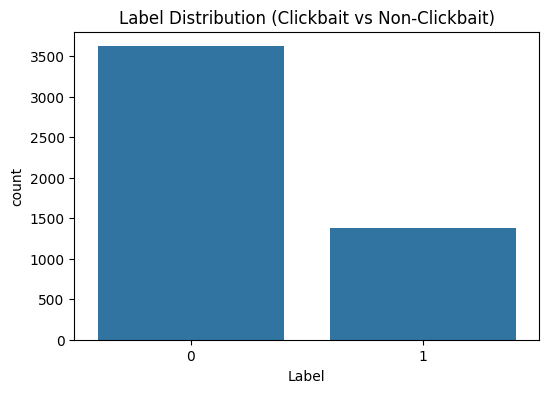

In [ ]:
# =========================
# 3. CREATE HELPER FEATURES
# =========================

# title length (word count)
df["title_len"] = df["title"].astype(str).apply(lambda x: len(x.split()))

# =========================
# 4. LABEL DISTRIBUTION
# =========================

plt.figure(figsize=(6,4))
sns.countplot(x="Label", data=df)
plt.title("Label Distribution (Clickbait vs Non-Clickbait)")
plt.show()



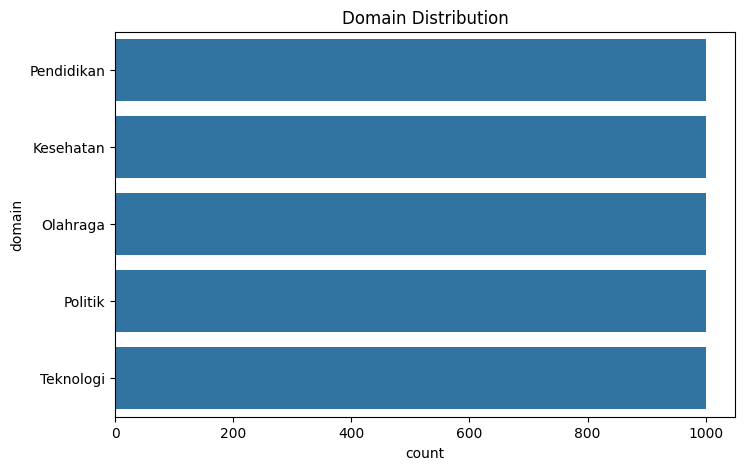

In [ ]:
# =========================
# 5. DOMAIN DISTRIBUTION
# =========================

plt.figure(figsize=(8,5))
sns.countplot(y="domain", data=df, order=df["domain"].value_counts().index)
plt.title("Domain Distribution")
plt.show()

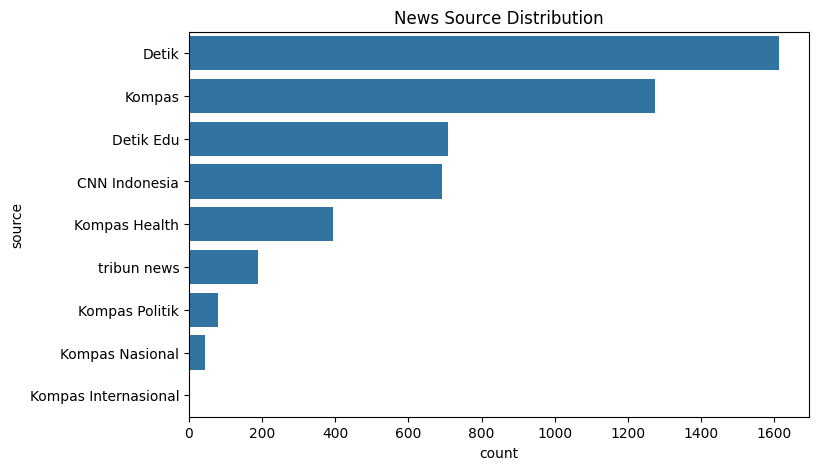

In [ ]:
# =========================
# 6. SOURCE DISTRIBUTION
# =========================

plt.figure(figsize=(8,5))
sns.countplot(y="source", data=df, order=df["source"].value_counts().index)
plt.title("News Source Distribution")
plt.show()

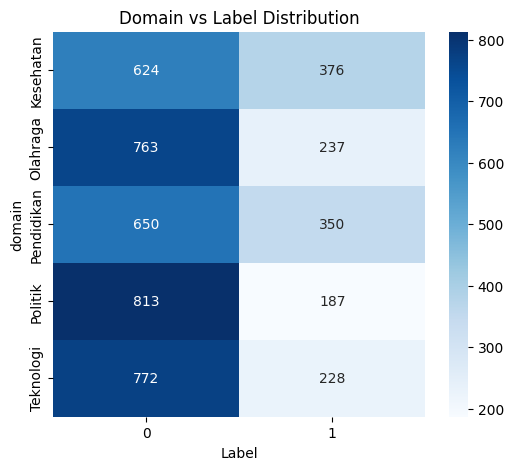

In [ ]:
# =========================
# 7. DOMAIN vs LABEL (HEATMAP)
# =========================

pivot = pd.crosstab(df["domain"], df["Label"])

plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues")
plt.title("Domain vs Label Distribution")
plt.show()

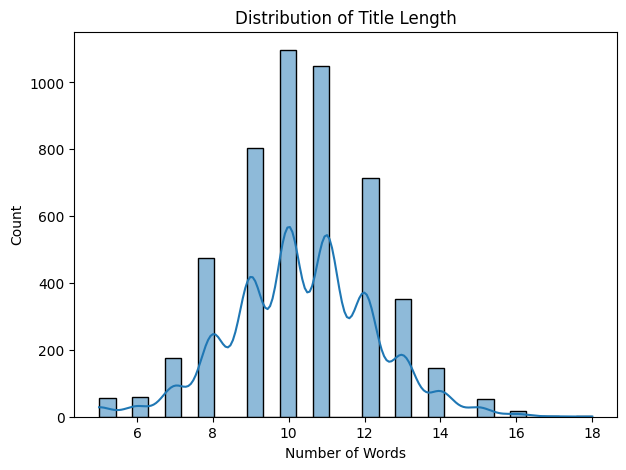

In [ ]:
# =========================
# 8. TITLE LENGTH DISTRIBUTION
# =========================

plt.figure(figsize=(7,5))
sns.histplot(df["title_len"], bins=30, kde=True)
plt.title("Distribution of Title Length")
plt.xlabel("Number of Words")
plt.show()

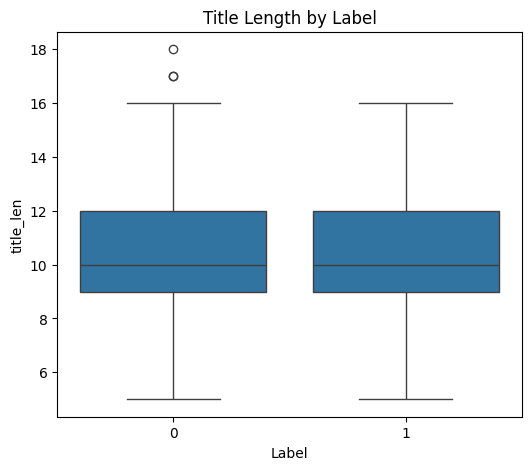

In [ ]:
# =========================
# 9. TITLE LENGTH BY LABEL (BOXPLOT)
# =========================

plt.figure(figsize=(6,5))
sns.boxplot(x="Label", y="title_len", data=df)
plt.title("Title Length by Label")
plt.show()

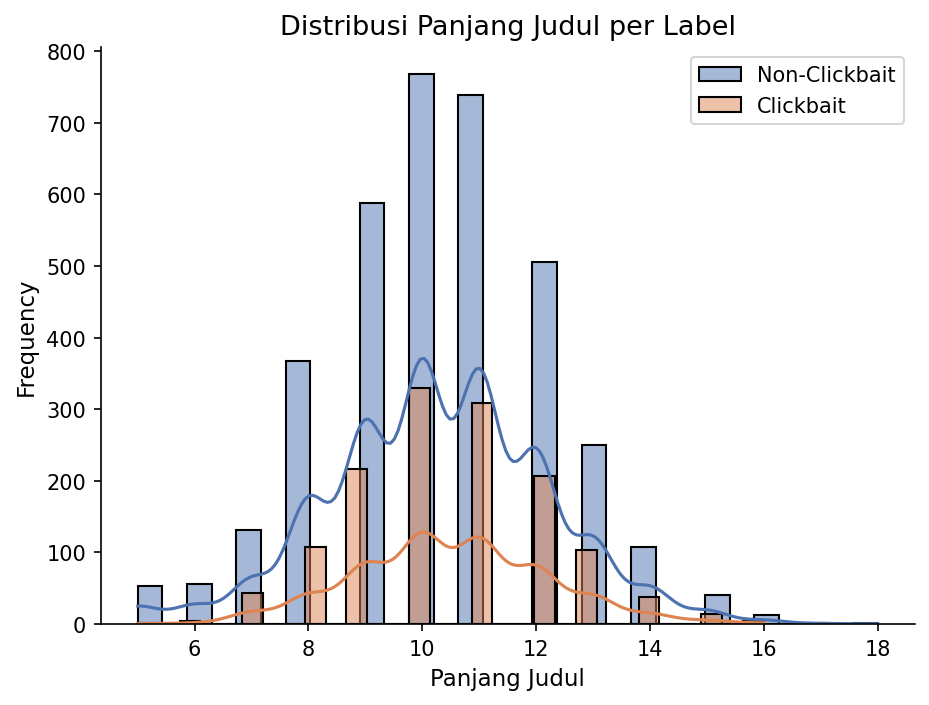

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df["title_len"] = df["title"].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(7,5))

sns.histplot(
    df[df["Label"]==0]["title_len"],
    color="#4C72B0",   # soft blue (Seaborn default palette)
    label="Non-Clickbait",
    kde=True,
    bins=30,
    alpha=0.5
)

sns.histplot(
    df[df["Label"]==1]["title_len"],
    color="#DD8452",   # soft orange (lebih nyaman dari merah)
    label="Clickbait",
    kde=True,
    bins=30,
    alpha=0.5
)

plt.title("Distribusi Panjang Judul per Label")
plt.xlabel("Panjang Judul")
plt.ylabel("Frequency")

plt.legend()
plt.show()

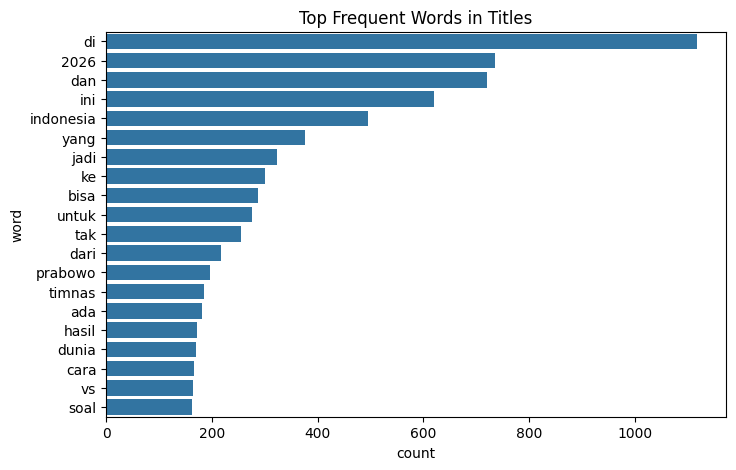

In [ ]:
# =========================
# 10. TOP FREQUENT WORDS (SIMPLE N-GRAM STYLE)
# =========================

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=20)
X = vectorizer.fit_transform(df["title"].astype(str))

word_counts = np.sum(X.toarray(), axis=0)
words = vectorizer.get_feature_names_out()

top_words = pd.DataFrame({"word": words, "count": word_counts})
top_words = top_words.sort_values(by="count", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="count", y="word", data=top_words)
plt.title("Top Frequent Words in Titles")
plt.show()

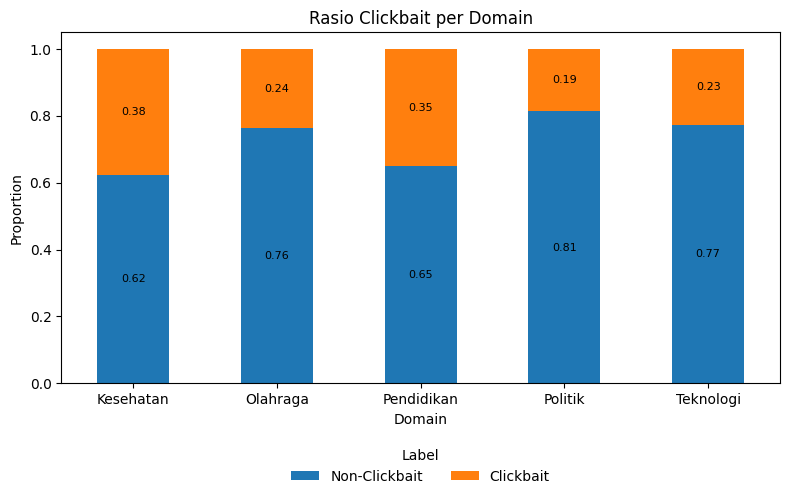

In [ ]:
# =========================
# 11. DOMAIN × LABEL DISTRIBUTION
# =========================

domain_label = pd.crosstab(df["domain"], df["Label"], normalize="index")

ax = domain_label.plot(kind="bar", stacked=True, figsize=(8,5))

plt.title("Rasio Clickbait per Domain")
plt.xlabel("Domain")
plt.ylabel("Proportion")

# add values on each stacked bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="center", fontsize=8)

# spacing so legend does not overlap
plt.subplots_adjust(bottom=0.3)

plt.legend(
    ["Non-Clickbait", "Clickbait"],
    title="Label",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df["Label_num"] = df["Label"]

corr = df[["title_len", "Label_num"]].corr()
print(corr)

           title_len  Label_num
title_len   1.000000   0.052103
Label_num   0.052103   1.000000


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_domain = LabelEncoder()
df["Domain_enc"] = le_domain.fit_transform(df["domain"])

le_source = LabelEncoder()
df["Source_enc"] = le_source.fit_transform(df["source"])

corr = df[["Domain_enc", "Source_enc", "Label"]].corr()
print(corr)

            Domain_enc  Source_enc     Label
Domain_enc    1.000000   -0.143296 -0.109512
Source_enc   -0.143296    1.000000 -0.048914
Label        -0.109512   -0.048914  1.000000


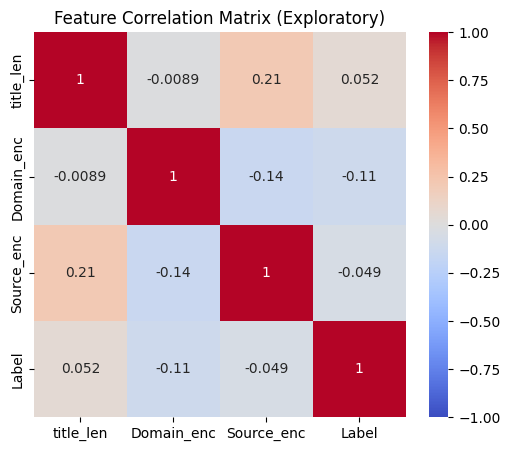

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    df[["title_len", "Domain_enc", "Source_enc", "Label"]].corr(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Feature Correlation Matrix (Exploratory)")
plt.show()

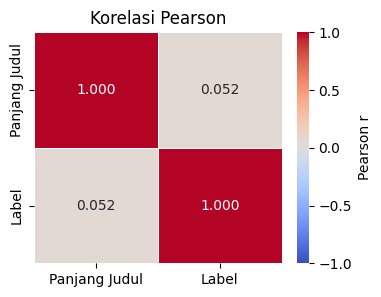

               Panjang Judul     Label
Panjang Judul       1.000000  0.052103
Label               0.052103  1.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pearson_corr = (
    df[["title_len", "Label"]]
    .corr(method="pearson")
    .rename(
        index={"title_len": "Panjang Judul"},
        columns={"title_len": "Panjang Judul"}
    )
)

plt.figure(figsize=(4, 3))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".3f",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "Pearson r", "ticks": [-1, -0.50, 0, 0.50, 1]}
)

plt.title("Korelasi Pearson")
plt.show()

print(pearson_corr)

          domain    source     Label
domain  1.000000  0.694168  0.165135
source  0.694168  1.000000  0.179426
Label   0.165135  0.179426  1.000000


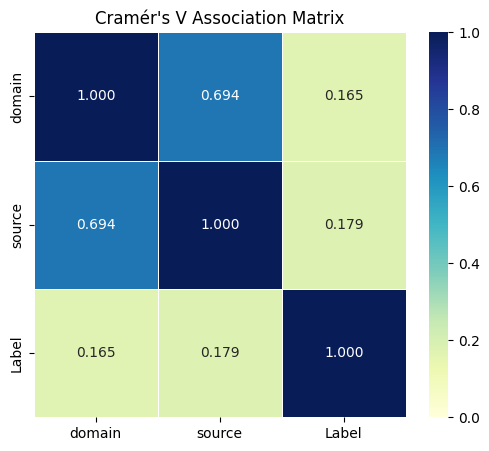

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """
    Calculate Cramér's V for two categorical variables.
    """
    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.values.sum()

    r, k = confusion_matrix.shape

    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

categorical_cols = ["domain", "source", "Label"]

cramers_matrix = pd.DataFrame(
    np.zeros((len(categorical_cols), len(categorical_cols))),
    index=categorical_cols,
    columns=categorical_cols,
)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_matrix.loc[col1, col2] = 1.0
        else:
            cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

print(cramers_matrix)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cramers_matrix,
    annot=True,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    fmt=".3f",
    linewidths=0.7,
    linecolor="white",
)

plt.title("Cramér's V Association Matrix")
plt.show()

In [ ]:
df = df.rename(columns={"Sumber": "source"})
df.head()

,id,source,date,domain,title,Label,url,title_len,Label_num,Domain_enc,Source_enc
0,1,tribun news,26-06-06,Pendidikan,"Pesantren Capai 42 Ribu, Kemenag: Jumlah Santr...",0,https://www.tribunnews.com/nasional/7838729/pe...,12,0,2,8
1,2,tribun news,26-04-06,Pendidikan,Penyanyi Ary Kirana Soroti Pentingnya Pendidik...,0,https://www.tribunnews.com/seleb/7838151/penya...,8,0,2,8
2,3,tribun news,26-05-29,Pendidikan,Kuasa Hukum Sebut Pledoi Nadiem Akan Ungkap Ke...,0,https://www.tribunnews.com/nasional/7835460/ku...,10,0,2,8
3,4,tribun news,26-05-26,Pendidikan,"Universitas Prasetiya Mulya Perkenalkan ""Prasm...",0,https://www.tribunnews.com/parapuan/7834529/un...,10,0,2,8
4,5,tribun news,26-05-26,Pendidikan,Merdeka Copper Gold Genjot Pendidikan dan Pela...,0,https://www.tribunnews.com/bisnis/7834329/merd...,11,0,2,8


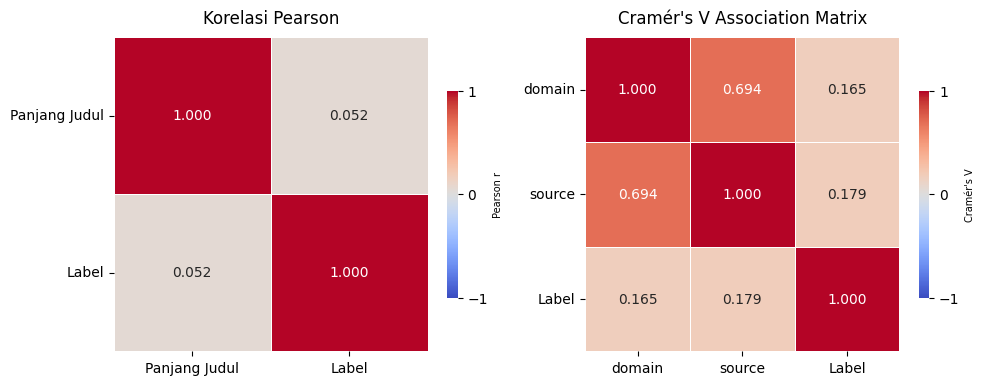

               Panjang Judul     Label
Panjang Judul       1.000000  0.052103
Label               0.052103  1.000000
          domain    source     Label
domain  1.000000  0.694168  0.165135
source  0.694168  1.000000  0.179426
Label   0.165135  0.179426  1.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.values.sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

# --- Pearson ---
pearson_corr = (
    df[["title_len", "Label"]]
    .corr(method="pearson")
    .rename(index={"title_len": "Panjang Judul"}, columns={"title_len": "Panjang Judul"})
)

# --- Cramér's V ---
categorical_cols = ["domain", "source", "Label"]
cramers_matrix = pd.DataFrame(
    np.zeros((len(categorical_cols), len(categorical_cols))),
    index=categorical_cols,
    columns=categorical_cols,
)
for col1 in categorical_cols:
    for col2 in categorical_cols:
        cramers_matrix.loc[col1, col2] = 1.0 if col1 == col2 else cramers_v(df[col1], df[col2])

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

hm_kwargs = dict(
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 10, "weight": "normal"},
    square=True,
)

sns.heatmap(
    pearson_corr,
    ax=axes[0],
    cbar_kws={"shrink": 0.6, "label": "Pearson r", "ticks": [-1, 0, 1]},
    **hm_kwargs,
)

sns.heatmap(
    cramers_matrix,
    ax=axes[1],
    cbar_kws={"shrink": 0.6, "label": "Cramér's V", "ticks": [-1, 0, 1]},
    **hm_kwargs,
)

for ax, title in zip(axes, ["Korelasi Pearson", "Cramér's V Association Matrix"]):
    ax.set_title(title, fontsize=12, pad=10)
    ax.tick_params(axis="x", rotation=0, labelsize=10)
    ax.tick_params(axis="y", rotation=0,  labelsize=10)
    ax.collections[0].colorbar.ax.tick_params(labelsize=10)
    ax.collections[0].colorbar.ax.yaxis.label.set_size(7)

plt.tight_layout()
plt.show()

print(pearson_corr)
print(cramers_matrix)

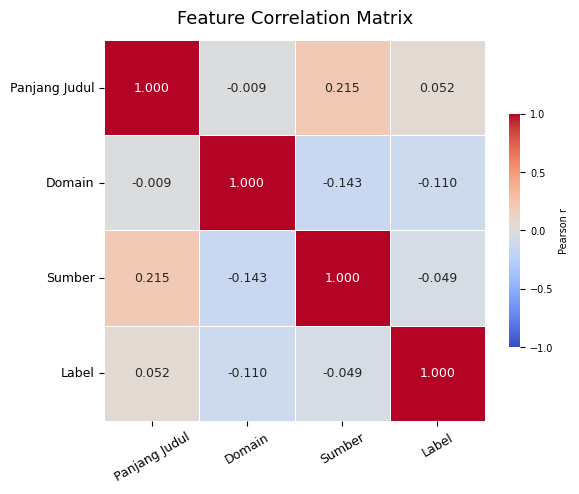

In [ ]:
cols = ["title_len", "Domain_enc", "Source_enc", "Label"]

rename_map = {
    "title_len":  "Panjang Judul",
    "Domain_enc": "Domain",
    "Source_enc": "Sumber",
    "Label":      "Label",
}

corr_matrix = df[cols].rename(columns=rename_map).corr()

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 9, "weight": "normal"},
    cbar_kws={"shrink": 0.6, "label": "Pearson r", "ticks": [-1, -0.50, 0, 0.50, 1]},
    ax=ax,
)

ax.collections[0].colorbar.ax.tick_params(labelsize=7)
ax.collections[0].colorbar.ax.yaxis.label.set_size(7)

ax.set_title("Feature Correlation Matrix", fontsize=13, pad=12)
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()
plt.show()

---

In [ ]:
"""
EDA - Analisis Data Eksploratif
Thesis: Robustness IndoBERT pada Domain Shift dan Perturbasi Linguistik
Studi Kasus: Deteksi Clickbait Berita Bahasa Indonesia

Kolom: id, source, date, Domain, title, Label, url
Label: 0 = non-clickbait, 1 = clickbait
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
import os
import re

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# KONFIGURASI
# ─────────────────────────────────────────────
DATA_PATH = "annotation_3_person - All_Data.csv"          # ganti sesuai path file kalian
OUTPUT_DIR = "eda_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DOMAIN_ORDER = ["politik", "teknologi", "pendidikan", "kesehatan", "olahraga"]
LABEL_MAP    = {0: "Non-Clickbait", 1: "Clickbait"}
PALETTE      = {"Non-Clickbait": "#4C72B0", "Clickbait": "#DD8452"}

plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


# ─────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
df["domain"] = df["domain"].str.strip().str.lower()
df["Label"]  = df["Label"].astype(int)
df["label_name"] = df["Label"].map(LABEL_MAP)
df["title_len"]  = df["title"].astype(str).apply(lambda x: len(x.split()))
df["char_len"]   = df["title"].astype(str).apply(len)

print("=" * 55)
print("  RINGKASAN DATASET")
print("=" * 55)
print(f"  Total sampel      : {len(df):,}")
print(f"  Domain            : {sorted(df['domain'].unique())}")
print(f"  Distribusi label  : {df['Label'].value_counts().to_dict()}")
print(f"  Missing values    : {df.isnull().sum().sum()}")
print(f"  Duplikat judul    : {df['title'].duplicated().sum()}")
print("=" * 55)

  RINGKASAN DATASET
  Total sampel      : 5,000
  Domain            : ['kesehatan', 'olahraga', 'pendidikan', 'politik', 'teknologi']
  Distribusi label  : {0: 3622, 1: 1378}
  Missing values    : 0
  Duplikat judul    : 0


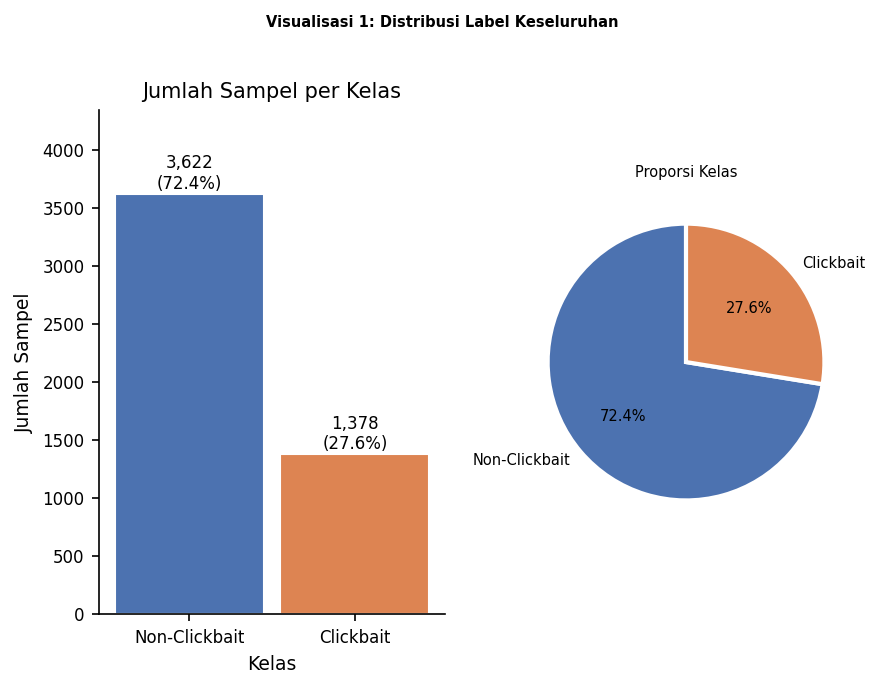


[VIZ 1] Distribusi label keseluruhan tersimpan.


In [ ]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(6, 4.5))
fig.suptitle(
    "Visualisasi 1: Distribusi Label Keseluruhan",
    fontsize=7,
    fontweight="bold",
    y=1.01
)

counts = df["label_name"].value_counts()
colors = [PALETTE[l] for l in counts.index]

# Bar chart
x = np.arange(len(counts))

bars = axes[0].bar(
    x,
    counts.values,
    color=colors,
    edgecolor="white",
    width=0.9
)

for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        f"{val:,}\n({val/len(df)*100:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=8   # 🔥 diubah
    )

axes[0].set_xlabel("Kelas", fontsize=9)
axes[0].set_ylabel("Jumlah Sampel", fontsize=9)
axes[0].set_title("Jumlah Sampel per Kelas", fontsize=10)

axes[0].set_xticks(x)
axes[0].set_xticklabels(counts.index, fontsize=8)
axes[0].tick_params(axis="y", labelsize=8)

axes[0].set_ylim(0, counts.max() * 1.2)

# Pie chart
axes[1].pie(
    counts.values,
    labels=counts.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 7},  # 🔥 semua teks pie
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

axes[1].set_title("Proporsi Kelas", fontsize=7)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/viz1_distribusi_label_keseluruhan.png", bbox_inches="tight")
plt.show()

print("\n[VIZ 1] Distribusi label keseluruhan tersimpan.")

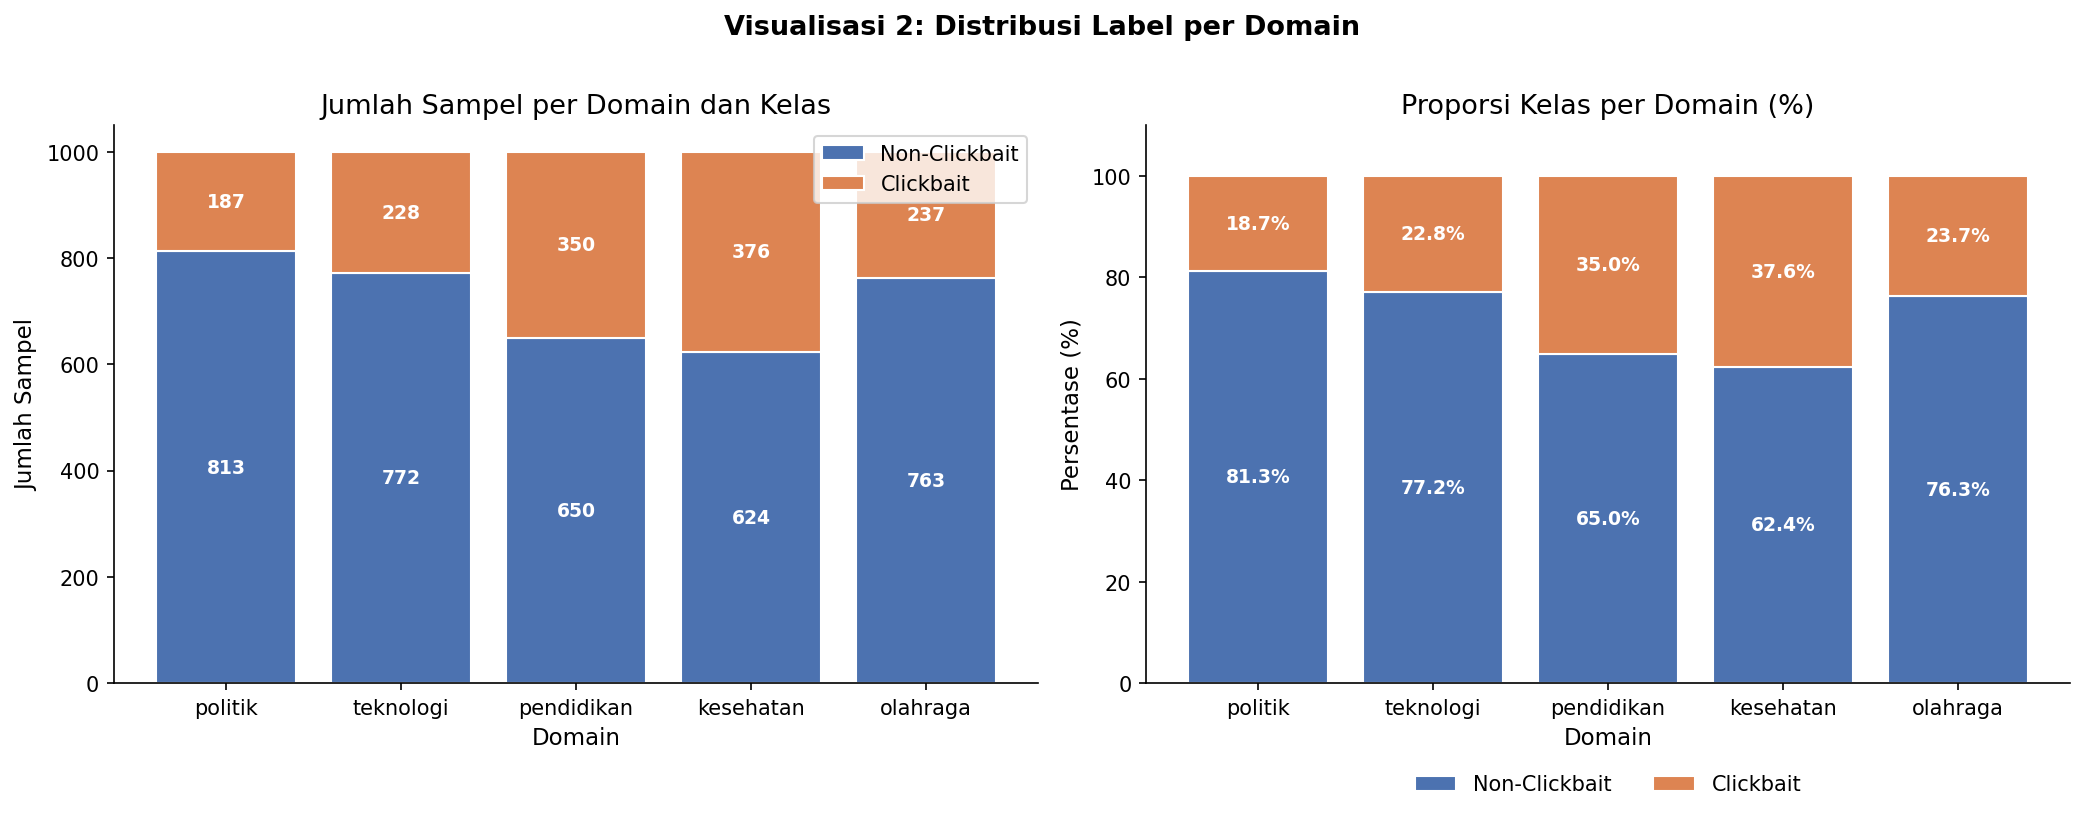

[VIZ 2] Distribusi label per domain tersimpan.

  Imbalance ratio per domain (Non-CB : CB):
    politik     : 813:187  (ratio 4.3:1) ⚠ IMBALANCED
    teknologi   : 772:228  (ratio 3.4:1) ⚠ IMBALANCED
    pendidikan  : 650:350  (ratio 1.9:1)
    kesehatan   : 624:376  (ratio 1.7:1)
    olahraga    : 763:237  (ratio 3.2:1) ⚠ IMBALANCED


In [ ]:
# ═══════════════════════════════════════════════════════════
# VISUALISASI 2 — Distribusi Label per Domain
# ═══════════════════════════════════════════════════════════
domain_label = (df.groupby(["domain", "label_name"])
                  .size()
                  .reset_index(name="count"))
domain_label["pct"] = (domain_label.groupby("domain")["count"]
                                    .transform(lambda x: x / x.sum() * 100))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Visualisasi 2: Distribusi Label per Domain", fontsize=13, fontweight="bold", y=1.01)

# Stacked bar — jumlah absolut
pivot_abs = domain_label.pivot(index="domain", columns="label_name", values="count").fillna(0)
pivot_abs = pivot_abs.reindex(DOMAIN_ORDER)
bottom = np.zeros(len(pivot_abs))
for label, color in PALETTE.items():
    if label in pivot_abs.columns:
        vals = pivot_abs[label].values
        bars = axes[0].bar(pivot_abs.index, vals, bottom=bottom, color=color,
                           label=label, edgecolor="white")
        for bar, val, bot in zip(bars, vals, bottom):
            if val > 20:
                axes[0].text(bar.get_x() + bar.get_width()/2,
                             bot + val/2, f"{int(val)}",
                             ha="center", va="center", fontsize=9, color="white", fontweight="bold")
        bottom += vals
axes[0].set_xlabel("Domain")
axes[0].set_ylabel("Jumlah Sampel")
axes[0].set_title("Jumlah Sampel per Domain dan Kelas")
axes[0].legend()

# Stacked bar — persentase
pivot_pct = domain_label.pivot(index="domain", columns="label_name", values="pct").fillna(0)
pivot_pct = pivot_pct.reindex(DOMAIN_ORDER)
bottom = np.zeros(len(pivot_pct))
for label, color in PALETTE.items():
    if label in pivot_pct.columns:
        vals = pivot_pct[label].values
        bars = axes[1].bar(pivot_pct.index, vals, bottom=bottom, color=color,
                           label=label, edgecolor="white")
        for bar, val, bot in zip(bars, vals, bottom):
            if val > 5:
                axes[1].text(bar.get_x() + bar.get_width()/2,
                             bot + val/2, f"{val:.1f}%",
                             ha="center", va="center", fontsize=9, color="white", fontweight="bold")
        bottom += vals
axes[1].set_xlabel("Domain")
axes[1].set_ylabel("Persentase (%)")
axes[1].set_title("Proporsi Kelas per Domain (%)")
axes[1].set_ylim(0, 110)
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/viz2_distribusi_label_per_domain.png", bbox_inches="tight")
plt.legend(
    ["Non-Clickbait", "Clickbait"],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=2,
    frameon=False
)
plt.show()
print("[VIZ 2] Distribusi label per domain tersimpan.")

# Print imbalance ratio per domain
print("\n  Imbalance ratio per domain (Non-CB : CB):")
for domain in DOMAIN_ORDER:
    sub = df[df["domain"] == domain]["Label"].value_counts()
    n0, n1 = sub.get(0, 0), sub.get(1, 0)
    ratio = n0 / n1 if n1 > 0 else float("inf")
    flag = " ⚠ IMBALANCED" if ratio > 3 else ""
    print(f"    {domain:<12}: {n0}:{n1}  (ratio {ratio:.1f}:1){flag}")

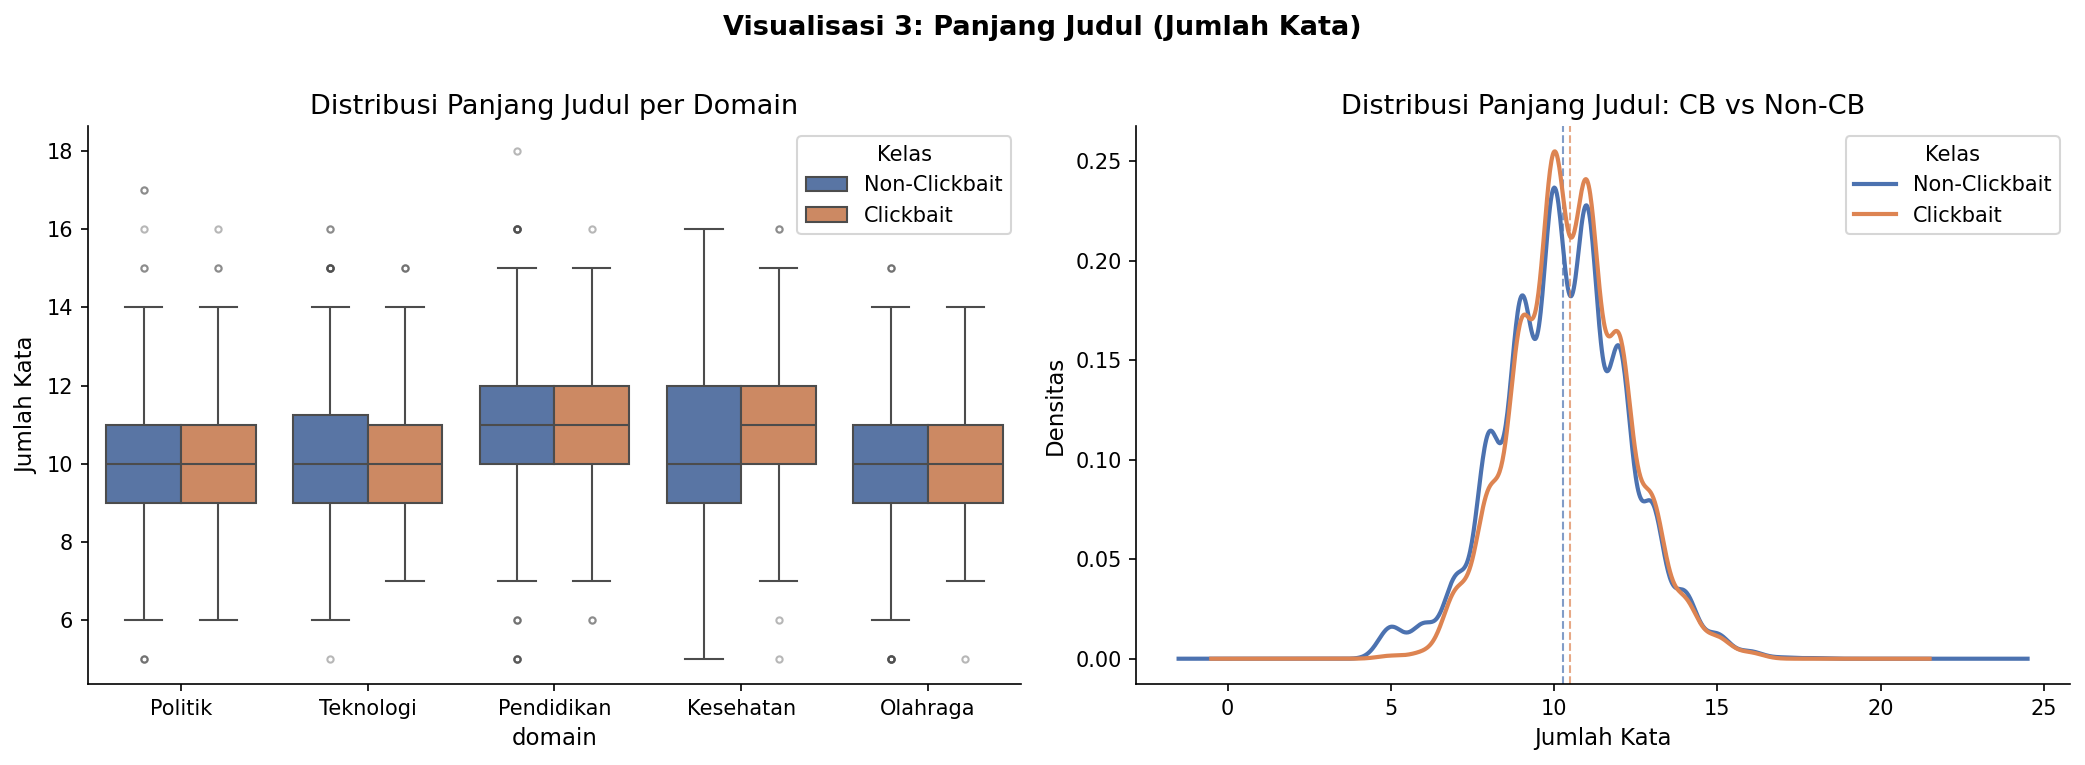

[VIZ 3] Distribusi panjang judul tersimpan.

  Statistik panjang judul (kata):
                count   mean   std  min  25%   50%   75%   max
label_name                                                    
Clickbait      1378.0  10.50  1.70  5.0  9.0  10.0  12.0  16.0
Non-Clickbait  3622.0  10.28  1.93  5.0  9.0  10.0  12.0  18.0


In [ ]:
# ═══════════════════════════════════════════════════════════
# VISUALISASI 3 — Distribusi Panjang Judul per Domain & Label
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Visualisasi 3: Panjang Judul (Jumlah Kata)", fontsize=13, fontweight="bold", y=1.01)

# Boxplot per domain
domain_order_cap = [d.capitalize() for d in DOMAIN_ORDER]
df["Domain_cap"] = df["domain"].str.capitalize()

sns.boxplot(data=df, x="Domain_cap", y="title_len", hue="label_name",
            palette=PALETTE, order=domain_order_cap, ax=axes[0],
            flierprops=dict(marker="o", markersize=3, alpha=0.4))
axes[0].set_xlabel("domain")
axes[0].set_ylabel("Jumlah Kata")
axes[0].set_title("Distribusi Panjang Judul per Domain")
axes[0].legend(title="Kelas")

# KDE per label
for label, color in PALETTE.items():
    subset = df[df["label_name"] == label]["title_len"]
    subset.plot.kde(ax=axes[1], color=color, label=label, linewidth=2)
    axes[1].axvline(subset.mean(), color=color, linestyle="--", linewidth=1, alpha=0.7)
axes[1].set_xlabel("Jumlah Kata")
axes[1].set_ylabel("Densitas")
axes[1].set_title("Distribusi Panjang Judul: CB vs Non-CB")
axes[1].legend(title="Kelas")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/viz3_panjang_judul.png", bbox_inches="tight")
plt.show()
print("[VIZ 3] Distribusi panjang judul tersimpan.")

print("\n  Statistik panjang judul (kata):")
print(df.groupby("label_name")["title_len"].describe().round(2).to_string())

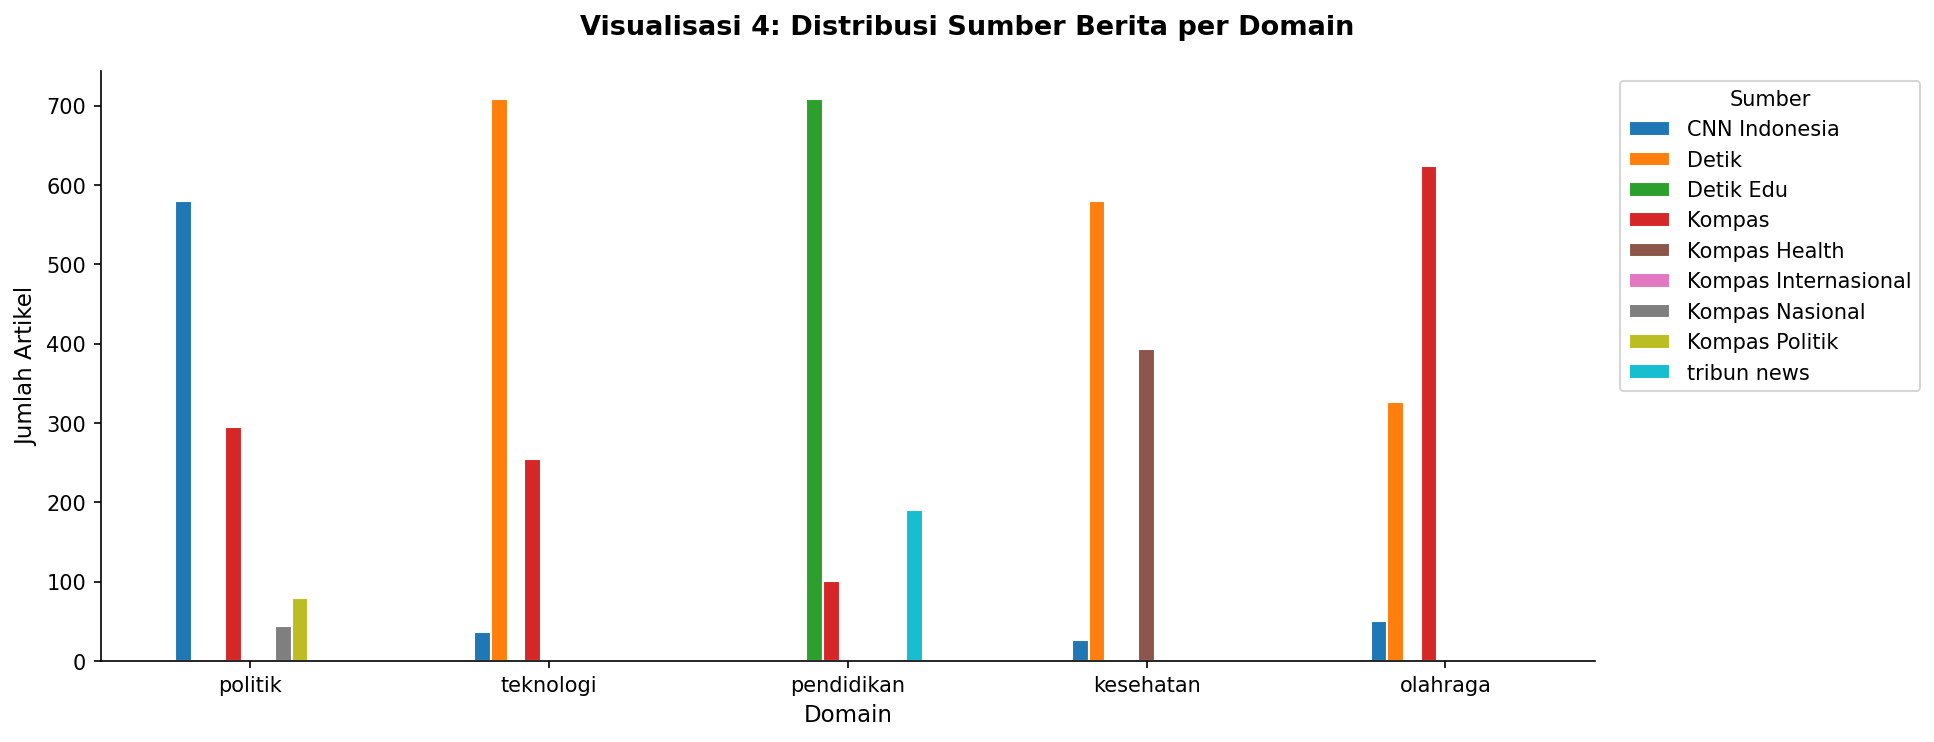

[VIZ 4] Distribusi sumber per domain tersimpan.


In [ ]:
# ═══════════════════════════════════════════════════════════
# VISUALISASI 4 — Distribusi Sumber Berita per Domain
# ═══════════════════════════════════════════════════════════
source_domain = (df.groupby(["domain", "source"])
                   .size()
                   .reset_index(name="count"))

fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle("Visualisasi 4: Distribusi Sumber Berita per Domain",
             fontsize=13, fontweight="bold")

pivot_src = source_domain.pivot(index="domain", columns="source", values="count").fillna(0)
pivot_src = pivot_src.reindex(DOMAIN_ORDER)
pivot_src.plot(kind="bar", ax=ax, edgecolor="white", colormap="tab10")
ax.set_xlabel("Domain")
ax.set_ylabel("Jumlah Artikel")
ax.set_title("")
ax.legend(title="Sumber", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/viz4_sumber_per_domain.png", bbox_inches="tight")
plt.show()
print("[VIZ 4] Distribusi sumber per domain tersimpan.")

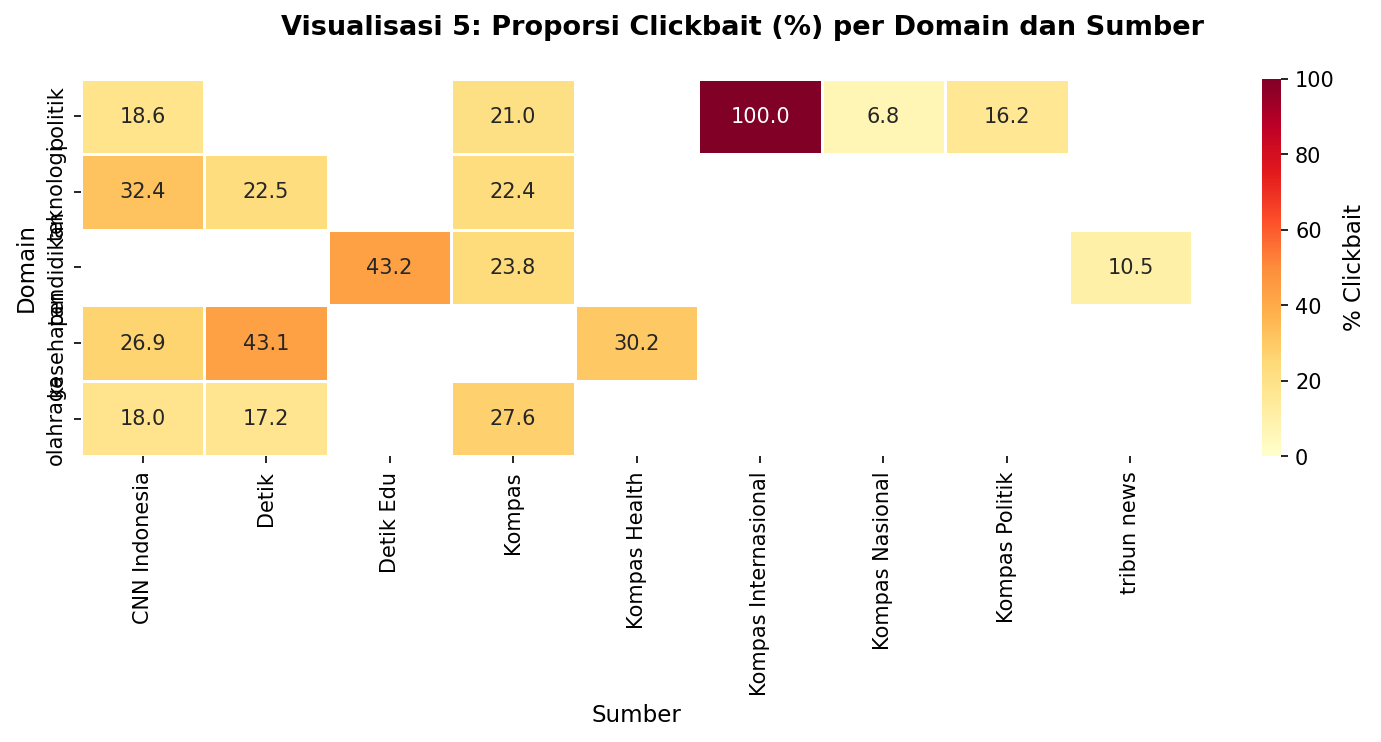

[VIZ 5] Heatmap proporsi clickbait tersimpan.


In [ ]:
# ═══════════════════════════════════════════════════════════
# VISUALISASI 5 — Heatmap Proporsi Clickbait per Domain & Sumber
# ═══════════════════════════════════════════════════════════
pivot_cb = (df[df["Label"] == 1]
              .groupby(["domain", "source"])
              .size()
              .unstack(fill_value=0))
total    = df.groupby(["domain", "source"]).size().unstack(fill_value=0)
pct_cb   = (pivot_cb / total.replace(0, np.nan) * 100).round(1)
pct_cb   = pct_cb.reindex(DOMAIN_ORDER)

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Visualisasi 5: Proporsi Clickbait (%) per Domain dan Sumber",
             fontsize=13, fontweight="bold")

sns.heatmap(pct_cb, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "% Clickbait"},
            vmin=0, vmax=100)
ax.set_xlabel("Sumber")
ax.set_ylabel("Domain")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/viz5_heatmap_cb_domain_sumber.png", bbox_inches="tight")
plt.show()
print("[VIZ 5] Heatmap proporsi clickbait tersimpan.")

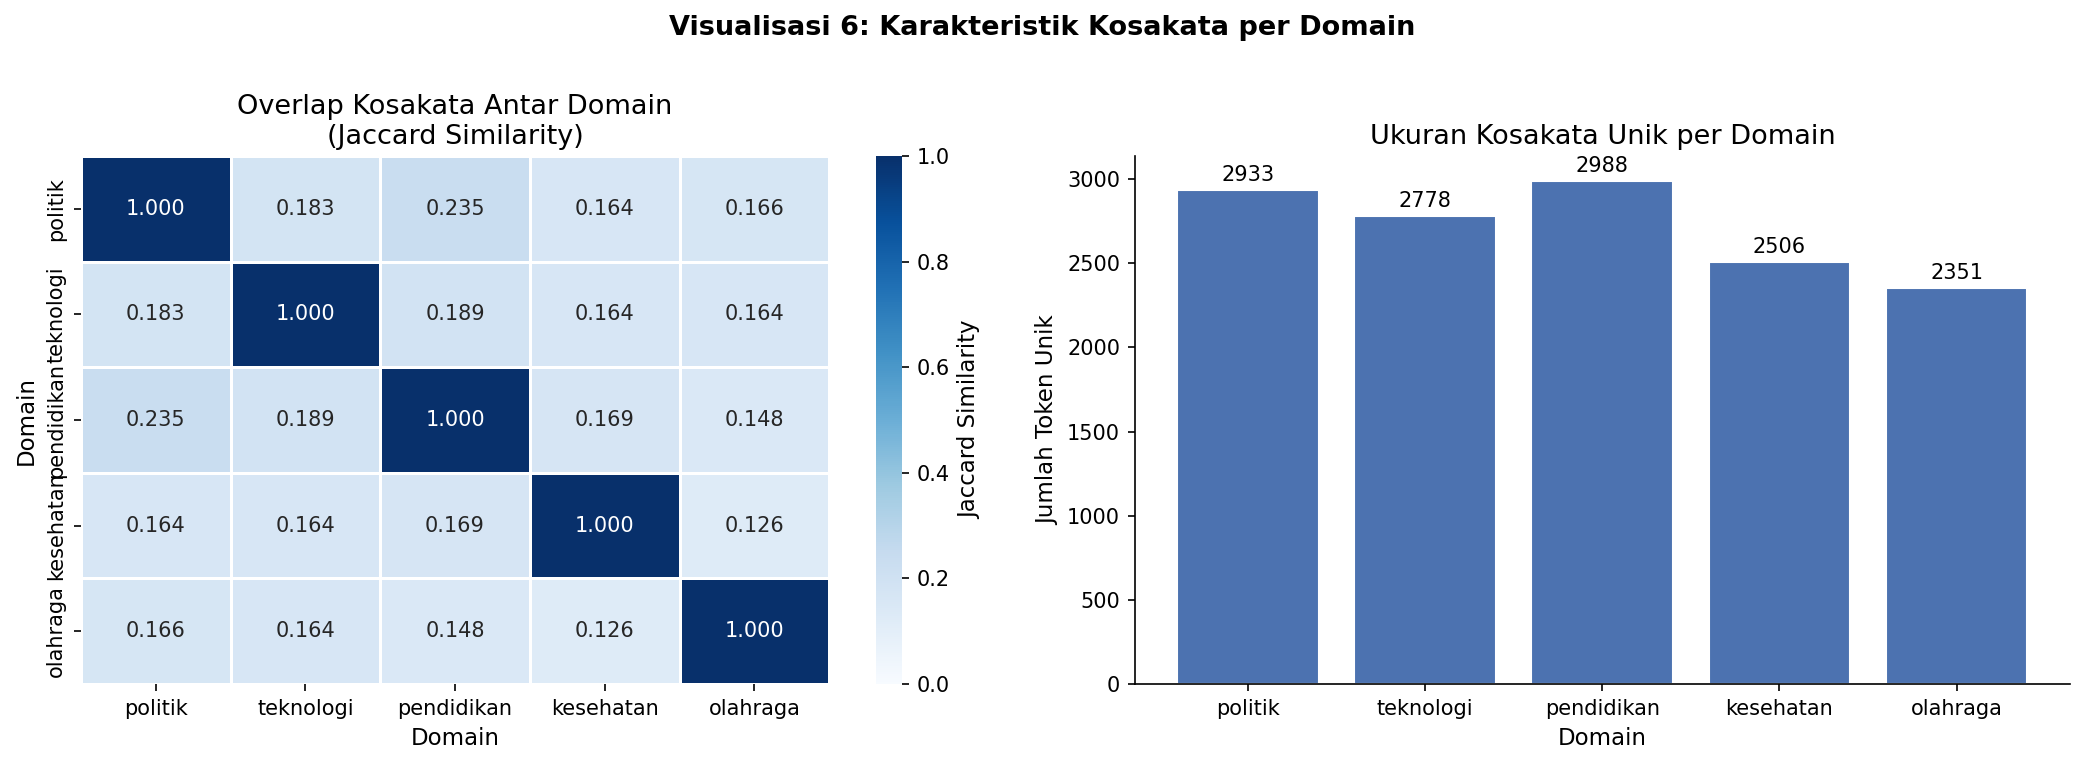

[VIZ 6] Analisis kosakata tersimpan.

  Jaccard Similarity antar domain:
            politik  teknologi  pendidikan  kesehatan  olahraga
politik       1.000      0.183       0.235      0.164     0.166
teknologi     0.183      1.000       0.189      0.164     0.164
pendidikan    0.235      0.189       1.000      0.169     0.148
kesehatan     0.164      0.164       0.169      1.000     0.126
olahraga      0.166      0.164       0.148      0.126     1.000


In [ ]:
# ═══════════════════════════════════════════════════════════
# VISUALISASI 6 — Token Unik dan Overlap Kosakata Antar Domain
# ═══════════════════════════════════════════════════════════
def tokenize(text):
    return set(re.sub(r"[^a-zA-Z\s]", "", str(text).lower()).split())

domain_vocab = {}
for domain in DOMAIN_ORDER:
    titles = df[df["domain"] == domain]["title"]
    vocab  = set()
    for t in titles:
        vocab.update(tokenize(t))
    domain_vocab[domain] = vocab

# Jaccard similarity matrix
jaccard_matrix = pd.DataFrame(index=DOMAIN_ORDER, columns=DOMAIN_ORDER, dtype=float)
for d1 in DOMAIN_ORDER:
    for d2 in DOMAIN_ORDER:
        v1, v2 = domain_vocab[d1], domain_vocab[d2]
        inter  = len(v1 & v2)
        union  = len(v1 | v2)
        jaccard_matrix.loc[d1, d2] = round(inter / union, 3) if union > 0 else 0.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Visualisasi 6: Karakteristik Kosakata per Domain",
             fontsize=13, fontweight="bold", y=1.01)

# Heatmap Jaccard
sns.heatmap(jaccard_matrix.astype(float), annot=True, fmt=".3f",
            cmap="Blues", ax=axes[0], linewidths=0.5,
            cbar_kws={"label": "Jaccard Similarity"}, vmin=0, vmax=1)
axes[0].set_title("Overlap Kosakata Antar Domain\n(Jaccard Similarity)")
axes[0].set_xlabel("Domain")
axes[0].set_ylabel("Domain")

# Jumlah vocab unik per domain
vocab_sizes = {d: len(v) for d, v in domain_vocab.items()}
axes[1].bar(vocab_sizes.keys(), vocab_sizes.values(),
            color="#4C72B0", edgecolor="white")
for i, (k, v) in enumerate(vocab_sizes.items()):
    axes[1].text(i, v + 30, str(v), ha="center", va="bottom", fontsize=10)
axes[1].set_xlabel("Domain")
axes[1].set_ylabel("Jumlah Token Unik")
axes[1].set_title("Ukuran Kosakata Unik per Domain")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/viz6_kosakata_domain.png", bbox_inches="tight")
plt.show()
print("[VIZ 6] Analisis kosakata tersimpan.")

print("\n  Jaccard Similarity antar domain:")
print(jaccard_matrix.to_string())

In [ ]:
# ═══════════════════════════════════════════════════════════
# RINGKASAN INSIGHT → KEPUTUSAN DESAIN
# ═══════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  RINGKASAN INSIGHT EDA → KEPUTUSAN DESAIN")
print("=" * 55)

total_0 = (df["Label"] == 0).sum()
total_1 = (df["Label"] == 1).sum()
ratio_global = total_0 / total_1

print(f"\n  [1] CLASS IMBALANCE GLOBAL")
print(f"      Non-clickbait: {total_0} | Clickbait: {total_1}")
print(f"      Ratio: {ratio_global:.1f}:1")
print(f"      → Keputusan: gunakan stratified split + F1 sebagai metrik utama")

print(f"\n  [2] CLASS IMBALANCE PER DOMAIN")
for domain in DOMAIN_ORDER:
    sub = df[df["domain"] == domain]["Label"].value_counts()
    n0, n1 = sub.get(0, 0), sub.get(1, 0)
    ratio = n0 / n1 if n1 > 0 else float("inf")
    if ratio > 3:
        print(f"      ⚠ {domain}: {n0}:{n1} (ratio {ratio:.1f}:1)")
        print(f"        → Keputusan: class weight adjustment saat fine-tuning di domain ini")

print(f"\n  [3] KOSAKATA DOMAIN")
jac_vals = []
for d1 in DOMAIN_ORDER:
    for d2 in DOMAIN_ORDER:
        if d1 != d2:
            jac_vals.append(float(jaccard_matrix.loc[d1, d2]))
print(f"      Rerata Jaccard antar domain: {np.mean(jac_vals):.3f}")
print(f"      → Nilai Jaccard rendah mengkonfirmasi domain shift yang terukur antar topik")

print(f"\n  [4] PANJANG JUDUL")
cb_mean  = df[df["Label"] == 1]["title_len"].mean()
ncb_mean = df[df["Label"] == 0]["title_len"].mean()
print(f"      Rerata kata — Clickbait: {cb_mean:.1f} | Non-clickbait: {ncb_mean:.1f}")
if abs(cb_mean - ncb_mean) > 1:
    print(f"      → Perbedaan panjang judul antar kelas perlu diperhatikan saat perturbasi")
    print(f"        (judul lebih pendek lebih sensitif terhadap perubahan per token)")

print("\n" + "=" * 55)
print("  Semua visualisasi tersimpan di folder:", OUTPUT_DIR)
print("=" * 55)


  RINGKASAN INSIGHT EDA → KEPUTUSAN DESAIN

  [1] CLASS IMBALANCE GLOBAL
      Non-clickbait: 3622 | Clickbait: 1378
      Ratio: 2.6:1
      → Keputusan: gunakan stratified split + F1 sebagai metrik utama

  [2] CLASS IMBALANCE PER DOMAIN
      ⚠ politik: 813:187 (ratio 4.3:1)
        → Keputusan: class weight adjustment saat fine-tuning di domain ini
      ⚠ teknologi: 772:228 (ratio 3.4:1)
        → Keputusan: class weight adjustment saat fine-tuning di domain ini
      ⚠ olahraga: 763:237 (ratio 3.2:1)
        → Keputusan: class weight adjustment saat fine-tuning di domain ini

  [3] KOSAKATA DOMAIN
      Rerata Jaccard antar domain: 0.171
      → Nilai Jaccard rendah mengkonfirmasi domain shift yang terukur antar topik

  [4] PANJANG JUDUL
      Rerata kata — Clickbait: 10.5 | Non-clickbait: 10.3

  Semua visualisasi tersimpan di folder: eda_output
